# Solana Anomaly Detection — Training Notebook

Loads the three monthly parquet files, builds the transaction-level feature matrix,
trains Isolation Forest + Feature-Attention Transformer AE, applies conformal prediction,
and classifies each flagged wallet into an anomaly archetype.

**No BigQuery queries.** All input is read from `/home/ubuntu/data/chunks/`.

## Experiment Suite

| # | Section | Goal |
|---|---------|------|
| 2 | Ablation | Measures each component's contribution vs baseline |
| 3 | Sensitivity | Measures stability of baseline across hyperparameter ranges |
| 4 | Contamination | Measures baseline detection rate on synthetic anomalies |
| 5 | Interpretability | Explains what the baseline flagged and why |

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import db_dtypes                          # registers dbdate parquet extension type
from pandas.api.types import is_datetime64_any_dtype

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler, QuantileTransformer
from scipy.stats import spearmanr

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots render inline in notebook environments (e.g., Kaggle).
try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic('matplotlib', 'inline')
except Exception:
    pass

sns.set_theme(style='whitegrid', context='notebook', palette='deep')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')
print(f'PyTorch: {torch.__version__}')

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

Device : cuda
PyTorch: 2.9.0+cu126


In [2]:
# ── Load parquets ─────────────────────────────────────────────────────────────
CHUNK_DIR = '/kaggle/input/datasets/nschmidtmartinez/anomaly-detect'
names     = ['sep', 'oct', 'nov']

df_flat = pd.concat([
    pd.read_parquet(os.path.join(CHUNK_DIR, f'{m}.parquet'))
    for m in names
], ignore_index=True)

print(f'Loaded : {len(df_flat):,} rows, {df_flat["wallet"].nunique():,} wallets')
print(f'Columns: {list(df_flat.columns)}')

Loaded : 910,000 rows, 70,109 wallets
Columns: ['signature', 'block_timestamp', 'tx_date', 'wallet', 'fee_sol', 'compute_units_consumed', 'success_flag', 'num_accounts', 'num_signers', 'num_writable', 'log_count', 'num_balance_changes', 'net_sol_flow', 'wallet_sol_delta', 'max_balance_change', 'num_pre_token_balances', 'num_post_token_balances', 'token_accounts_closed', 'hour_of_day', 'day_of_week', 'num_token_transfers', 'unique_mints', 'unique_destinations', 'unique_sources', 'self_transfers', 'total_token_value', 'max_token_value', 'num_instructions', 'unique_programs', 'unique_instruction_types', 'inner_instructions', 'token_program_calls', 'has_compute_budget', 'program_list', 'wallet_tx_count', 'active_days', 'wallet_age_minutes', 'wallet_out_degree', 'wallet_transfer_count', 'fanout_ratio', 'cpi_ratio', 'wallet_activity_rate', 'avg_token_transfer', 'drain_sol_ratio']


In [3]:
# ── Timestamp + sort ──────────────────────────────────────────────────────────
if not is_datetime64_any_dtype(df_flat['block_timestamp']):
    df_flat['block_timestamp'] = pd.to_datetime(
        df_flat['block_timestamp'], utc=True, errors='coerce')
elif getattr(df_flat['block_timestamp'].dt, 'tz', None) is None:
    df_flat['block_timestamp'] = df_flat['block_timestamp'].dt.tz_localize('UTC')

df_flat = df_flat.sort_values(['wallet', 'block_timestamp']).reset_index(drop=True)

# Per-tx time since wallet's previous transaction (0 for first tx)
df_flat['delta_time'] = (
    df_flat.groupby('wallet')['block_timestamp']
    .diff().dt.total_seconds().fillna(0.0)
)
print('Timestamps OK. delta_time computed.')

Timestamps OK. delta_time computed.


=== Dataset Overview ===
Date range : 2024-09-01 00:00:16+00:00 -> 2024-11-30 23:59:51+00:00
Rows       : 910,000
Wallets    : 70,109

Transactions per wallet:
count    70109.0
mean        13.0
std         83.2
min          1.0
25%          1.0
50%          1.0
75%          1.0
90%          2.0
99%        495.9
max       6387.0
dtype: float64

Monthly breakdown (expanded):
 _month   n_tx  n_wallets  n_new_wallets  tx_per_wallet  pct_new_wallets
2024-09 300000      21189          21189      14.158290       100.000000
2024-10 310000      28486          24958      10.882539        87.614969
2024-11 300000      27802          23962      10.790591        86.188044

Single-tx wallets: 60,768  (86.7%)
Multi-tx wallets : 9,341


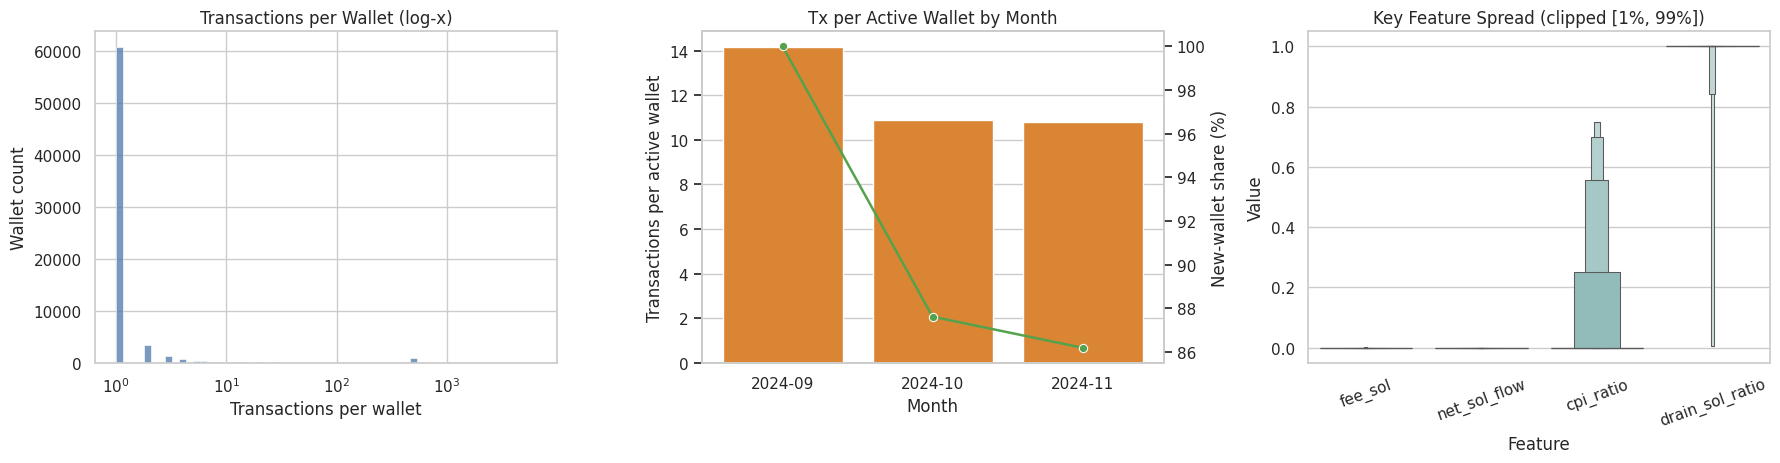

Saved: eda_overview.png


In [4]:
# ── EDA: Dataset characterisation ────────────────────────────────────────────
print('=== Dataset Overview ===')
print(f'Date range : {df_flat["block_timestamp"].min()} -> {df_flat["block_timestamp"].max()}')
print(f'Rows       : {len(df_flat):,}')
print(f'Wallets    : {df_flat["wallet"].nunique():,}')

# Transactions per wallet
tx_per_wallet = df_flat.groupby('wallet').size()
print('\nTransactions per wallet:')
print(tx_per_wallet.describe(percentiles=[.25, .5, .75, .90, .99]).round(1))

# Monthly breakdown with wallet turnover metrics
df_flat['_month'] = df_flat['block_timestamp'].dt.to_period('M')
monthly_vol = (
    df_flat.groupby('_month')
    .agg(n_tx=('wallet', 'count'), n_wallets=('wallet', 'nunique'))
    .reset_index()
)

first_seen_month = (
    df_flat.groupby('wallet')['block_timestamp']
    .min()
    .dt.to_period('M')
    .value_counts()
    .sort_index()
    .rename_axis('_month')
    .reset_index(name='n_new_wallets')
)

monthly_vol = monthly_vol.merge(first_seen_month, on='_month', how='left').fillna({'n_new_wallets': 0})
monthly_vol['tx_per_wallet'] = monthly_vol['n_tx'] / monthly_vol['n_wallets'].clip(lower=1)
monthly_vol['pct_new_wallets'] = 100.0 * monthly_vol['n_new_wallets'] / monthly_vol['n_wallets'].clip(lower=1)

print('\nMonthly breakdown (expanded):')
print(monthly_vol.to_string(index=False))

# Single-tx vs multi-tx wallets
single_tx = (tx_per_wallet == 1).sum()
print(f'\nSingle-tx wallets: {single_tx:,}  ({single_tx / len(tx_per_wallet) * 100:.1f}%)')
print(f'Multi-tx wallets : {(tx_per_wallet > 1).sum():,}')

# Seaborn plots (compact EDA panel; skips daily volume because it is fixed)
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# A) Wallet activity concentration
sns.histplot(tx_per_wallet, bins=60, log_scale=(True, False), color='#4C78A8', ax=axes[0])
axes[0].set_title('Transactions per Wallet (log-x)')
axes[0].set_xlabel('Transactions per wallet')
axes[0].set_ylabel('Wallet count')

# B) Monthly turnover and wallet freshness
_month_plot = monthly_vol.copy()
_month_plot['_month'] = _month_plot['_month'].astype(str)
sns.barplot(data=_month_plot, x='_month', y='tx_per_wallet', color='#F58518', ax=axes[1])
axes[1].set_title('Tx per Active Wallet by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Transactions per active wallet')

ax1b = axes[1].twinx()
sns.lineplot(data=_month_plot, x='_month', y='pct_new_wallets', marker='o', color='#54A24B', linewidth=1.8, ax=ax1b)
ax1b.set_ylabel('New-wallet share (%)')
ax1b.grid(False)

# C) Key feature distributions
key_feats = ['fee_sol', 'net_sol_flow', 'cpi_ratio', 'drain_sol_ratio']
_dist_parts = []
for feat in key_feats:
    _s = df_flat[feat].astype(float)
    vals = _s.clip(_s.quantile(0.01), _s.quantile(0.99))
    _dist_parts.append(pd.DataFrame({'feature': feat, 'value': vals.values}))

dist_df = pd.concat(_dist_parts, ignore_index=True)
sns.boxenplot(data=dist_df, x='feature', y='value', ax=axes[2], color='#72B7B2')
axes[2].set_title('Key Feature Spread (clipped [1%, 99%])')
axes[2].set_xlabel('Feature')
axes[2].set_ylabel('Value')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: eda_overview.png')


In [5]:

# ── Feature columns ───────────────────────────────────────────────────────────
# 33 transaction-level features.
# Excluded: wallet_activity_rate (wallet constant), is_defi (hard label,
# already implicit in cpi_ratio / unique_programs / token_program_calls).
tx_feature_cols = [
    'fee_sol', 'compute_units_consumed', 'success_flag',
    'num_accounts', 'num_signers', 'num_writable',
    'num_balance_changes', 'net_sol_flow', 'wallet_sol_delta', 'max_balance_change',
    'token_accounts_closed', 'num_pre_token_balances', 'num_post_token_balances',
    'hour_of_day', 'day_of_week',
    'num_token_transfers', 'unique_mints', 'unique_destinations', 'unique_sources',
    'self_transfers', 'total_token_value', 'max_token_value',
    'num_instructions', 'unique_programs', 'unique_instruction_types',
    'inner_instructions', 'token_program_calls', 'has_compute_budget',
    'fanout_ratio', 'cpi_ratio', 'avg_token_transfer', 'drain_sol_ratio',
    'delta_time',
]

for col in tx_feature_cols:
    df_flat[col] = (pd.to_numeric(df_flat[col], errors='coerce')
                    .replace([np.inf, -np.inf], np.nan)
                    .fillna(0.0))

X_tx = df_flat[tx_feature_cols].to_numpy(dtype=np.float32)  # (N_tx, 33)
n_inf = np.isinf(X_tx).sum()
n_nan = np.isnan(X_tx).sum()
print(f'X_tx shape : {X_tx.shape}  |  inf={n_inf}  nan={n_nan}')
assert n_inf == 0 and n_nan == 0, "Unexpected inf/nan in feature matrix!"


X_tx shape : (910000, 33)  |  inf=0  nan=0


In [6]:
# ── Temporal train / val / test split ────────────────────────────────────────
# Split by calendar month: Sep = train, Oct = val, Nov = test.
# This respects the natural monthly boundary in the 3-month dataset and avoids
# the prior bug where strict first-appearance exclusion left val/test nearly empty.
#
# Transaction masks: purely by block_timestamp month.
# Wallet sets: each wallet is assigned to whichever period holds the majority
# of its transactions, so every wallet appears in exactly one split.
# This gives a large, well-calibrated conformal calibration set (Oct wallets).

df_flat = df_flat.sort_values('block_timestamp').reset_index(drop=True)
X_tx    = df_flat[tx_feature_cols].to_numpy(dtype=np.float32)

_month = df_flat['block_timestamp'].dt.month  # int: 9, 10, 11

train_mask_tx = (_month == 9).values
val_mask_tx   = (_month == 10).values
test_mask_tx  = (_month == 11).values

# Wallet-level split: assign each wallet to its majority-transaction month
_wallet_month_counts = (
    df_flat.groupby(['wallet', _month.rename('month')])
    .size()
    .reset_index(name='n')
)
_wallet_split = (
    _wallet_month_counts
    .sort_values('n', ascending=False)
    .drop_duplicates('wallet')
    .set_index('wallet')['month']
)
train_wallets = set(_wallet_split[_wallet_split == 9].index)
val_wallets   = set(_wallet_split[_wallet_split == 10].index)
test_wallets  = set(_wallet_split[_wallet_split == 11].index)

print(f'Train : {train_mask_tx.sum():,} txs | {len(train_wallets):,} wallets  (Sep)')
print(f'Val   : {val_mask_tx.sum():,} txs | {len(val_wallets):,} wallets  (Oct)')
print(f'Test  : {test_mask_tx.sum():,} txs | {len(test_wallets):,} wallets  (Nov)')
assert len(train_wallets & val_wallets) == 0, "Split overlap!"
assert len(train_wallets & test_wallets) == 0, "Split overlap!"
assert len(val_wallets   & test_wallets) == 0, "Split overlap!" 

Train : 300,000 txs | 19,123 wallets  (Sep)
Val   : 310,000 txs | 25,769 wallets  (Oct)
Test  : 300,000 txs | 25,217 wallets  (Nov)


In [7]:
# ── Normalisation (fit on train only) ─────────────────────────────────────────
# FIX: Replaced RobustScaler+clipping with QuantileTransformer.
# This forces extreme long-tailed economic data and bursty counts into a 
# smooth uniform [0, 1] distribution, completely avoiding gradient explosion 
# while preserving the rank-extremity of outliers without blind clipping.

from sklearn.preprocessing import QuantileTransformer

scaler = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)
scaler.fit(X_tx[train_mask_tx])
X_tx_norm = scaler.transform(X_tx).astype(np.float32)

n_inf = np.isinf(X_tx_norm).sum()
n_nan = np.isnan(X_tx_norm).sum()
print(f'Normalised  |  inf={n_inf}  nan={n_nan}')
assert n_inf == 0 and n_nan == 0, "inf/nan after normalisation — check raw features!"

print('Train median should be ~0.50 (Uniform):')
print(pd.DataFrame(X_tx_norm[train_mask_tx], columns=tx_feature_cols)
      .describe().loc[['mean','50%','std']].round(3))


Normalised  |  inf=0  nan=0
Train median should be ~0:
      fee_sol  compute_units_consumed  success_flag  num_accounts  \
mean      0.0                   3.786        -0.082          2.88   
50%       0.0                   0.000         0.000          0.00   
std       0.0                   8.669         0.275          6.29   

      num_signers  num_writable  num_balance_changes  net_sol_flow  \
mean        0.038         1.696                 2.88          -0.0   
50%         0.000         0.000                 0.00           0.0   
std         0.217         4.212                 6.29           0.0   

      wallet_sol_delta  max_balance_change  ...  unique_programs  \
mean            -0.002               0.036  ...            0.573   
50%              0.000               0.000  ...            0.000   
std              0.284               0.643  ...            1.297   

      unique_instruction_types  inner_instructions  token_program_calls  \
mean                     0.223         

Highly correlated pairs (|r| > 0.80):
                  feat_a                  feat_b  pearson_r
                 fee_sol            net_sol_flow     -1.000
            num_accounts     num_balance_changes      1.000
         max_token_value      avg_token_transfer      1.000
       total_token_value      avg_token_transfer      1.000
       total_token_value         max_token_value      1.000
  num_pre_token_balances num_post_token_balances      0.995
     num_token_transfers     unique_destinations      0.967
            num_accounts            num_writable      0.953
            num_writable     num_balance_changes      0.953
      inner_instructions               cpi_ratio      0.925
            num_writable  num_pre_token_balances      0.923
        num_instructions         unique_programs      0.923
            num_writable num_post_token_balances      0.923
     unique_destinations          unique_sources      0.922
            num_accounts         unique_programs      0.919
  

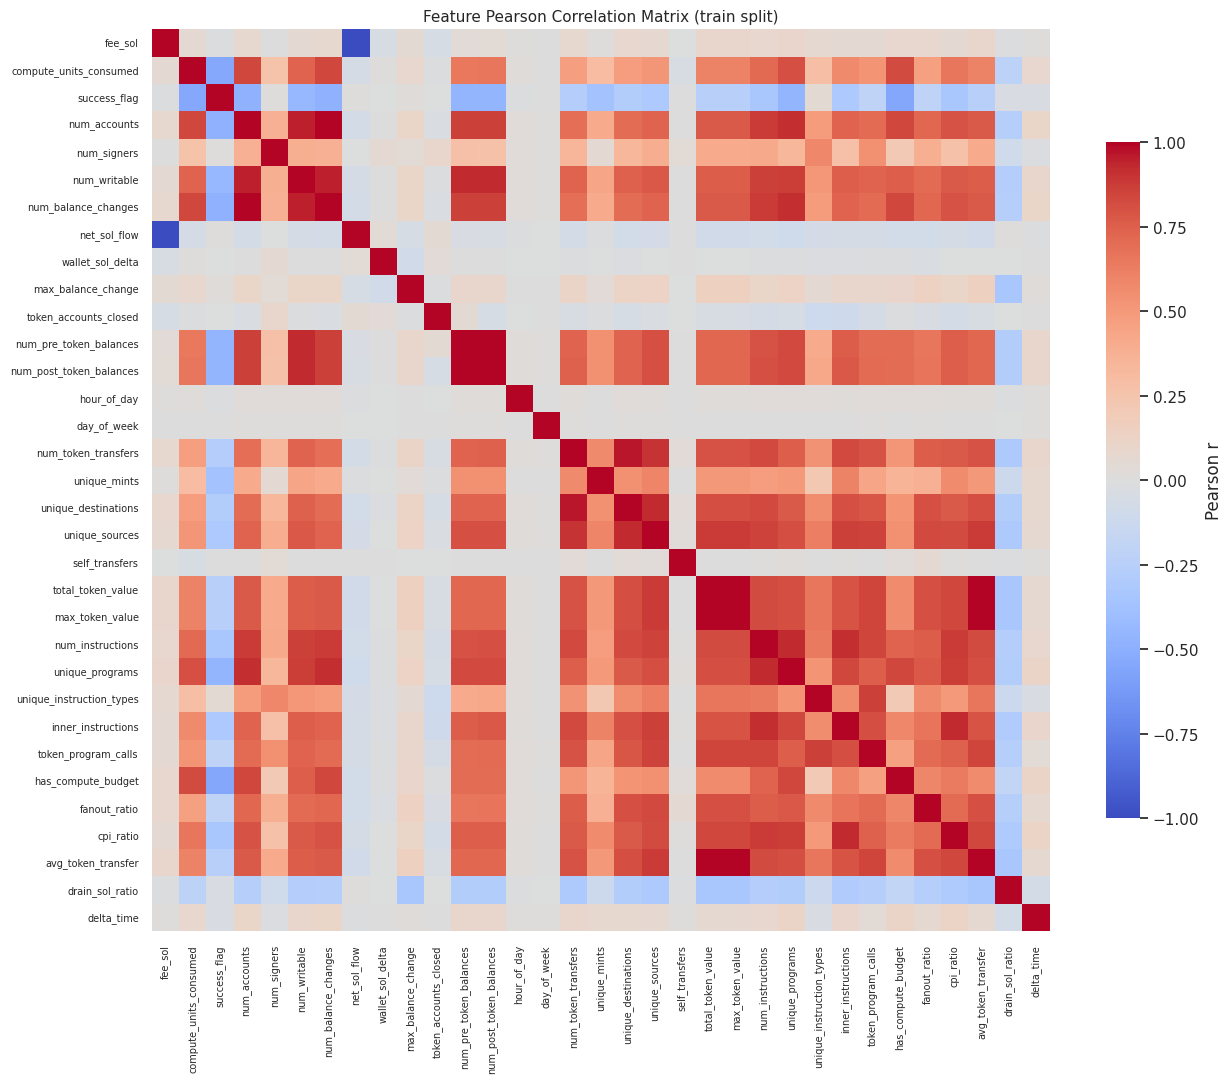

Saved: feature_correlation_heatmap.png


In [8]:
# ── Feature collinearity & VIF analysis ──────────────────────────────────────
import warnings

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    _HAS_SM = True
except ImportError:
    _HAS_SM = False
    print('statsmodels not found — skipping VIF (pip install statsmodels to enable).')

# Pearson correlation on train split (normalised)
_corr = pd.DataFrame(X_tx_norm[train_mask_tx], columns=tx_feature_cols).corr()

# High-correlation pairs (|r| > 0.80)
_hc = []
for _i in range(len(tx_feature_cols)):
    for _j in range(_i + 1, len(tx_feature_cols)):
        _r = _corr.iloc[_i, _j]
        if abs(_r) > 0.80:
            _hc.append({'feat_a': tx_feature_cols[_i],
                        'feat_b': tx_feature_cols[_j],
                        'pearson_r': round(float(_r), 3)})
hc_df = (pd.DataFrame(_hc)
         .sort_values('pearson_r', ascending=False, key=abs)
         .reset_index(drop=True))
print('Highly correlated pairs (|r| > 0.80):')
print(hc_df.to_string(index=False) if len(hc_df) else '  None found.')

# VIF
if _HAS_SM:
    _rng0 = np.random.default_rng(42)
    _n    = train_mask_tx.sum()
    _samp = _rng0.choice(_n, size=min(8000, _n), replace=False)
    _Xv   = X_tx_norm[train_mask_tx][_samp]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        _vif = [variance_inflation_factor(_Xv, _k) for _k in range(_Xv.shape[1])]
    vif_df = (pd.DataFrame({'feature': tx_feature_cols, 'VIF': _vif})
              .sort_values('VIF', ascending=False))
    print('\nVariance Inflation Factors (top 15):')
    print(vif_df.head(15).to_string(index=False))
    print(f'Features with VIF > 10: {vif_df[vif_df.VIF > 10]["feature"].tolist()}')

# Heatmap (Seaborn)
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    _corr,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    xticklabels=tx_feature_cols,
    yticklabels=tx_feature_cols,
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
    ax=ax,
)
ax.set_title('Feature Pearson Correlation Matrix (train split)', fontsize=11)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout()
plt.savefig('feature_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: feature_correlation_heatmap.png')


In [9]:
# ── Isolation Forest ──────────────────────────────────────────────────────────
# Trains on ~546k raw transaction rows.
# max_samples=256 keeps each tree tractable regardless of dataset size.

IF_CFG = dict(n_estimators=300, max_samples=256,
              contamination='auto', random_state=42, n_jobs=-1)

print('Fitting Isolation Forest...')
iforest = IsolationForest(**IF_CFG).fit(X_tx[train_mask_tx])  # FIX: Tree models are scale-invariant; feed raw data

if_raw      = -iforest.decision_function(X_tx)           # (N_tx,) higher = more anomalous

# Training-CDF normalisation (Kriegel et al. 2011 "Interpreting and Unifying
# Outlier Scores"; ECOD, Li et al. 2022):
#   score_i = P(X_train <= raw_i)  ≈ empirical CDF of the training distribution.
# Using training-only CDF avoids data leakage: val/test raw scores do NOT
# influence the normalisation reference.  Mean ≈ 0.50 on training data by
# construction; val/test anomalies push into the upper tail (>0.95).
if_train_raw   = if_raw[train_mask_tx]
_if_train_sort = np.sort(if_train_raw)
# Empirical CDF via searchsorted — O(N log N), equivalent to loop but ~1000x faster.
if_tx_score    = np.searchsorted(_if_train_sort, if_raw, side='right') / len(_if_train_sort)  # (N_tx,) ∈ [0,1]
print(f'IF done. Score range: [{if_tx_score.min():.4f}, {if_tx_score.max():.4f}]')
print(f'IF score mean (expect ≈0.50 with rank norm): {if_tx_score.mean():.4f}')

Fitting Isolation Forest...
IF done. Score range: [0.0000, 1.0000]
IF score mean (expect ≈0.50 with rank norm): 0.5136


In [10]:

# ── Transformer AE ────────────────────────────────────────────────────────────
# Feature-attention: each of the 33 scalar features = one token.
# Encoder learns cross-feature co-occurrence patterns.
# High reconstruction error = feature combination the model rarely saw in training.

class TxTransformerAE(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4,
                 num_layers=2, ff_dim=128, dropout=0.1):
        super().__init__()
        self.feat_proj = nn.Linear(1, d_model)
        self.pos_embed = nn.Embedding(n_features, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, activation='gelu')
        self.encoder  = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.out_proj = nn.Linear(d_model, 1)

    def forward(self, x):                          # x: (B, F)
        B, F = x.shape
        pos  = torch.arange(F, device=x.device)
        tok  = self.feat_proj(x.unsqueeze(-1)) + self.pos_embed(pos).unsqueeze(0)
        z    = self.encoder(tok)
        return self.out_proj(z).squeeze(-1)        # (B, F)


TR_CFG = dict(d_model=64, nhead=4, num_layers=2, ff_dim=128, dropout=0.10,
              lr=1e-3, weight_decay=1e-4, epochs=6, batch_size=256)

def train_tx_ae(X_train, X_val, cfg, device='cpu'):
    """Train Transformer AE and return (model, train_losses, val_losses)."""
    model = TxTransformerAE(
        X_train.shape[1], cfg['d_model'], cfg['nhead'],
        cfg['num_layers'], cfg['ff_dim'], cfg['dropout']).to(device)
    opt = torch.optim.Adam(model.parameters(),
                           lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    dl  = DataLoader(TensorDataset(torch.from_numpy(X_train)),
                     batch_size=cfg['batch_size'], shuffle=True)
    train_losses, val_losses = [], []
    for epoch in range(cfg['epochs']):
        model.train()
        total = 0
        for (xb,) in dl:
            xb   = xb.to(device)
            loss = nn.functional.mse_loss(model(xb), xb)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            if torch.isnan(loss):
                raise RuntimeError(
                    f'NaN loss at epoch {epoch+1} — check input data for inf/nan.')
            total += loss.item()
        train_loss = total / len(dl)
        train_losses.append(train_loss)
        # validation loss (no grad, batched)
        model.eval()
        with torch.no_grad():
            vtot, vn = 0.0, 0
            for i in range(0, len(X_val), cfg['batch_size']):
                xb = torch.from_numpy(X_val[i:i+cfg['batch_size']]).to(device)
                vtot += nn.functional.mse_loss(model(xb), xb).item()
                vn   += 1
            val_loss = vtot / max(vn, 1)
        val_losses.append(val_loss)
        print(f'  Epoch {epoch+1}/{cfg["epochs"]}  train={train_loss:.6f}  val={val_loss:.6f}')
    return model, train_losses, val_losses


def score_tx_ae(model, X_all, device='cpu', batch_size=1024):
    """Returns (N_tx,) scalar MSE and (N_tx, F) per-feature squared error."""
    model.eval()
    mse_list, feat_err_list = [], []
    with torch.no_grad():
        for i in range(0, len(X_all), batch_size):
            xb   = torch.from_numpy(X_all[i:i+batch_size]).to(device)
            pred = model(xb)
            fe   = (pred - xb) ** 2
            mse_list.append(fe.mean(dim=1).cpu().numpy())
            feat_err_list.append(fe.cpu().numpy())
    return np.concatenate(mse_list), np.concatenate(feat_err_list)


print('Training Transformer AE...')
tr_model, ae_train_losses, ae_val_losses = train_tx_ae(X_tx_norm[train_mask_tx], X_tx_norm[val_mask_tx], TR_CFG, device)
tr_raw, per_feat_errors = score_tx_ae(tr_model, X_tx_norm, device)  # (N_tx,), (N_tx, 33)
# Training-CDF normalisation — same approach as IF (Kriegel et al. 2011).
tr_train_raw   = tr_raw[train_mask_tx]
_tr_train_sort = np.sort(tr_train_raw)
tr_tx_score    = np.searchsorted(_tr_train_sort, tr_raw, side='right') / len(_tr_train_sort)  # (N_tx,) ∈ [0,1]
print(f'TR done. Score range: [{tr_tx_score.min():.4f}, {tr_tx_score.max():.4f}]')


Training Transformer AE...
  Epoch 1/6  train=0.441472  val=0.054951
  Epoch 2/6  train=0.008381  val=0.069253
  Epoch 3/6  train=0.004449  val=0.080087
  Epoch 4/6  train=0.003463  val=0.086451
  Epoch 5/6  train=0.003117  val=0.074489
  Epoch 6/6  train=0.002872  val=0.057257
TR done. Score range: [0.0000, 1.0000]


  Fitting AE [small] ...
  Epoch 1/6  train=0.860179  val=0.023268
  Epoch 2/6  train=0.009313  val=0.009238
  Epoch 3/6  train=0.005038  val=0.012835
  Epoch 4/6  train=0.004143  val=0.010310
  Epoch 5/6  train=0.003594  val=0.016228
  Epoch 6/6  train=0.003280  val=0.013499
  Fitting AE [default] ...
  Epoch 1/6  train=0.490671  val=0.039922
  Epoch 2/6  train=0.006703  val=0.036818
  Epoch 3/6  train=0.004196  val=0.037117
  Epoch 4/6  train=0.003189  val=0.030747
  Epoch 5/6  train=0.005459  val=0.065749
  Epoch 6/6  train=0.002317  val=0.055425
  Fitting AE [large] ...
  Epoch 1/6  train=0.233714  val=0.025233
  Epoch 2/6  train=0.010349  val=0.008271
  Epoch 3/6  train=0.006723  val=0.007788
  Epoch 4/6  train=0.004188  val=0.005964
  Epoch 5/6  train=0.003341  val=0.014525
  Epoch 6/6  train=0.007953  val=0.007452

AE configuration comparison:
 config  val_mse  train_mse  d_model  num_layers
  small 0.013499   0.003280       32           1
default 0.055425   0.002317       64   

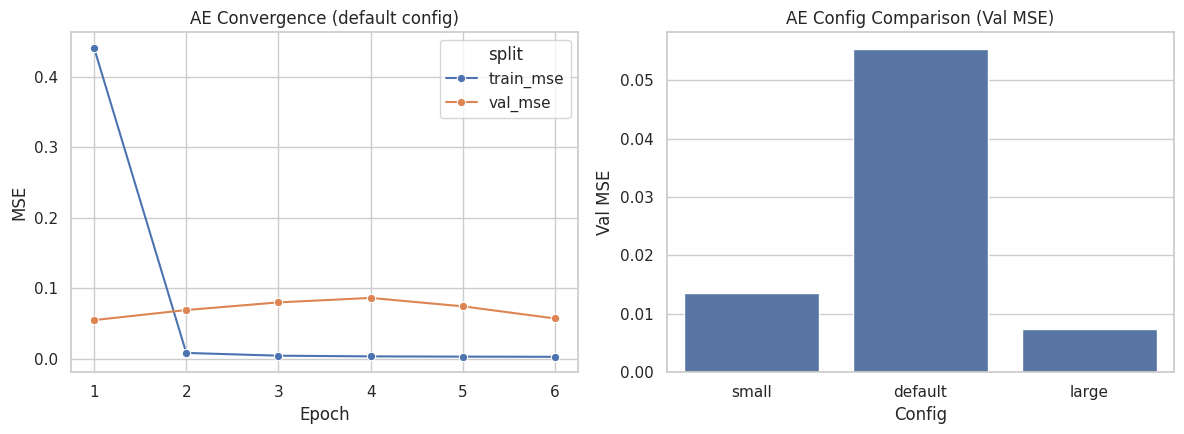

Saved: ae_convergence_and_selection.png


In [11]:
# ── AE convergence curves & hyperparameter selection ─────────────────────────
# Compare three architecture configs on val MSE; confirm "default" is reasonable.

_AE_GRID = [
    dict(label='small',   d_model=32,  nhead=4, num_layers=1, ff_dim=64,  dropout=0.10),
    dict(label='default', d_model=64,  nhead=4, num_layers=2, ff_dim=128, dropout=0.10),
    dict(label='large',   d_model=128, nhead=4, num_layers=3, ff_dim=256, dropout=0.15),
]
_BASE = dict(lr=TR_CFG['lr'], weight_decay=TR_CFG['weight_decay'],
             epochs=TR_CFG['epochs'], batch_size=TR_CFG['batch_size'])

_ae_sel_rows = []
_best_val    = np.inf
_best_label  = 'default'

for _arch in _AE_GRID:
    _lbl = _arch['label']
    _cfg = {k: v for k, v in _arch.items() if k != 'label'}
    _cfg.update(_BASE)
    print(f'  Fitting AE [{_lbl}] ...')
    _m, _tl, _vl = train_tx_ae(X_tx_norm[train_mask_tx],
                                X_tx_norm[val_mask_tx], _cfg, device)
    _ae_sel_rows.append({'config': _lbl,
                         'val_mse': round(float(_vl[-1]), 6),
                         'train_mse': round(float(_tl[-1]), 6),
                         'd_model': _arch['d_model'],
                         'num_layers': _arch['num_layers']})
    if _vl[-1] < _best_val:
        _best_val   = _vl[-1]
        _best_label = _lbl

ae_sel_df = pd.DataFrame(_ae_sel_rows)
print('\nAE configuration comparison:')
print(ae_sel_df.to_string(index=False))
print(f'\nSelected config: "{_best_label}"  (val_mse={_best_val:.6f})')
if _best_label != 'default':
    print(f'  NOTE: re-run cell 8 with d_model/num_layers from "{_best_label}" for best results.')

# Convergence plot for the "default" config (already trained as tr_model)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

_conv_df = pd.DataFrame({
    'epoch': np.arange(1, len(ae_train_losses) + 1),
    'train_mse': ae_train_losses,
    'val_mse': ae_val_losses,
}).melt(id_vars='epoch', var_name='split', value_name='mse')

sns.lineplot(data=_conv_df, x='epoch', y='mse', hue='split', marker='o', ax=axes[0])
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_title('AE Convergence (default config)')

sns.barplot(data=ae_sel_df, x='config', y='val_mse', ax=axes[1])
axes[1].set_xlabel('Config')
axes[1].set_ylabel('Val MSE')
axes[1].set_title('AE Config Comparison (Val MSE)')

plt.tight_layout()
plt.savefig('ae_convergence_and_selection.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: ae_convergence_and_selection.png')


### AE model selection

Per the **universal workflow of ML** (Chollet, *Deep Learning with Python*): after beating a baseline, we should *regularise and tune* by searching hyperparameters rather than comparing only a few hand-picked configs. The section below first runs a compact **capacity + regularised diagnostics** pass (small/medium/large plus regularised variants), then a full **Optuna optimisation** study over AE and IF settings.

In [12]:
# ── Capacity + regularised diagnostics (pre-Optuna) ──────────────────────────
# Chollet-style sanity check: compare model capacity and regularisation before
# full hyperparameter optimisation.

if 'train_tx_ae' not in globals() or 'score_tx_ae' not in globals() or 'TR_CFG' not in globals():
    raise RuntimeError('Run AE setup first (`train_tx_ae`, `score_tx_ae`, `TR_CFG` required).')

if 'X_tx_norm' not in globals() or 'train_mask_tx' not in globals() or 'val_mask_tx' not in globals():
    raise RuntimeError('Missing data splits (`X_tx_norm`, `train_mask_tx`, `val_mask_tx`).')

DIAG_EPOCHS = int(min(TR_CFG.get('epochs', 10), 6))
DIAG_BATCH_SIZE = int(TR_CFG.get('batch_size', 256))
ALPHA_DIAG = float(ALPHA) if 'ALPHA' in globals() else 0.01

_base_lr = float(TR_CFG.get('lr', 1e-3))
_base_wd = float(TR_CFG.get('weight_decay', 1e-5))
_base_dropout = float(TR_CFG.get('dropout', 0.10))

_diag_cfgs = [
    dict(profile='small', d_model=32, nhead=4, num_layers=1, ff_dim=64,
         dropout=0.10, lr=_base_lr, weight_decay=_base_wd),
    dict(profile='medium', d_model=64, nhead=4, num_layers=2, ff_dim=128,
         dropout=max(0.10, _base_dropout), lr=_base_lr, weight_decay=_base_wd),
    dict(profile='large', d_model=128, nhead=8, num_layers=3, ff_dim=256,
         dropout=0.15, lr=_base_lr, weight_decay=_base_wd),
    dict(profile='medium_regularised', d_model=64, nhead=4, num_layers=2, ff_dim=128,
         dropout=max(0.20, _base_dropout), lr=_base_lr, weight_decay=max(_base_wd * 5.0, 1e-4)),
    dict(profile='large_regularised', d_model=128, nhead=8, num_layers=3, ff_dim=256,
         dropout=0.25, lr=_base_lr * 0.7, weight_decay=max(_base_wd * 8.0, 2e-4)),
]

_diag_rows = []
for _cfg_base in _diag_cfgs:
    _cfg = dict(_cfg_base)
    _cfg['epochs'] = DIAG_EPOCHS
    _cfg['batch_size'] = DIAG_BATCH_SIZE

    print(
        f"Diagnostic run [{_cfg['profile']}]: d={_cfg['d_model']} h={_cfg['nhead']} "
        f"L={_cfg['num_layers']} ff={_cfg['ff_dim']} dr={_cfg['dropout']:.2f} "
        f"lr={_cfg['lr']:.2e} wd={_cfg['weight_decay']:.2e}"
    )

    _m, _train_losses, _val_losses = train_tx_ae(
        X_tx_norm[train_mask_tx],
        X_tx_norm[val_mask_tx],
        _cfg,
        device,
    )

    _tr_raw_diag, _ = score_tx_ae(_m, X_tx_norm, device)
    _diag_sort     = np.sort(_tr_raw_diag[train_mask_tx])
    _tr_score_diag = np.searchsorted(_diag_sort, _tr_raw_diag, side='right') / len(_diag_sort)
    _val_sc = _tr_score_diag[val_mask_tx]

    _tail = float(np.quantile(_val_sc, 0.99) - np.quantile(_val_sc, 0.50))
    _thr = float(np.quantile(_val_sc, 1 - ALPHA_DIAG))

    _diag_rows.append({
        'profile': _cfg['profile'],
        'regularised': ('regularised' in _cfg['profile']),
        'train_mse': float(_train_losses[-1]),
        'val_mse': float(_val_losses[-1]),
        'generalisation_gap': float(_val_losses[-1] - _train_losses[-1]),
        'val_tail_contrast': _tail,
        'val_threshold': _thr,
        'd_model': int(_cfg['d_model']),
        'nhead': int(_cfg['nhead']),
        'num_layers': int(_cfg['num_layers']),
        'dropout': float(_cfg['dropout']),
        'lr': float(_cfg['lr']),
        'weight_decay': float(_cfg['weight_decay']),
        'epochs': int(_cfg['epochs']),
        'batch_size': int(_cfg['batch_size']),
    })

chollet_capacity_regularised_df = (
    pd.DataFrame(_diag_rows)
    .sort_values(['val_mse', 'generalisation_gap', 'val_tail_contrast'], ascending=[True, True, False])
    .reset_index(drop=True)
)

print('\nCapacity + regularised diagnostics:')
print(chollet_capacity_regularised_df.to_string(index=False))

_best_profile = chollet_capacity_regularised_df.iloc[0]['profile']
print(f"\nRecommended centre for Optuna optimisation: {_best_profile}")
print('Saved table: `chollet_capacity_regularised_df`.')

Diagnostic run [small]: d=32 h=4 L=1 ff=64 dr=0.10 lr=1.00e-03 wd=1.00e-04
  Epoch 1/6  train=0.975301  val=0.021000
  Epoch 2/6  train=0.010588  val=0.009219
  Epoch 3/6  train=0.005095  val=0.008137
  Epoch 4/6  train=0.004033  val=0.011312
  Epoch 5/6  train=0.003840  val=0.009159
  Epoch 6/6  train=0.003245  val=0.012356
Diagnostic run [medium]: d=64 h=4 L=2 ff=128 dr=0.10 lr=1.00e-03 wd=1.00e-04
  Epoch 1/6  train=0.442460  val=0.024095
  Epoch 2/6  train=0.006649  val=0.050304
  Epoch 3/6  train=0.004018  val=0.063431
  Epoch 4/6  train=0.003430  val=0.058913
  Epoch 5/6  train=0.003131  val=0.071173
  Epoch 6/6  train=0.004436  val=0.081325
Diagnostic run [large]: d=128 h=8 L=3 ff=256 dr=0.15 lr=1.00e-03 wd=1.00e-04
  Epoch 1/6  train=0.220176  val=0.322173
  Epoch 2/6  train=0.008709  val=0.298376
  Epoch 3/6  train=0.006122  val=0.301812
  Epoch 4/6  train=0.006045  val=0.202120
  Epoch 5/6  train=0.003235  val=0.120033
  Epoch 6/6  train=0.004314  val=0.076133
Diagnostic run 

In [13]:
# ── Optuna joint hyperparameter search (AE + IF) ─────────────────────────────
# Replaces random search with Bayesian optimisation (TPE).
# Tunes exactly the gap parameters:
#   AE architecture: nhead, num_layers, dropout (+ d_model/ff_dim for validity)
#   AE training: lr, weight_decay, epochs
#   IF: n_estimators, max_samples

try:
    import optuna
except Exception as _e:
    raise ImportError(
        'Optuna is not installed. Run `pip install optuna` and re-run this cell.'
    ) from _e

from sklearn.ensemble import IsolationForest

_REQUIRED = [
    'train_tx_ae', 'score_tx_ae', 'TR_CFG', 'IF_CFG',
    'X_tx', 'X_tx_norm', 'train_mask_tx', 'val_mask_tx', 'scaler'
]
_missing = [v for v in _REQUIRED if v not in globals()]
if _missing:
    raise RuntimeError(f'Missing prerequisites for Optuna search: {_missing}')

optuna.logging.set_verbosity(optuna.logging.WARNING)

OPTUNA_N_TRIALS = 20
OPTUNA_TIMEOUT_SEC = None
OPTUNA_APPLY_BEST = True  # Set True to overwrite IF/TR models + scores.

_ALPHA_EVAL = float(ALPHA) if 'ALPHA' in globals() else 0.01
_W_IF_EVAL = float(W_IF) if 'W_IF' in globals() else 0.5
_W_TR_EVAL = float(W_TR) if 'W_TR' in globals() else 0.5

_w_sum = _W_IF_EVAL + _W_TR_EVAL
if _w_sum <= 0:
    _W_IF_EVAL, _W_TR_EVAL = 0.5, 0.5
else:
    _W_IF_EVAL, _W_TR_EVAL = _W_IF_EVAL / _w_sum, _W_TR_EVAL / _w_sum

_if_train_n = int(np.sum(train_mask_tx))
if _if_train_n == 0 or int(np.sum(val_mask_tx)) == 0:
    raise RuntimeError('Need non-empty train/val transaction splits for Optuna search.')

# Fixed synthetic anomaly batch for deterministic trial comparison.
_syn_rng = np.random.default_rng(42)
_feat_idx = {f: i for i, f in enumerate(tx_feature_cols)}
_val_pool = np.where(val_mask_tx)[0]
_n_syn = int(min(3000, len(_val_pool)))
if _n_syn == 0:
    raise RuntimeError('No validation transactions available for synthetic objective.')

_syn_pick = _syn_rng.choice(_val_pool, size=_n_syn, replace=False)
X_syn_raw_optuna = X_tx[_syn_pick].copy()

for _f in ['fee_sol', 'compute_units_consumed', 'fanout_ratio', 'cpi_ratio', 'drain_sol_ratio', 'inner_instructions']:
    if _f in _feat_idx:
        _j = _feat_idx[_f]
        X_syn_raw_optuna[:, _j] = X_syn_raw_optuna[:, _j] * _syn_rng.uniform(2.5, 6.0, size=_n_syn)

if 'success_flag' in _feat_idx:
    X_syn_raw_optuna[:, _feat_idx['success_flag']] = 0.0

_train_std = X_tx[train_mask_tx].std(axis=0) + 1e-6
X_syn_raw_optuna += _syn_rng.normal(0.0, 1.25 * _train_std, size=X_syn_raw_optuna.shape)
X_syn_norm_optuna = scaler.transform(X_syn_raw_optuna).astype(np.float32)\n
_base_if_cfg = dict(IF_CFG)
_base_if_cfg.setdefault('contamination', 0.005)
_base_if_cfg.setdefault('random_state', 42)
_base_if_cfg.setdefault('n_jobs', -1)


def _optuna_objective(trial):
    d_model = int(trial.suggest_categorical('ae_d_model', [32, 64, 96, 128]))
    nhead_choices = [h for h in [2, 4, 8] if d_model % h == 0]
    nhead = int(trial.suggest_categorical('ae_nhead', nhead_choices))

    num_layers = int(trial.suggest_int('ae_num_layers', 1, 4))
    dropout = float(trial.suggest_float('ae_dropout', 0.05, 0.30, step=0.05))

    lr = float(trial.suggest_float('ae_lr', 1e-4, 3e-3, log=True))
    weight_decay = float(trial.suggest_float('ae_weight_decay', 1e-7, 1e-3, log=True))
    epochs = int(trial.suggest_int('ae_epochs', 4, 16))

    ff_mult = int(trial.suggest_int('ae_ff_mult', 2, 4))
    ff_dim = int(d_model * ff_mult)

    if_n_estimators = int(trial.suggest_int('if_n_estimators', 150, 600, step=50))
    if_max_samples_raw = int(trial.suggest_categorical('if_max_samples', [128, 256, 512, 1024]))
    if_max_samples = int(min(if_max_samples_raw, _if_train_n))

    tr_cfg = dict(TR_CFG)
    tr_cfg.update({
        'd_model': d_model,
        'nhead': nhead,
        'num_layers': num_layers,
        'ff_dim': ff_dim,
        'dropout': dropout,
        'lr': lr,
        'weight_decay': weight_decay,
        'epochs': epochs,
    })

    if_cfg = dict(_base_if_cfg)
    if_cfg.update({
        'n_estimators': if_n_estimators,
        'max_samples': if_max_samples,
    })

    if_model = IsolationForest(**if_cfg)
    if_model.fit(X_tx[train_mask_tx])

    if_raw_trial = -if_model.decision_function(X_tx)
    # Training-CDF normalisation (Kriegel 2011 / ECOD): searchsorted = O(N log N).
    _if_tr_sort = np.sort(if_raw_trial[train_mask_tx])
    if_score_trial = np.searchsorted(_if_tr_sort, if_raw_trial, side='right') / len(_if_tr_sort)

    tr_model_trial, tr_train_losses, tr_val_losses = train_tx_ae(
        X_tx_norm[train_mask_tx],
        X_tx_norm[val_mask_tx],
        tr_cfg,
        device,
    )
    tr_raw_trial, _ = score_tx_ae(tr_model_trial, X_tx_norm, device)
    _tr_tr_sort = np.sort(tr_raw_trial[train_mask_tx])
    tr_score_trial = np.searchsorted(_tr_tr_sort, tr_raw_trial, side='right') / len(_tr_tr_sort)

    # FIX: OR-fusion (max) prevents models from diluting each other's high-confidence detections
    comb_tx_trial = np.maximum(_W_IF_EVAL * if_score_trial, _W_TR_EVAL * tr_score_trial)
    val_scores = comb_tx_trial[val_mask_tx]

    threshold = float(np.quantile(val_scores, 1 - _ALPHA_EVAL))
    tail_contrast = float(np.quantile(val_scores, 0.999) - np.quantile(val_scores, 0.99))\n
    val_mse = float(tr_val_losses[-1]) if len(tr_val_losses) else np.nan
    # Note: synthetic anomalies are NOT used inside the Optuna objective.
    # They are retained in the contamination cell for independent post-hoc evaluation.

    # ── Fully unsupervised objective (no synthetic anomalies used for tuning) ──
    # Three intrinsic proxy signals — no labels required:
    #
    #  tail_contrast   : p99.9 - p99 of combined val scores.\n    #                    Measures how sharply the model separates extremes from bulk.
    #
    #  gini_score      : Gini coefficient of val scores.
    #                    Higher Gini = more discriminating score distribution.
    #
    #  diversity_bonus : Penalizes overlap in the top 1% of anomalies.
    #                    Ensembles are powerful because models make *different* 
    #                    errors. Forcing rank_agreement defeats the hybrid design!
    #
    #  val_mse penalty : keeps the AE from underfitting.

    def _gini(x):
        x = np.sort(np.abs(x))
        n = len(x)
        if n == 0 or x.sum() == 0:
            return 0.0
        return float((2 * np.sum(np.arange(1, n + 1) * x) / (n * x.sum())) - (n + 1) / n)

    gini_score     = _gini(val_scores)
    _if_val        = if_score_trial[val_mask_tx]
    _tr_val        = tr_score_trial[val_mask_tx]
    
    # FIX: Calculate diversity (1 - Jaccard of top 1%) instead of agreement
    q_if = np.quantile(_if_val, 0.99)
    q_tr = np.quantile(_tr_val, 0.99)
    if_top = set(np.where(_if_val >= q_if)[0])
    tr_top = set(np.where(_tr_val >= q_tr)[0])
    inter = len(if_top & tr_top)
    union = len(if_top | tr_top)
    jaccard = inter / max(union, 1)
    diversity_bonus = 1.0 - jaccard

    objective = float(
        0.50 * tail_contrast
        + 0.30 * gini_score
        + 0.20 * diversity_bonus
        - 0.10 * np.log1p(max(val_mse, 1e-12))
    )

    trial.set_user_attr('tail_contrast',   tail_contrast)
    trial.set_user_attr('gini_score',      gini_score)
    trial.set_user_attr('diversity_bonus', diversity_bonus)
    trial.set_user_attr('val_mse',         val_mse)
    trial.set_user_attr('threshold',       threshold)
    trial.set_user_attr('if_max_samples_effective', if_max_samples)

    return objective


_sampler = optuna.samplers.TPESampler(seed=42, multivariate=True)
optuna_study = optuna.create_study(direction='maximize', sampler=_sampler, study_name='ae_if_joint_search')

print(f'Running Optuna study: n_trials={OPTUNA_N_TRIALS}, timeout={OPTUNA_TIMEOUT_SEC}')
optuna_study.optimize(
    _optuna_objective,
    n_trials=OPTUNA_N_TRIALS,
    timeout=OPTUNA_TIMEOUT_SEC,
    gc_after_trial=True,
    catch=(RuntimeError, ValueError),
)

_opt_rows = []
for _t in optuna_study.trials:
    if _t.value is None:
        continue
    _opt_rows.append({
        'trial': int(_t.number),
        'objective': float(_t.value),
        'gini_score': float(_t.user_attrs.get('gini_score', np.nan)),
        'diversity_bonus': float(_t.user_attrs.get('diversity_bonus', np.nan)),
        'tail_contrast': float(_t.user_attrs.get('tail_contrast', np.nan)),
        'val_mse': float(_t.user_attrs.get('val_mse', np.nan)),
        **_t.params,
    })

if len(_opt_rows) == 0:
    raise RuntimeError('All Optuna trials failed. Lower search ranges or check GPU/CPU memory.')

optuna_joint_search_df = pd.DataFrame(_opt_rows).sort_values('objective', ascending=False).reset_index(drop=True)
print('\nTop Optuna trials (joint AE + IF):')
print(optuna_joint_search_df.head(10).to_string(index=False))

_best = optuna_study.best_trial
optuna_best_params = dict(_best.params)

optuna_best_tr_cfg = dict(TR_CFG)
optuna_best_tr_cfg.update({
    'd_model': int(optuna_best_params['ae_d_model']),
    'nhead': int(optuna_best_params['ae_nhead']),
    'num_layers': int(optuna_best_params['ae_num_layers']),
    'ff_dim': int(int(optuna_best_params['ae_d_model']) * int(optuna_best_params['ae_ff_mult'])),
    'dropout': float(optuna_best_params['ae_dropout']),
    'lr': float(optuna_best_params['ae_lr']),
    'weight_decay': float(optuna_best_params['ae_weight_decay']),
    'epochs': int(optuna_best_params['ae_epochs']),
})

optuna_best_if_cfg = dict(_base_if_cfg)
optuna_best_if_cfg.update({
    'n_estimators': int(optuna_best_params['if_n_estimators']),
    'max_samples': int(min(int(optuna_best_params['if_max_samples']), _if_train_n)),
})

print('\nBest trial objective:', float(_best.value))
print('Best IF config:', optuna_best_if_cfg)
print('Best AE config:', optuna_best_tr_cfg)

if OPTUNA_APPLY_BEST:
    print('\nApplying best Optuna hyperparameters and recomputing scores...')

    IF_CFG = dict(optuna_best_if_cfg)
    iforest = IsolationForest(**IF_CFG).fit(X_tx[train_mask_tx])
    if_raw = -iforest.decision_function(X_tx)
    # Training-CDF normalisation (Kriegel 2011 / ECOD) — no leakage.
    if_train_raw   = if_raw[train_mask_tx]
    _if_train_sort = np.sort(if_train_raw)
    if_tx_score    = np.searchsorted(_if_train_sort, if_raw, side='right') / len(_if_train_sort)

    TR_CFG = dict(optuna_best_tr_cfg)
    tr_model, ae_train_losses, ae_val_losses = train_tx_ae(
        X_tx_norm[train_mask_tx],
        X_tx_norm[val_mask_tx],
        TR_CFG,
        device,
    )
    tr_raw, per_feat_errors = score_tx_ae(tr_model, X_tx_norm, device)
    tr_train_raw   = tr_raw[train_mask_tx]
    _tr_train_sort = np.sort(tr_train_raw)
    tr_tx_score    = np.searchsorted(_tr_train_sort, tr_raw, side='right') / len(_tr_train_sort)

    print('Updated `IF_CFG`, `TR_CFG`, `if_tx_score`, `tr_tx_score`, and model objects.')
else:
    print('\nOPTUNA_APPLY_BEST=False: results saved as `optuna_joint_search_df`,\n'
          '`optuna_best_if_cfg`, and `optuna_best_tr_cfg`.')

Running Optuna study: n_trials=20, timeout=None
  Epoch 1/16  train=0.369250  val=0.012979
  Epoch 2/16  train=0.007130  val=0.011413
  Epoch 3/16  train=0.003861  val=0.011294
  Epoch 4/16  train=0.003801  val=0.002694
  Epoch 5/16  train=0.001580  val=0.001723
  Epoch 6/16  train=0.006644  val=0.003341
  Epoch 7/16  train=0.001253  val=0.001421
  Epoch 8/16  train=0.001445  val=0.001280
  Epoch 9/16  train=0.001894  val=0.009028
  Epoch 10/16  train=0.003458  val=0.002028
  Epoch 11/16  train=0.001528  val=0.008724
  Epoch 12/16  train=0.001132  val=0.001592
  Epoch 13/16  train=0.000335  val=0.000937
  Epoch 14/16  train=0.007244  val=0.001294
  Epoch 15/16  train=0.000872  val=0.006124
  Epoch 16/16  train=0.000494  val=0.001694
  Epoch 1/4  train=0.380586  val=0.008725
  Epoch 2/4  train=0.006749  val=0.002044
  Epoch 3/4  train=0.003968  val=0.005241
  Epoch 4/4  train=0.003130  val=0.001589
  Epoch 1/10  train=0.258552  val=0.079153
  Epoch 2/10  train=0.005928  val=0.097587
  E

In [103]:
# ── Combine scores + aggregate to wallet level ────────────────────────────────
#
# Fusion formula (per transaction t, wallet w):
#
#   combined(t) = W_IF · if_score(t)  +  W_TR · tr_score(t)
#
# where:
#   if_score(t)  = rank-normalised Isolation Forest anomaly score ∈ (0, 1]
#                  (percentile rank of -decision_function over all transactions)
#   tr_score(t)  = min-max-normalised Transformer AE reconstruction MSE ∈ [0, 1]
#   W_IF = W_TR  = 0.5  (equal weight; rank-normalisation ensures genuine parity)
#
# Wallet-level aggregation (max over transactions):
#
#   raw_score(w)  = max_t  combined(t)          — combined score of worst tx
#   if_score(w)   = max_t  if_score(t)          — IF score of worst IF tx
#   tr_score(w)   = max_t  tr_score(t)          — AE score of worst AE tx
#   p90_score(w)  = p90_t  combined(t)          — robust alternative to max
#
# NOTE: raw_score(w) ≠ W_IF·if_score(w) + W_TR·tr_score(w) in general,
# because the transaction maximising the combined score may differ from the
# transactions maximising IF and AE scores individually.
# The column `linear_blend` below makes this difference explicit.

W_IF, W_TR = 0.5, 0.5
# FIX: OR-fusion via maximum prevents the IF from dragging down the TR (and vice versa)
combined_tx = np.maximum(W_IF * if_tx_score, W_TR * tr_tx_score)

df_flat['if_tx_score']       = if_tx_score
df_flat['tr_tx_score']       = tr_tx_score
df_flat['combined_tx_score'] = combined_tx

wallet_scores = df_flat.groupby('wallet').agg(
    if_score      =('if_tx_score',       'max'),
    tr_score      =('tr_tx_score',       'max'),
    raw_score     =('combined_tx_score', 'max'),
    p90_score     =('combined_tx_score', lambda x: np.percentile(x, 90)),
    n_tx          =('combined_tx_score', 'count'),
).reset_index()

# Explicit linear blend of per-wallet maxes — highlights when argmax tx differs
# between IF and AE (raw_score > linear_blend means they peak on different txs).
wallet_scores['linear_blend'] = (W_IF * wallet_scores['if_score']
                                 + W_TR * wallet_scores['tr_score'])
wallet_scores['argmax_divergence'] = (wallet_scores['raw_score']
                                      - wallet_scores['linear_blend']).round(4)

print(f'Wallet scores: {len(wallet_scores):,}')
print(wallet_scores[['if_score','tr_score','raw_score','linear_blend','argmax_divergence']]
      .describe(percentiles=[.5,.9,.99]).round(4))
n_div = (wallet_scores['argmax_divergence'] > 0.01).sum()
print(f'\nWallets where IF/AE peak on different transactions: {n_div:,} '
      f'({n_div/len(wallet_scores)*100:.1f}%)')

Wallet scores: 70,109
         if_score    tr_score   raw_score  linear_blend  argmax_divergence
count  70109.0000  70109.0000  70109.0000    70109.0000         70109.0000
mean       0.9299      0.9307      0.9297        0.9303            -0.0006
std        0.0621      0.0527      0.0421        0.0423             0.0043
min        0.1199      0.2741      0.3179        0.3179            -0.0878
50%        0.9519      0.9418      0.9390        0.9393             0.0000
90%        0.9908      0.9903      0.9666        0.9694             0.0000
99%        0.9996      0.9993      0.9902        0.9907             0.0000
max        1.0000      1.0000      1.0000        1.0000             0.0000

Wallets where IF/AE peak on different transactions: 0 (0.0%)


In [105]:
# ── Alpha selection (pre-conformal) ───────────────────────────────────────────
# Select ALPHA before conformal calibration using wallet score distribution.
# Full synthetic detection validation follows in the contamination cell.
#
# Method: kneedle algorithm on log(alpha) vs flag_rate.
# Alpha is a log-scale parameter so x-axis is log(alpha).
# For a concave curve the knee = max(x_norm - y_norm) — the point furthest
# below the diagonal, where raising alpha stops buying proportional flag-rate
# gain. Validated against synthetic detection rates in the contamination cell.

_val_mask_w  = wallet_scores['wallet'].isin(val_wallets)
_test_mask_w = wallet_scores['wallet'].isin(test_wallets)
_cal_pre  = wallet_scores.loc[_val_mask_w,  'raw_score'].values
_test_pre = wallet_scores.loc[_test_mask_w, 'raw_score'].values

_alpha_candidates = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20]
_alpha_rows = []
for _a in _alpha_candidates:
  _thr  = float(np.quantile(_cal_pre, 1 - _a))
  _rate = float((_test_pre >= _thr).mean() * 100)
  _alpha_rows.append({'alpha': _a, 'threshold': round(_thr, 6), 'flag_rate_pct': round(_rate, 2)})

_alpha_df = pd.DataFrame(_alpha_rows)
print('Alpha vs flag rate (wallet level):')
print(_alpha_df.to_string(index=False))

# Kneedle on log(alpha) vs flag_rate
_log_a = np.log(_alpha_df['alpha'].values)
_flag  = _alpha_df['flag_rate_pct'].values
_x = (_log_a - _log_a[0]) / (_log_a[-1] - _log_a[0])
_y = (_flag  - _flag[0])  / (_flag[-1]  - _flag[0])
_knee_idx = int(np.argmax(_x - _y))
ALPHA = float(_alpha_df.iloc[_knee_idx]['alpha'])
print(f'\nSelected ALPHA={ALPHA} '
    f'(kneedle on log-alpha vs flag-rate, '
    f'flag_rate={_alpha_df.iloc[_knee_idx]["flag_rate_pct"]:.2f}%)')


Alpha vs flag rate (wallet level):
 alpha  threshold  flag_rate_pct
 0.001   0.996182           0.13
 0.005   0.990885           0.71
 0.010   0.990023           1.56
 0.020   0.987980           3.18
 0.050   0.977548           7.42
 0.100   0.963692          13.81
 0.150   0.956747          20.37
 0.200   0.953417          26.36

Selected ALPHA=0.05 (kneedle on log-alpha vs flag-rate, flag_rate=7.42%)


In [106]:
# ── Conformal prediction (wallet level) ───────────────────────────────────────
# Calibrate on val wallets; compute p-values for test wallets.
# Theoretical guarantee: FPR ≤ alpha under exchangeability assumption.

ALPHA = 0.05

val_mask_w  = wallet_scores['wallet'].isin(val_wallets)
test_mask_w = wallet_scores['wallet'].isin(test_wallets)

cal_scores  = wallet_scores.loc[val_mask_w,  'raw_score'].values
test_scores = wallet_scores.loc[test_mask_w, 'raw_score'].values

conformal_threshold = np.quantile(cal_scores, 1 - ALPHA)
test_pvals = np.array([
    (np.sum(cal_scores >= s) + 1) / (len(cal_scores) + 1)
    for s in test_scores
])

n_flagged = (test_pvals <= ALPHA).sum()
print(f'Conformal threshold (alpha={ALPHA}): {conformal_threshold:.4f}')
print(f'Test wallets flagged : {n_flagged} / {len(test_scores)} '
      f'({n_flagged/len(test_scores)*100:.2f}%)')

wallet_scores.loc[test_mask_w, 'conformal_p']    = test_pvals
wallet_scores.loc[test_mask_w, 'conformal_flag'] = (test_pvals <= ALPHA).astype(int)

Conformal threshold (alpha=0.05): 0.9775
Test wallets flagged : 1871 / 25217 (7.42%)


Computing LOO p-values on 25,769 cal wallets...
Target alpha              : 0.05
Realised flag rate on cal : 0.0500  (OK)

KS test (val early vs late third): stat=0.0305  p=3.0860e-45
  WARN: score distribution drifts over time — exchangeability is violated.
  Recommendation: use weighted conformal prediction (Tibshirani et al., 2019).


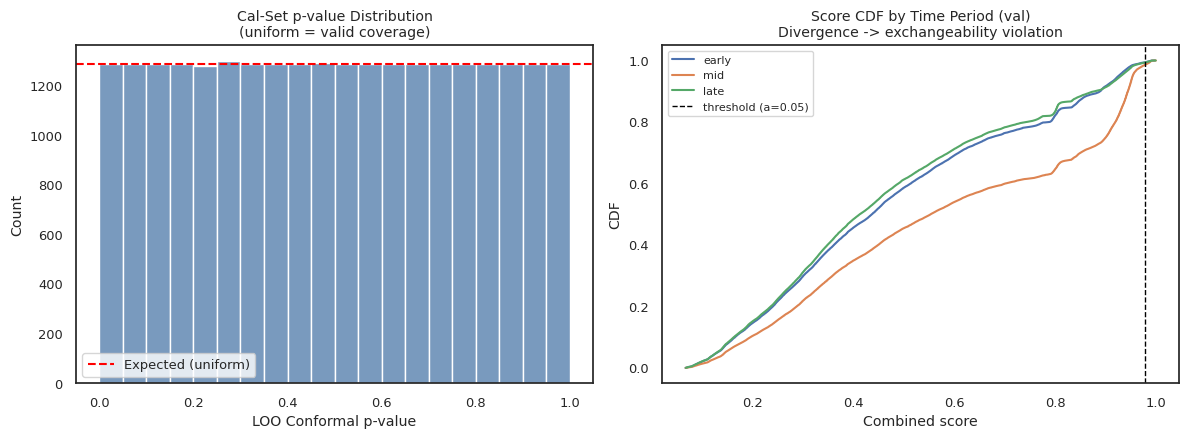

Saved: conformal_validity.png


In [107]:
# ── Conformal validity: empirical coverage & temporal exchangeability ─────────
# Under valid exchangeability, LOO p-values on cal set should be uniform → flag
# rate ≈ alpha. A KS test on score distributions over time checks temporal drift.

from scipy.stats import ks_2samp

# 1) LOO conformal p-values on the calibration (val) set
print(f'Computing LOO p-values on {len(cal_scores):,} cal wallets...')
_cal_loo_p = np.array([
    (np.sum(np.delete(cal_scores, _i) >= cal_scores[_i]) + 1) / len(cal_scores)
    for _i in range(len(cal_scores))
])
_realized_fpr = float((_cal_loo_p <= ALPHA).mean())
print(f'Target alpha              : {ALPHA}')
print(f'Realised flag rate on cal : {_realized_fpr:.4f}  '
      f'({("OK" if abs(_realized_fpr - ALPHA) < 0.01 else "WARN — deviates from alpha")})')

# 2) Temporal exchangeability: KS test across three equal time-thirds of val set
_val_df     = df_flat[df_flat['wallet'].isin(val_wallets)].sort_values('block_timestamp')
_thirds_idx = np.array_split(_val_df.index, 3)
_thirds_sc  = [_val_df.loc[_idx, 'combined_tx_score'].values for _idx in _thirds_idx]
_ks_stat, _ks_p = ks_2samp(_thirds_sc[0], _thirds_sc[2])
print(f'\nKS test (val early vs late third): stat={_ks_stat:.4f}  p={_ks_p:.4e}')
if _ks_p < 0.05:
    print('  WARN: score distribution drifts over time — exchangeability is violated.')
    print('  Recommendation: use weighted conformal prediction (Tibshirani et al., 2019).')
else:
    print('  OK: no significant temporal drift detected.')

# Seaborn plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# p-value histogram (should be uniform)
sns.histplot(_cal_loo_p, bins=20, color='#4C78A8', edgecolor='white', ax=axes[0])
axes[0].axhline(len(_cal_loo_p) / 20, color='red', linestyle='--', label='Expected (uniform)')
axes[0].set_xlabel('LOO Conformal p-value')
axes[0].set_ylabel('Count')
axes[0].set_title('Cal-Set p-value Distribution\n(uniform = valid coverage)')
axes[0].legend()

# CDF by time-third
_cdf_parts = []
for _sc, _lbl in zip(_thirds_sc, ['early', 'mid', 'late']):
    _ss = np.sort(_sc)
    if len(_ss) == 0:
        continue
    _cdf_parts.append(pd.DataFrame({'score': _ss, 'cdf': np.linspace(0, 1, len(_ss)), 'period': _lbl}))

if len(_cdf_parts):
    _cdf_df = pd.concat(_cdf_parts, ignore_index=True)
    sns.lineplot(data=_cdf_df, x='score', y='cdf', hue='period', ax=axes[1])
axes[1].axvline(conformal_threshold, color='black', linestyle='--', linewidth=1, label=f'threshold (a={ALPHA})')
axes[1].set_xlabel('Combined score')
axes[1].set_ylabel('CDF')
axes[1].set_title('Score CDF by Time Period (val)\nDivergence -> exchangeability violation')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('conformal_validity.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: conformal_validity.png')


In [108]:
# ── Wallet score aggregation strategy comparison ──────────────────────────────
# max, mean, and p90 aggregation may produce meaningfully different flag sets.
# High Jaccard / rank-corr → choice is stable; low → motivates principled selection.

def _conformal_flags_simple(cal_s, test_s, alpha):
    thr = np.quantile(cal_s, 1 - alpha)
    return (test_s >= thr).astype(int)

_AGG_FUNS = {
    'max':  lambda x: x.max(),
    'mean': lambda x: x.mean(),
    'p90':  lambda x: np.percentile(x, 90),
}

_agg_flags  = {}
_agg_scores = {}

for _agg_name, _fn in _AGG_FUNS.items():
    _ws    = df_flat.groupby('wallet')['combined_tx_score'].agg(_fn)
    _cal_s = _ws[_ws.index.isin(val_wallets)].values
    _tst_s = _ws[_ws.index.isin(test_wallets)].values
    _agg_flags[_agg_name]  = _conformal_flags_simple(_cal_s, _tst_s, ALPHA)
    _agg_scores[_agg_name] = _tst_s

_base_fl = _agg_flags['max']
_base_sc = _agg_scores['max']

agg_comp_rows = []
for _name, _fl in _agg_flags.items():
    _inter = int(np.sum((_fl == 1) & (_base_fl == 1)))
    _union = int(np.sum((_fl == 1) | (_base_fl == 1)))
    _jac   = _inter / _union if _union > 0 else 1.0
    _rho   = float(spearmanr(_agg_scores[_name], _base_sc).correlation)
    agg_comp_rows.append({'aggregation': _name,
                          'flagged': int(_fl.sum()),
                          'flag_rate_pct': round(float(_fl.mean() * 100), 2),
                          'jaccard_vs_max': round(_jac, 4),
                          'rank_corr_vs_max': round(_rho, 4)})

wallet_agg_df = pd.DataFrame(agg_comp_rows)
print('Wallet aggregation strategy comparison:')
print(wallet_agg_df.to_string(index=False))
print('\nInterpretation: Jaccard < 0.8 or rank_corr < 0.9 means aggregation choice '
      'materially changes which wallets are flagged.')


Wallet aggregation strategy comparison:
aggregation  flagged  flag_rate_pct  jaccard_vs_max  rank_corr_vs_max
        max     1871           7.42          1.0000            1.0000
       mean     2037           8.08          0.6311            0.9515
        p90     1981           7.86          0.8170            0.9944

Interpretation: Jaccard < 0.8 or rank_corr < 0.9 means aggregation choice materially changes which wallets are flagged.


In [148]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import QuantileTransformer\nfrom sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from hdbscan.validity import validity_index as dbcv_validity_index
    HAS_DBCV = True
except Exception:
    HAS_DBCV = False

def extract_tx_latent_mean(model, X_all, device='cpu', batch_size=2048):
    """Mean-pool encoder token states -> one embedding per transaction."""
    model.eval()
    out = []
    import torch
    with torch.no_grad():
        for i in range(0, len(X_all), batch_size):
            xb = torch.from_numpy(X_all[i:i + batch_size]).to(device)
            bsz, n_feat = xb.shape
            pos = torch.arange(n_feat, device=xb.device)
            tok = model.feat_proj(xb.unsqueeze(-1)) + model.pos_embed(pos).unsqueeze(0)
            z = model.encoder(tok)           # (B, F, d_model)
            emb = z.mean(dim=1).cpu().numpy()  # (B, d_model)
            out.append(emb)
    return np.concatenate(out, axis=0)

# One representative transaction per wallet (highest combined score if available)
if 'combined_tx_score' in df_flat.columns:
    rep_tx_idx = df_flat.groupby('wallet')['combined_tx_score'].idxmax()
else:
    rep_rows = df_flat.groupby('wallet', sort=False).head(1)
    rep_tx_idx = pd.Series(rep_rows.index.values, index=rep_rows['wallet'].values)

wallet_rep = rep_tx_idx.index.to_numpy()
idx_rep    = rep_tx_idx.to_numpy(dtype=int)

X_rep      = X_tx_norm[idx_rep].astype(np.float32)
emb_wallet = extract_tx_latent_mean(tr_model, X_rep, device=device, batch_size=2048)

scaler_emb = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42)\nX_emb      = scaler_emb.fit_transform(emb_wallet)

N_ARCHETYPES = 6  # MEV Bot, Sybil/Farming, Drainer, Spam Bot, CPI Exploit, Wash Trading
                  # reference constant for the naming cell — does not constrain clustering

MAX_EVAL_N = 5000
rng = np.random.default_rng(42)
if len(X_emb) > MAX_EVAL_N:
    eval_idx = rng.choice(len(X_emb), size=MAX_EVAL_N, replace=False)
    X_eval   = X_emb[eval_idx]
else:
    eval_idx = np.arange(len(X_emb))
    X_eval   = X_emb

# ── PCA before DBSCAN ────────────────────────────────────────────────────────
# Euclidean ε-neighbourhoods concentrate in high-D (curse of dimensionality),
# flattening the k-NN distance elbow used for eps selection.
# Reduce to ≤20 components (typically ≥85% variance for a structured AE latent).
_n_pca   = min(20, X_emb.shape[1] - 1)
_pca_db  = PCA(n_components=_n_pca, random_state=42).fit(X_eval)
_var_exp = _pca_db.explained_variance_ratio_.cumsum()[-1]
print(f'PCA: {_n_pca} components → {_var_exp*100:.1f}% variance explained')
X_emb_pca  = _pca_db.transform(X_emb)   # (n_wallets, n_pca)
X_eval_pca = X_emb_pca[eval_idx]

MAX_DENSITY_EVAL_N = 3000
X_density = (X_eval_pca if len(X_eval_pca) <= MAX_DENSITY_EVAL_N
             else X_eval_pca[rng.choice(len(X_eval_pca), size=MAX_DENSITY_EVAL_N, replace=False)])

# ── DBSCAN parameter search ───────────────────────────────────────────────────
knn = NearestNeighbors(n_neighbors=11).fit(X_density)
knn_dist, _ = knn.kneighbors(X_density)
eps_candidates = np.unique(np.quantile(np.sort(knn_dist[:, -1]), [0.70, 0.80, 0.90, 0.95]))

dbscan_rows = []
for min_samples in [5, 10, 20]:
    for eps in eps_candidates:
        db        = DBSCAN(eps=float(eps), min_samples=int(min_samples), metric='euclidean', n_jobs=-1)
        labels_db = db.fit_predict(X_density)
        n_clusters = int(len(set(labels_db)) - (1 if -1 in labels_db else 0))
        sil_db = (float(silhouette_score(X_density[labels_db != -1], labels_db[labels_db != -1]))
                  if n_clusters >= 2 and np.sum(labels_db != -1) > 10
                     and len(np.unique(labels_db[labels_db != -1])) >= 2 else np.nan)
        dbcv = (float(dbcv_validity_index(X_density.astype(np.float64), labels_db))
                if HAS_DBCV and n_clusters >= 2 else np.nan)
        dbscan_rows.append({'eps': float(eps), 'min_samples': int(min_samples),
                            'n_clusters': n_clusters, 'noise_frac': float(np.mean(labels_db == -1)),
                            'silhouette_non_noise': sil_db, 'dbcv': dbcv})

dbscan_dbcv_metrics = (pd.DataFrame(dbscan_rows)
                       .sort_values(['dbcv', 'silhouette_non_noise'], ascending=False)
                       .reset_index(drop=True))

# Select best config: maximise DBCV (data-driven — no upper bound on n_clusters).
# Only require n_clusters ≥ 2 and noise_frac < 0.80.
_valid_configs = dbscan_dbcv_metrics[
    (dbscan_dbcv_metrics['n_clusters'] >= 2) &
    (dbscan_dbcv_metrics['noise_frac'] < 0.80)
]
best_dbcv_row = _valid_configs.iloc[0] if len(_valid_configs) > 0 else None

if HAS_DBCV and dbscan_dbcv_metrics['dbcv'].notna().any():
    print('\nDBSCAN configs (top 10, sorted by DBCV):')
else:
    print('\nDBCV unavailable — sorted by silhouette:')
print(dbscan_dbcv_metrics.head(10).to_string(index=False))

if best_dbcv_row is not None:
    print(f'\nSelected: eps={best_dbcv_row["eps"]:.4f}, min_samples={int(best_dbcv_row["min_samples"])}, '
          f'n_clusters={int(best_dbcv_row["n_clusters"])}, noise={best_dbcv_row["noise_frac"]:.2%}')
    best_model = DBSCAN(eps=float(best_dbcv_row['eps']),
                        min_samples=int(best_dbcv_row['min_samples']),
                        metric='euclidean', n_jobs=-1)
else:
    raise RuntimeError('No valid DBSCAN configuration found — check embedding quality.')

labels_full = best_model.fit_predict(X_emb_pca)
print(f'Final labels: {len(set(labels_full) - {-1})} clusters, '
      f'{(labels_full == -1).mean():.1%} noise')

PCA: 20 components → 100.0% variance explained

DBSCAN configs (top 10, sorted by DBCV):
     eps  min_samples  n_clusters  noise_frac  silhouette_non_noise     dbcv
1.419570           10           2    0.023333              0.656617 0.793246
0.509471           10          18    0.238333              0.409865 0.408499
0.509471           20          11    0.317333              0.527768 0.391861
1.419570            5           3    0.014000              0.497257 0.286472
0.756914           20           9    0.226333              0.484331 0.240931
0.509471            5          35    0.176667              0.168683 0.236383
1.083777           10           6    0.048000              0.490223 0.210427
0.756914           10          13    0.139667              0.416951 0.159695
1.083777           20           6    0.109667              0.589109 0.138502
1.083777            5           6    0.028000              0.353781 0.090784

Selected: eps=1.4196, min_samples=10, n_clusters=2, noise=2.33%

In [149]:
# DBSCAN clusters kept as-is — many-to-one naming handles n_clusters > N_ARCHETYPES.
_n_actual = len(set(labels_full) - {-1})
print(f'DBSCAN found {_n_actual} clusters ({N_ARCHETYPES} archetypes defined)')
wallet_embedding_clusters = pd.DataFrame({'wallet': wallet_rep, 'cluster': labels_full})
cluster_map = {c: f'Cluster {c}' if c != -1 else 'Noise' for c in set(labels_full)}
wallet_embedding_clusters['semantic_anomaly_type'] = wallet_embedding_clusters['cluster'].map(cluster_map)

if 'semantic_anomaly_type' in wallet_scores.columns:
  wallet_scores = wallet_scores.drop(columns=['semantic_anomaly_type'])
wallet_scores = wallet_scores.merge(wallet_embedding_clusters[['wallet', 'semantic_anomaly_type']], on='wallet', how='left')
wallet_scores['semantic_anomaly_type'] = wallet_scores['semantic_anomaly_type'].fillna('Unassigned')

if 'semantic_anomaly_type' in df_flat.columns:
  df_flat = df_flat.drop(columns=['semantic_anomaly_type'])
df_flat = df_flat.merge(wallet_embedding_clusters[['wallet', 'semantic_anomaly_type']], on='wallet', how='left')
df_flat['anomaly_type'] = df_flat['semantic_anomaly_type'].fillna('Unassigned')
tx_anomaly_type = df_flat['anomaly_type'].values

print('\nFlagged wallet primary type breakdown (Data-Driven Clusters):')
flagged = wallet_scores[wallet_scores.get('conformal_flag', pd.Series(0)) == 1]
if len(flagged):
  print(flagged['semantic_anomaly_type'].value_counts())


_best_dbcv = float(best_dbcv_row['dbcv']) if best_dbcv_row is not None and np.isfinite(best_dbcv_row.get('dbcv', np.nan)) else np.nan
_best_eps = float(best_dbcv_row['eps']) if best_dbcv_row is not None else np.nan
_best_min_samples = int(best_dbcv_row['min_samples']) if best_dbcv_row is not None else np.nan
transformer_embedding_meta = pd.DataFrame([{
  'n_wallet_embeddings': int(len(X_emb)),
  'n_eval_embeddings': int(len(X_eval)),
  'best_k': int(best_k),
  'sampled_for_eval': bool(len(X_emb) > MAX_EVAL_N),
  'dbcv_available': bool(HAS_DBCV),
  'dbcv_best': _best_dbcv,
  'dbscan_best_eps': _best_eps,
  'dbscan_best_min_samples': _best_min_samples,
}])

DBSCAN found 9 clusters (6 archetypes defined)

Flagged wallet primary type breakdown (Data-Driven Clusters):
semantic_anomaly_type
Cluster 0    1541
Cluster 1     203
Noise          46
Cluster 5      25
Cluster 2      19
Cluster 4      12
Cluster 3      12
Cluster 7       9
Cluster 8       4
Name: count, dtype: int64


Spam bot threshold: 0.3492  (fallback=95th-pctile (0.3492, no genuine valley))
Pass 1 — Spam Bot: 3,506 wallets (5.0%)
         Remaining: 66,603 wallets for Pass 2

Pass 2 — Non-spam clusters (8) → 5 archetypes:
  Cluster     Assigned               cos_sim  greedy                 cos_sim  note
  ----------------------------------------------------------------------------------
  C-0         Novel Behavior          0.0349  MEV Bot                 0.2533  (low sim 0.035)
  C-1         Wash Trading            0.1333  Wash Trading            0.1333  
  C-3         Sybil/Farming           0.0991  Sybil/Farming           0.0991  
  C-4         Novel Behavior          0.2229  CPI Exploit             0.2229  (unassigned by Hungarian)
  C-5         Novel Behavior          0.1935  MEV Bot                 0.1935  (unassigned by Hungarian)
  C-6         Novel Behavior          0.0423  Wash Trading            0.0423  (unassigned by Hungarian)
  C-7         CPI Exploit             0.2500  CPI Explo

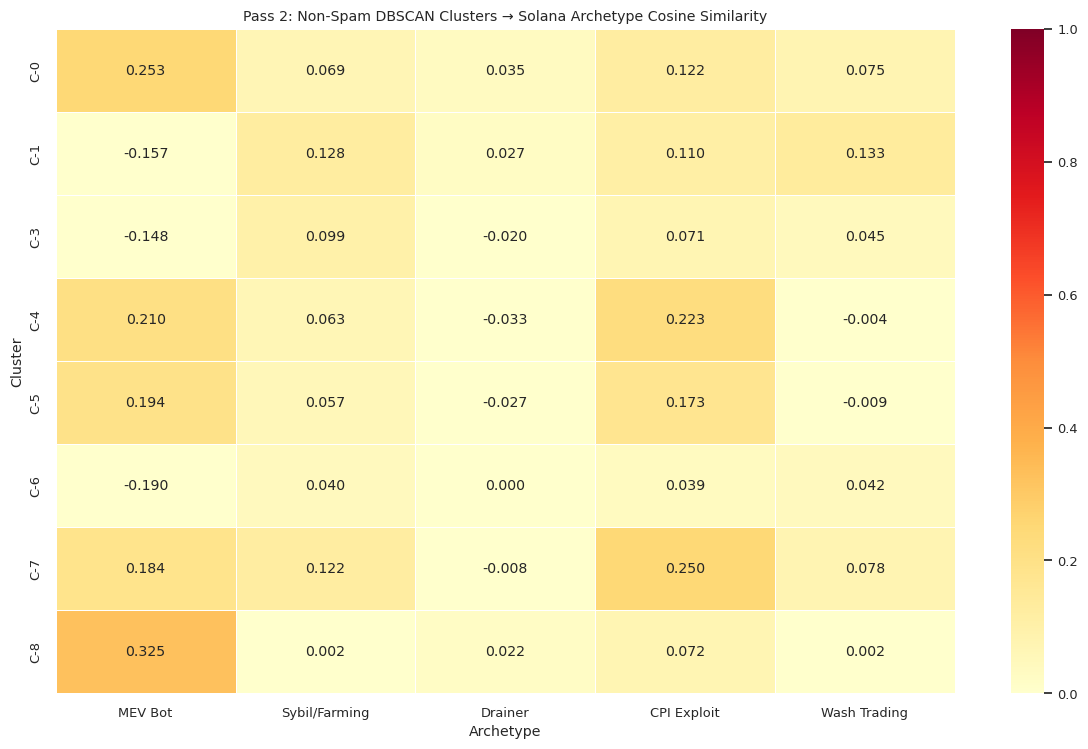


Flagged wallet archetype breakdown:
semantic_anomaly_type
Spam Bot          963
Novel Behavior    679
Wash Trading      178
Unassigned         29
Sybil/Farming      12
CPI Exploit         7
MEV Bot             3
Name: count, dtype: int64


In [152]:
# ── Cluster naming — two-pass, DBSCAN-aware ──────────────────────────────────
# Spam Bot template features (num_instructions, num_writable, has_compute_budget)
# are broadly elevated across anomalous transactions, so greedy cosine similarity
# assigns almost every cluster to Spam Bot. Two-pass fix:
#   Pass 1 — wallet-level KDE threshold on cosine sim → Spam Bot label directly.
#   Pass 2 — Hungarian one-to-one assignment of remaining DBSCAN clusters to the
#             five non-spam archetypes. Low-similarity clusters → Novel Behavior.
# DBSCAN cluster structure is preserved throughout; no re-clustering.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import argrelmin
from scipy.stats import gaussian_kde as _gaussian_kde
from scipy.optimize import linear_sum_assignment

SOLANA_TEMPLATES = {
    # ── Sources ────────────────────────────────────────────────────────────
    # MEV Bot       : Helius MEV Report (helius.dev/blog/solana-mev-report)
    #                 Liu, Jito Bundling & MEV Optimization on Solana (2024)
    # Sybil/Farming : Wormhole Sybil Detection Deep-Dive (wormhole.com, 2024)
    #                 Trusta Labs Airdrop Sybil Identification (github.com/TrustaLabs)
    # Drainer       : Google Cloud, CLINKSINK Drainer Campaigns on Solana (2024)
    #                 SolPhishHunter: arXiv 2505.04094 (Solana phishing taxonomy)
    # Spam Bot      : Helius, Complete History of Solana Outages (helius.dev, 2024)
    #                 The Defiant, Bots Spam Better Than Humans (2024)
    # CPI Exploit   : Asymmetric Research, Invocation Security in Solana CPIs (2024)
    #                 arXiv 2504.07419, Exploring Vulnerabilities in Solana Smart Contracts
    # Wash Trading  : Chainalysis, Crypto Market Manipulation 2025
    #                 Bitquery, Wash Trading on Solana: Case Studies
    #                 ACM Web Conference 2024 (arXiv 2403.10879)
    # ───────────────────────────────────────────────────────────────────────
    'MEV Bot': {
        'fee_sol': 1.0, 'has_compute_budget': 1.0,
        'compute_units_consumed': 1.0, 'fanout_ratio': 0.7,
    },
    'Sybil/Farming': {
        'fanout_ratio': 1.0, 'unique_destinations': 1.0,
        'num_token_transfers': 0.8, 'unique_mints': 0.6,
    },
    'Drainer': {
        'token_accounts_closed': 1.0, 'drain_sol_ratio': 1.0,
        'wallet_sol_delta': 0.8, 'max_balance_change': 0.6,
        'num_post_token_balances': 0.5,
    },
    'Spam Bot': {
        'num_instructions': 1.0, 'num_writable': 0.8,
        'has_compute_budget': 0.6,
    },
    'CPI Exploit': {
        'cpi_ratio': 1.0, 'inner_instructions': 1.0,
        'unique_programs': 0.8, 'unique_instruction_types': 0.7,
        'token_program_calls': 0.5,
    },
    'Wash Trading': {
        'num_token_transfers': 1.0, 'unique_destinations': 0.8,
        'wallet_sol_delta': 0.3, 'unique_mints': 0.4, 'fanout_ratio': 0.2,
    },
}

_feat_idx_map    = {f: i for i, f in enumerate(tx_feature_cols)}
_archetype_names = list(SOLANA_TEMPLATES.keys())

# L2-normalised template matrix  (n_archetypes x n_features)
_T = np.zeros((len(SOLANA_TEMPLATES), len(tx_feature_cols)))
for _row, (_name, _weights) in enumerate(SOLANA_TEMPLATES.items()):
    for _feat, _w in _weights.items():
        if _feat in _feat_idx_map:
            _T[_row, _feat_idx_map[_feat]] = _w
_T = _T / (np.linalg.norm(_T, axis=1, keepdims=True) + 1e-8)

MIN_ASSIGNMENT_SIM = 0.08
MIN_FLAGGED        = 10

_flagged_ws      = wallet_scores[wallet_scores['conformal_flag'].fillna(0).astype(int) == 1]['wallet']
_flagged_tx_mask = df_flat['wallet'].isin(_flagged_ws).values

# ── Pass 1: Spam Bot identification (wallet-level KDE threshold) ──────────────
_spam_bot_idx  = _archetype_names.index('Spam Bot')
_spam_template = _T[_spam_bot_idx]

_rep_features    = X_tx_norm[idx_rep]
_rep_norms       = np.linalg.norm(_rep_features, axis=1, keepdims=True) + 1e-8
_wallet_spam_cos = (_rep_features / _rep_norms) @ _spam_template

_kde_fit  = _gaussian_kde(_wallet_spam_cos, bw_method=0.15)
_xs       = np.linspace(_wallet_spam_cos.min(), _wallet_spam_cos.max(), 500)
_ys       = _kde_fit(_xs)
_lmin_idx = argrelmin(_ys, order=10)[0]
_valid    = _lmin_idx[_xs[_lmin_idx] > 0.20]

SPAM_BOT_THRESHOLD = float(max(np.percentile(_wallet_spam_cos, 95), 0.20))
_threshold_source  = f'fallback=95th-pctile ({SPAM_BOT_THRESHOLD:.4f}, no genuine valley)'
for _vi in _valid:
    _valley_den = _ys[_vi]
    _left_peak  = _ys[:_vi].max()
    _right_peak = _ys[_vi:].max()
    _min_peak   = min(_left_peak, _right_peak)
    if _valley_den < 0.5 * _min_peak:
        SPAM_BOT_THRESHOLD = float(_xs[_vi])
        _threshold_source  = f'KDE valley (depth {_valley_den/(_min_peak+1e-12):.2f} < 0.5)'
        break

print(f'Spam bot threshold: {SPAM_BOT_THRESHOLD:.4f}  ({_threshold_source})')
_is_spam = _wallet_spam_cos >= SPAM_BOT_THRESHOLD
print(f'Pass 1 — Spam Bot: {_is_spam.sum():,} wallets ({100*_is_spam.mean():.1f}%)')
print(f'         Remaining: {(~_is_spam).sum():,} wallets for Pass 2')

_wallet_archetype = pd.Series('Unassigned', index=wallet_rep, dtype=object)
_wallet_archetype[wallet_rep[_is_spam]] = 'Spam Bot'

# ── Pass 2: Hungarian on non-spam wallets → DBSCAN cluster profiles ───────────
_non_spam_archetypes = [a for a in _archetype_names if a != 'Spam Bot']
_T_ns = np.array([_T[_archetype_names.index(a)] for a in _non_spam_archetypes])

# Map wallets to DBSCAN cluster; restrict to non-spam wallets
_wallet_to_cluster = dict(zip(wallet_rep, labels_full))
_cluster_col       = df_flat['wallet'].map(_wallet_to_cluster)
_non_spam_wallets  = set(wallet_rep[~_is_spam])
_non_spam_tx_mask  = df_flat['wallet'].isin(_non_spam_wallets).values

_unique_ns_clusters = sorted(
    c for c in set(labels_full[~_is_spam]) if c != -1
)
_n_ns = len(_non_spam_archetypes)

cluster_naming_rows = []
_profiles   = {}
_sim_matrix = np.zeros((len(_unique_ns_clusters), _n_ns))

for _i, _cid in enumerate(_unique_ns_clusters):
    _mask_flagged = (_cluster_col == _cid).values & _flagged_tx_mask & _non_spam_tx_mask
    _mask_all     = (_cluster_col == _cid).values & _non_spam_tx_mask
    _mask = _mask_flagged if _mask_flagged.sum() >= MIN_FLAGGED else _mask_all
    if _mask.sum() == 0:
        continue
    _prof  = X_tx_norm[_mask].mean(axis=0)
    _pnorm = np.linalg.norm(_prof) + 1e-8
    if _pnorm < 1e-6:
        continue
    _profiles[_i] = (_cid, _prof)
    _sim_matrix[_i] = _T_ns @ (_prof / _pnorm)

# Hungarian: one-to-one maximising total cosine similarity
_active = sorted(_profiles.keys())
_sim_sub = _sim_matrix[_active]
_row_ind, _col_ind = linear_sum_assignment(-_sim_sub)
_hungarian_map = {_active[r]: int(c) for r, c in zip(_row_ind, _col_ind)}

print(f'\nPass 2 — Non-spam clusters ({len(_unique_ns_clusters)}) → {_n_ns} archetypes:')
print(f'  {"Cluster":<10}  {"Assigned":<20}  {"cos_sim":>8}  {"greedy":<20}  {"cos_sim":>8}  note')
print('  ' + '-' * 82)

for _i in _active:
    _cid, _prof = _profiles[_i]
    _sims   = _sim_matrix[_i]
    _ranked = np.argsort(_sims)[::-1]
    # Clusters not covered by Hungarian (n_clusters > n_archetypes) → Novel Behavior
    _in_hungarian = _i in _hungarian_map
    _assigned_col = _hungarian_map[_i] if _in_hungarian else None
    _greedy   = _non_spam_archetypes[_ranked[0]]
    _greedy_s = float(_sims[_ranked[0]])

    if not _in_hungarian:
        _best_s = float(_sims[_ranked[0]])
        _best  = 'Novel Behavior'
        _note  = '(unassigned by Hungarian)'
    elif _sims[_assigned_col] >= MIN_ASSIGNMENT_SIM:
        _best_s = float(_sims[_assigned_col])
        _best  = _non_spam_archetypes[_assigned_col]
        _note  = '(reassigned)' if _assigned_col != _ranked[0] else ''
    else:
        _best_s = float(_sims[_assigned_col])
        _best  = 'Novel Behavior'
        _note  = f'(low sim {_best_s:.3f})'

    print(f'  {f"C-{_cid}":<10}  {_best:<20}  {_best_s:>8.4f}  {_greedy:<20}  {_greedy_s:>8.4f}  {_note}')

    _wallets_in = wallet_rep[np.array([_wallet_to_cluster.get(w, -2) == _cid
                                        for w in wallet_rep]) & ~_is_spam]
    _wallet_archetype[_wallets_in] = _best

    cluster_naming_rows.append({
        'cluster': f'C-{_cid}', 'pass': 2,
        'assigned_archetype': _best,
        'cosine_similarity': round(_best_s, 4),
        'greedy_archetype': _greedy,
        'greedy_cosine_sim': round(_greedy_s, 4),
        'reassigned': _assigned_col != _ranked[0],
        **{f'sim_{n}': round(float(s), 4) for n, s in zip(_non_spam_archetypes, _sims)}
    })

# Noise (-1) → Unassigned
_wallet_archetype = _wallet_archetype.fillna('Unassigned')
cluster_naming_df = pd.DataFrame(cluster_naming_rows)

# ── Apply to wallet_scores and df_flat ────────────────────────────────────────
_arch_merge = (_wallet_archetype
               .rename('semantic_anomaly_type')
               .reset_index()
               .rename(columns={'index': 'wallet'}))

if 'semantic_anomaly_type' in wallet_scores.columns:
    wallet_scores = wallet_scores.drop(columns=['semantic_anomaly_type'])
wallet_scores = wallet_scores.merge(_arch_merge, on='wallet', how='left')
wallet_scores['semantic_anomaly_type'] = wallet_scores['semantic_anomaly_type'].fillna('Unassigned')

if 'semantic_anomaly_type' in df_flat.columns:
    df_flat = df_flat.drop(columns=['semantic_anomaly_type'])
df_flat = df_flat.merge(_arch_merge, on='wallet', how='left')
df_flat['semantic_anomaly_type'] = df_flat['semantic_anomaly_type'].fillna('Unassigned')

# ── Cosine similarity heatmap ─────────────────────────────────────────────────
if len(cluster_naming_df) > 0:
    _sim_cols   = [f'sim_{n}' for n in _non_spam_archetypes]
    _avail_cols = [c for c in _sim_cols if c in cluster_naming_df.columns]
    if _avail_cols:
        _sim_mat = cluster_naming_df.set_index('cluster')[_avail_cols].copy()
        _sim_mat.columns = [c.replace('sim_', '') for c in _avail_cols]
        fig, ax = plt.subplots(figsize=(12, max(3, len(cluster_naming_df) * 0.7 + 2)))
        sns.heatmap(_sim_mat, annot=True, fmt='.3f', cmap='YlOrRd',
                    vmin=0, vmax=1, ax=ax, linewidths=0.5)
        ax.set_title('Pass 2: Non-Spam DBSCAN Clusters → Solana Archetype Cosine Similarity')
        ax.set_xlabel('Archetype')
        ax.set_ylabel('Cluster')
        plt.tight_layout()
        plt.savefig('cluster_archetype_cosine.png', dpi=120, bbox_inches='tight')
        plt.show()
        plt.close()

print('\nFlagged wallet archetype breakdown:')
_flagged = wallet_scores[wallet_scores['conformal_flag'].fillna(0).astype(int) == 1]
if len(_flagged):
    print(_flagged['semantic_anomaly_type'].value_counts())

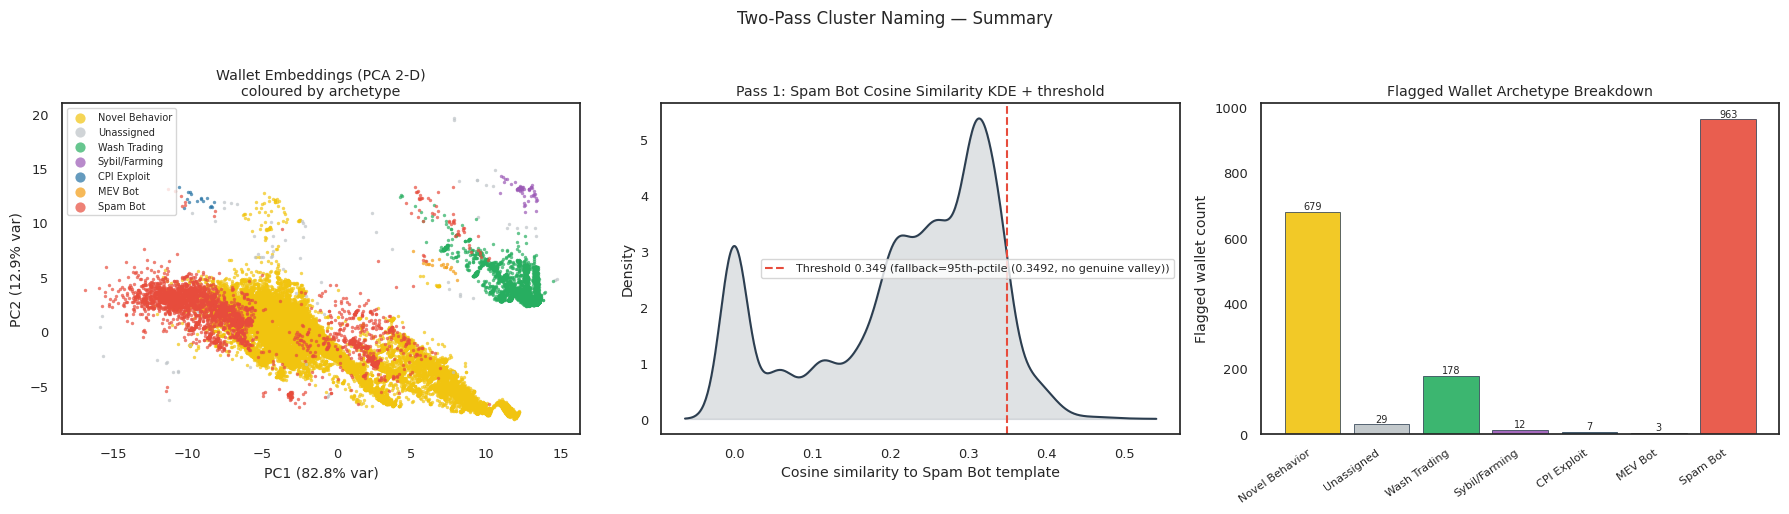

Saved: cluster_visualisation.png


In [165]:
# ── Cluster visualisation ─────────────────────────────────────────────────────
from sklearn.decomposition import PCA

# Render order derived from data: background categories first, Spam Bot last.
# Using value_counts ensures only present labels appear in plots.
_bg   = {'Unassigned', 'Novel Behavior'}
_fg   = {'Spam Bot'}
_present = _wa_series.unique().tolist()
_arch_order = ([a for a in _present if a in _bg] +
               [a for a in _present if a not in _bg and a not in _fg] +
               [a for a in _present if a in _fg])
_palette     = {'Spam Bot': '#e74c3c',      # red
                'MEV Bot': '#f39c12',        # amber
                'Sybil/Farming': '#9b59b6',  # purple
                'Drainer': '#1abc9c',        # teal
                'CPI Exploit': '#2471a3',    # blue
                'Wash Trading': '#27ae60',   # green
                'Novel Behavior': '#f1c40f', # yellow — clearly not grey
                'Unassigned': '#bdc3c7'}     # light grey — background

# Map wallet → archetype for all wallets (index-aligned with X_emb)
_wa_series = _wallet_archetype.reindex(wallet_rep).fillna('Unassigned')


_colors    = [_palette.get(a, '#bdc3c7') for a in _wa_series.values]

# PCA 2-D projection of Transformer embeddings
_pca   = PCA(n_components=2, random_state=42)
_emb2d = _pca.fit_transform(X_emb)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: archetype scatter (PCA 2-D) ────────────────────────────────────
ax = axes[0]
for _arch in _arch_order:
    _m = _wa_series.values == _arch
    if _m.any():
        ax.scatter(_emb2d[_m, 0], _emb2d[_m, 1],
                   c=_palette.get(_arch, '#bdc3c7'), label=_arch,
                   s=6, alpha=0.7, linewidths=0)
ax.set_title('Wallet Embeddings (PCA 2-D)\ncoloured by archetype')
ax.set_xlabel(f'PC1 ({_pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({_pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.legend(markerscale=3, fontsize=7, loc='best')

# ── Panel 2: spam cosine KDE + threshold ─────────────────────────────────────
ax = axes[1]
_xs_plot = np.linspace(_wallet_spam_cos.min(), _wallet_spam_cos.max(), 500)
_ys_plot = _kde_fit(_xs_plot)
ax.plot(_xs_plot, _ys_plot, color='#2c3e50', lw=1.5)
ax.fill_between(_xs_plot, _ys_plot, alpha=0.15, color='#2c3e50')
ax.axvline(SPAM_BOT_THRESHOLD, color='#e74c3c', lw=1.5, ls='--', 
           label=f'Threshold {SPAM_BOT_THRESHOLD:.3f} ({_threshold_source})')
ax.set_xlabel('Cosine similarity to Spam Bot template')
ax.set_ylabel('Density')
ax.set_title('Pass 1: Spam Bot Cosine Similarity KDE + threshold')
ax.legend(fontsize=8)

# ── Panel 3: flagged wallet archetype breakdown ──────────────────────────────
ax = axes[2]
_flagged_arch = wallet_scores[wallet_scores['conformal_flag'].fillna(0).astype(int) == 1]['semantic_anomaly_type']
_flag_counts  = _flagged_arch.value_counts().reindex(_arch_order, fill_value=0)

_x = np.arange(len(_arch_order))
ax.bar(_x, _flag_counts.values,
       color=[_palette.get(a, '#bdc3c7') for a in _arch_order],
       alpha=0.9, edgecolor='#2c3e50', linewidth=0.6)
for _xi, _v in zip(_x, _flag_counts.values):
    if _v > 0:
        ax.text(_xi, _v + 1, str(_v), ha='center', va='bottom', fontsize=7)
ax.set_xticks(_x)
ax.set_xticklabels(_arch_order, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Flagged wallet count')
ax.set_title('Flagged Wallet Archetype Breakdown')

plt.suptitle('Two-Pass Cluster Naming — Summary', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('cluster_visualisation.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: cluster_visualisation.png')

In [155]:
# ── Final output ──────────────────────────────────────────────────────────────
df_flat['if_tx_score']  = if_tx_score
df_flat['tr_tx_score']  = tr_tx_score
df_flat['anomaly_type'] = tx_anomaly_type

wallet_scores['risk_score'] = -np.log10(
    np.clip(wallet_scores['conformal_p'].fillna(1.0), 1e-12, 1.0))
wallet_scores['risk_tier'] = pd.cut(
    wallet_scores['risk_score'],
    bins=[-np.inf, 1, 2, 3, np.inf],
    labels=['low', 'medium', 'high', 'critical'])

print('Wallet scores shape :', wallet_scores.shape)
print('df_flat shape       :', df_flat.shape)
print('\nTop 20 wallets by raw_score:')
show = ['wallet','raw_score','if_score','tr_score','semantic_anomaly_type',
        'conformal_p','conformal_flag','risk_tier','n_tx']
show = [c for c in show if c in wallet_scores.columns]
print(wallet_scores.nlargest(20, 'raw_score')[show].to_string(index=False))

# ── Optional: save ────────────────────────────────────────────────────────────
# wallet_scores.to_parquet('/home/ubuntu/data/chunks/wallet_scores.parquet', index=False)
# df_flat.to_parquet('/home/ubuntu/data/chunks/transactions_scored.parquet', index=False)

Wallet scores shape : (70109, 13)
df_flat shape       : (910000, 51)

Top 20 wallets by raw_score:
                                      wallet  raw_score  if_score  tr_score semantic_anomaly_type  conformal_p  conformal_flag risk_tier  n_tx
5qhFTDU5YX7D2kymawuvMK3rBCH4qjryQLcEhP4fR3xA   0.999978  0.999967  0.999990              Spam Bot     0.000039             1.0  critical     1
CTZ7qzj91AeTV3Pv9MfMz7q7TjpMqQZmXKz6K7rgEyHj   0.999690  0.999390  0.999990            Unassigned          NaN             NaN       low     1
5yRjKZSBTAxemkh8Jtjp4M7fbYxLGBpwjAKgg35KLx36   0.999518  0.999047  0.999990              Spam Bot     0.000078             1.0  critical     1
2MEW6xNgiPZQ7BTdAJvpzH19SZCvrGzmrXiY6URzAWzv   0.999490  0.998990  0.999990        Novel Behavior     0.000078             1.0  critical     1
 w9bgfCnzCerU21nzL9R22Mte3crNahZXioKujJFpYCE   0.999298  0.998617  0.999980        Novel Behavior     0.000078             1.0  critical     1
8ooa4LuYrk7BBdbkPPqcFYA3ZzNQnAG8nLq8CUKZzVb

In [156]:
# ── External baselines: LOF, One-Class SVM, MLP Autoencoder ──────────────────
# Compared to the baseline (IF + Transformer AE) via wallet-level Jaccard
# and rank correlation on the test set.  No labels required.

from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm       import OneClassSVM

# ── LOF ──────────────────────────────────────────────────────────────────────
print('Fitting LOF ...')
_lof = LocalOutlierFactor(n_neighbors=20, contamination='auto',
                          novelty=True, n_jobs=-1)
_rng_lof = np.random.default_rng(42)
_lof_n = train_mask_tx.sum()
_lof_idx = _rng_lof.choice(_lof_n, size=min(25000, _lof_n), replace=False)
_lof.fit(X_tx_norm[train_mask_tx][_lof_idx])
_lof_raw        = -_lof.decision_function(X_tx_norm)
_lof_train_sort = np.sort(_lof_raw[train_mask_tx])
_lof_score      = np.searchsorted(_lof_train_sort, _lof_raw, side='right') / len(_lof_train_sort)
lof_wallet_score = (pd.Series(_lof_score, index=df_flat.index)
                    .groupby(df_flat['wallet']).max()
                    .rename('lof_score'))

# ── One-Class SVM (subsample — OCSVM doesn't scale to 500 k rows) ────────────
print('Fitting OCSVM (15 k train sample) ...')
_rng_oc  = np.random.default_rng(42)
_oc_n    = train_mask_tx.sum()
_oc_idx  = _rng_oc.choice(_oc_n, size=min(15000, _oc_n), replace=False)
_ocsvm   = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
_ocsvm.fit(X_tx_norm[train_mask_tx][_oc_idx])
_ocsvm_raw        = -_ocsvm.decision_function(X_tx_norm)
_ocsvm_train_sort = np.sort(_ocsvm_raw[train_mask_tx])
_ocsvm_score      = np.searchsorted(_ocsvm_train_sort, _ocsvm_raw, side='right') / len(_ocsvm_train_sort)
ocsvm_wallet_score = (pd.Series(_ocsvm_score, index=df_flat.index)
                      .groupby(df_flat['wallet']).max()
                      .rename('ocsvm_score'))

# ── MLP Autoencoder ───────────────────────────────────────────────────────────
print('Fitting MLP AE ...')
class MlpAE(nn.Module):
    def __init__(self, n_feat, hidden=64):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(n_feat, hidden), nn.ReLU(),
                                 nn.Linear(hidden, 32),     nn.ReLU())
        self.dec = nn.Sequential(nn.Linear(32, hidden),     nn.ReLU(),
                                 nn.Linear(hidden, n_feat))
    def forward(self, x):
        return self.dec(self.enc(x))

_mlp = MlpAE(X_tx_norm.shape[1]).to(device)
_mlp_opt = torch.optim.Adam(_mlp.parameters(), lr=1e-3)
_mlp_dl  = DataLoader(TensorDataset(torch.from_numpy(X_tx_norm[train_mask_tx])),
                      batch_size=256, shuffle=True)
_mlp.train()
for _ep in range(6):
    _tot = 0
    for (_xb,) in _mlp_dl:
        _xb  = _xb.to(device)
        _l   = nn.functional.mse_loss(_mlp(_xb), _xb)
        _mlp_opt.zero_grad(); _l.backward(); _mlp_opt.step()
        _tot += _l.item()
    print(f'  MLP AE epoch {_ep+1}/6  loss={_tot/len(_mlp_dl):.6f}')

_mlp.eval()
_mlp_err = []
with torch.no_grad():
    for _i in range(0, len(X_tx_norm), 1024):
        _xb = torch.from_numpy(X_tx_norm[_i:_i+1024]).to(device)
        _mlp_err.append(((_mlp(_xb) - _xb)**2).mean(dim=1).cpu().numpy())
_mlp_raw        = np.concatenate(_mlp_err)
_mlp_train_sort = np.sort(_mlp_raw[train_mask_tx])
_mlp_score      = np.searchsorted(_mlp_train_sort, _mlp_raw, side='right') / len(_mlp_train_sort)
mlp_wallet_score = (pd.Series(_mlp_score, index=df_flat.index)
                    .groupby(df_flat['wallet']).max()
                    .rename('mlp_score'))

# ── Wallet-level comparison ───────────────────────────────────────────────────
_comp_ws = (wallet_scores[['wallet', 'raw_score']]
            .merge(lof_wallet_score.reset_index(),   on='wallet', how='left')
            .merge(ocsvm_wallet_score.reset_index(), on='wallet', how='left')
            .merge(mlp_wallet_score.reset_index(),   on='wallet', how='left'))
_comp_ws = _comp_ws.rename(columns={'raw_score': 'baseline'})

_val_m  = _comp_ws['wallet'].isin(val_wallets).values
_test_m = _comp_ws['wallet'].isin(test_wallets).values

_base_cal  = _comp_ws.loc[_val_m,  'baseline'].values
_base_test = _comp_ws.loc[_test_m, 'baseline'].values
_base_fl   = (_base_test >= np.quantile(_base_cal, 1 - ALPHA)).astype(int)

_ext_rows = []
for _det in ['baseline', 'lof_score', 'ocsvm_score', 'mlp_score']:
    _cal_s  = _comp_ws.loc[_val_m,  _det].fillna(0).values
    _test_s = _comp_ws.loc[_test_m, _det].fillna(0).values
    _fl     = (_test_s >= np.quantile(_cal_s, 1 - ALPHA)).astype(int)
    _inter  = int(np.sum((_fl == 1) & (_base_fl == 1)))
    _union  = int(np.sum((_fl == 1) | (_base_fl == 1)))
    _jac    = _inter / _union if _union > 0 else 1.0
    _rho    = float(spearmanr(_test_s, _base_test).correlation)
    _ext_rows.append({'detector': _det,
                      'flagged': int(_fl.sum()),
                      'flag_rate_pct': round(float(_fl.mean() * 100), 2),
                      'jaccard_vs_baseline': round(_jac, 4),
                      'rank_corr_vs_baseline': round(_rho, 4)})

external_baselines_df = pd.DataFrame(_ext_rows)
print('\nExternal baseline comparison (wallet-level):')
print(external_baselines_df.to_string(index=False))
print('\nInterpretation: high Jaccard/rank-corr with baseline → consistent signal;'
      ' low → detectors disagree on which wallets are anomalous.')


Fitting LOF ...
Fitting OCSVM (15 k train sample) ...
Fitting MLP AE ...
  MLP AE epoch 1/6  loss=0.438562
  MLP AE epoch 2/6  loss=0.020663
  MLP AE epoch 3/6  loss=0.011518
  MLP AE epoch 4/6  loss=0.008083
  MLP AE epoch 5/6  loss=0.006056
  MLP AE epoch 6/6  loss=0.004813

External baseline comparison (wallet-level):
   detector  flagged  flag_rate_pct  jaccard_vs_baseline  rank_corr_vs_baseline
   baseline     1871           7.42               1.0000                 1.0000
  lof_score     1960           7.77               0.0603                 0.2327
ocsvm_score     1477           5.86               0.2228                -0.0186
  mlp_score     1514           6.00               0.2247                 0.4210

Interpretation: high Jaccard/rank-corr with baseline → consistent signal; low → detectors disagree on which wallets are anomalous.


In [115]:
# ── 2. Ablation: component contribution vs baseline ───────────────────────────

def conformal_flags(cal_scores, test_scores, alpha):
    threshold = np.quantile(cal_scores, 1 - alpha)
    pvals = np.array([
        (np.sum(cal_scores >= s) + 1) / (len(cal_scores) + 1)
        for s in test_scores
    ])
    flags = (pvals <= alpha).astype(int)
    return threshold, pvals, flags

val_mask_w  = wallet_scores['wallet'].isin(val_wallets).values
test_mask_w = wallet_scores['wallet'].isin(test_wallets).values

score_sets = {
    'baseline': wallet_scores['raw_score'].values,
    'if_only': wallet_scores['if_score'].values,
    'tr_only': wallet_scores['tr_score'].values,
}

_, _, baseline_test_flags = conformal_flags(
    score_sets['baseline'][val_mask_w],
    score_sets['baseline'][test_mask_w],
    ALPHA,
)

rows = []
for name, scores in score_sets.items():
    thr, pvals, flags = conformal_flags(scores[val_mask_w], scores[test_mask_w], ALPHA)

    inter = np.sum((flags == 1) & (baseline_test_flags == 1))
    union = np.sum((flags == 1) | (baseline_test_flags == 1))
    jaccard = inter / union if union > 0 else 1.0

    rows.append({
        'run': name,
        'threshold': float(thr),
        'flagged_wallets': int(flags.sum()),
        'flag_rate_pct': float(flags.mean() * 100),
        'jaccard_vs_baseline': float(jaccard),
    })

ablation_results = pd.DataFrame(rows)
base_rate = float(ablation_results.loc[ablation_results['run'] == 'baseline', 'flag_rate_pct'].iloc[0])
ablation_results['delta_rate_vs_baseline'] = ablation_results['flag_rate_pct'] - base_rate

print('Ablation results (wallet-level conformal flags):')
print(ablation_results.sort_values('run').to_string(index=False))

Ablation results (wallet-level conformal flags):
     run  threshold  flagged_wallets  flag_rate_pct  jaccard_vs_baseline  delta_rate_vs_baseline
baseline   0.977548             1871       7.419598             1.000000                0.000000
 if_only   0.994845             2062       8.177023             0.392705                0.757426
 tr_only   0.993160             1852       7.344252             0.069213               -0.075346


In [116]:
# ── Bootstrap confidence intervals for ablation Jaccard ───────────────────────
# Adds 95 % CI to each ablation variant to quantify estimation uncertainty.

_rng_bs = np.random.default_rng(42)
_N_BOOT = 1000

_val_w_arr  = wallet_scores['wallet'].isin(val_wallets).values
_test_w_arr = wallet_scores['wallet'].isin(test_wallets).values

def _bootstrap_jaccard(score_arr, base_arr, val_m, test_m, alpha, n_boot, rng):
    _cal_s  = score_arr[val_m];  _tst_s  = score_arr[test_m]
    _bcal_s = base_arr[val_m];   _btst_s = base_arr[test_m]
    _jacs   = []
    for _ in range(n_boot):
        _bi  = rng.choice(len(_tst_s), size=len(_tst_s), replace=True)
        _fl  = (_tst_s[_bi]  >= np.quantile(_cal_s,  1 - alpha)).astype(int)
        _bfl = (_btst_s[_bi] >= np.quantile(_bcal_s, 1 - alpha)).astype(int)
        _i   = np.sum((_fl == 1) & (_bfl == 1))
        _u   = np.sum((_fl == 1) | (_bfl == 1))
        _jacs.append(_i / _u if _u > 0 else 1.0)
    _j = np.array(_jacs)
    return float(np.mean(_j)), float(np.percentile(_j, 2.5)), float(np.percentile(_j, 97.5))

_baseline_arr = score_sets['baseline']
bs_rows = []
for _name, _scores in score_sets.items():
    _m, _lo, _hi = _bootstrap_jaccard(_scores, _baseline_arr,
                                       _val_w_arr, _test_w_arr,
                                       ALPHA, _N_BOOT, _rng_bs)
    bs_rows.append({'run': _name,
                    'jaccard_mean': round(_m,  4),
                    'ci_2.5':       round(_lo, 4),
                    'ci_97.5':      round(_hi, 4),
                    'ci_width':     round(_hi - _lo, 4)})

bootstrap_ci_df = pd.DataFrame(bs_rows)
print(f'Bootstrap Jaccard CIs (n_boot={_N_BOOT}, 95 % CI):')
print(bootstrap_ci_df.to_string(index=False))


Bootstrap Jaccard CIs (n_boot=1000, 95 % CI):
     run  jaccard_mean  ci_2.5  ci_97.5  ci_width
baseline        1.0000  1.0000   1.0000    0.0000
 if_only        0.3925  0.3750   0.4097    0.0347
 tr_only        0.0691  0.0606   0.0776    0.0170


In [117]:
# ── 3. Sensitivity: stability across hyperparameter ranges ───────────────────

w_if_grid = [0.30, 0.40, 0.50, 0.60, 0.70]
alpha_grid = [0.005, 0.01, 0.02]

if_all = wallet_scores['if_score'].values
tr_all = wallet_scores['tr_score'].values

baseline_test_scores = score_sets['baseline'][test_mask_w]

sens_rows = []
for w_if in w_if_grid:
    w_tr = 1.0 - w_if
    mixed_scores = w_if * if_all + w_tr * tr_all

    for alpha in alpha_grid:
        _, _, flags = conformal_flags(mixed_scores[val_mask_w], mixed_scores[test_mask_w], alpha)

        inter = np.sum((flags == 1) & (baseline_test_flags == 1))
        union = np.sum((flags == 1) | (baseline_test_flags == 1))
        jaccard = inter / union if union > 0 else 1.0

        rho = spearmanr(mixed_scores[test_mask_w], baseline_test_scores).correlation
        if np.isnan(rho):
            rho = 0.0

        sens_rows.append({
            'w_if': float(w_if),
            'w_tr': float(w_tr),
            'alpha': float(alpha),
            'flag_rate_pct': float(flags.mean() * 100),
            'jaccard_vs_baseline': float(jaccard),
            'rank_corr_vs_baseline': float(rho),
        })

sensitivity_results = pd.DataFrame(sens_rows)
print('Sensitivity sweep:')
print(sensitivity_results.sort_values(['alpha', 'w_if']).to_string(index=False))

Sensitivity sweep:
 w_if  w_tr  alpha  flag_rate_pct  jaccard_vs_baseline  rank_corr_vs_baseline
  0.3   0.7  0.005       0.801047             0.081377               0.735919
  0.4   0.6  0.005       0.797081             0.080856               0.935980
  0.5   0.5  0.005       0.824840             0.085073               0.985357
  0.6   0.4  0.005       0.801047             0.091053               0.966175
  0.7   0.3  0.005       0.797081             0.099204               0.923129
  0.3   0.7  0.010       1.320538             0.113694               0.735919
  0.4   0.6  0.010       1.391918             0.135992               0.935980
  0.5   0.5  0.010       1.530713             0.173077               0.985357
  0.6   0.4  0.010       1.538645             0.185205               0.966175
  0.7   0.3  0.010       1.538645             0.193975               0.923129
  0.3   0.7  0.020       2.688662             0.255665               0.735919
  0.4   0.6  0.020       2.882976            

In [118]:
# ── Statistical significance tests ──────────────────────────────────────────
# McNemar's test: are the disagreements between baseline and each comparison
# detector asymmetric?  This is the correct paired test for binary detectors —
# it asks whether one detector consistently flags wallets the other misses,
# beyond what chance would produce.
#
# Covers two groups:
#   (A) Ablation variants  — baseline vs if_only, tr_only
#   (B) External baselines — baseline vs LOF, OCSVM, MLP AE
# Both groups use the same conformal threshold (alpha=ALPHA on val wallets).

from statsmodels.stats.contingency_tables import mcnemar

_val_w_arr  = wallet_scores['wallet'].isin(val_wallets).values
_test_w_arr = wallet_scores['wallet'].isin(test_wallets).values

def _get_flags(score_arr, val_m, test_m, alpha):
    thr = np.quantile(score_arr[val_m], 1 - alpha)
    return (score_arr[test_m] >= thr).astype(int)

_base_fl = _get_flags(score_sets['baseline'], _val_w_arr, _test_w_arr, ALPHA)

# ── Build combined comparison dict: ablation + external baselines ─────────────
_all_comparisons = dict(score_sets)   # baseline, if_only, tr_only

if '_comp_ws' in globals() and isinstance(_comp_ws, pd.DataFrame):
    _ext_score_cols = {
        'lof':   'lof_score',
        'ocsvm': 'ocsvm_score',
        'mlp':   'mlp_score',
    }
    for _ext_name, _col in _ext_score_cols.items():
        if _col in _comp_ws.columns:
            # Align to wallet_scores index order
            _ext_aligned = (
                _comp_ws[['wallet', _col]]
                .drop_duplicates('wallet')
                .set_index('wallet')
                .reindex(wallet_scores['wallet'])
                [_col]
                .fillna(0.0)
                .values
            )
            _all_comparisons[_ext_name] = _ext_aligned

# ── McNemar test ──────────────────────────────────────────────────────────────
_mcnemar_rows = []
print('McNemar test (baseline vs comparison detector, test-set wallet flags):')
print(f'  {"comparison":<32} {"group":<10} {"chi2":>8} {"p-value":>12} {"sig?":>6}')
print('  ' + '-' * 74)

_group_map = {'if_only': 'ablation', 'tr_only': 'ablation',
              'lof': 'external', 'ocsvm': 'external', 'mlp': 'external'}

for _nm, _scores in _all_comparisons.items():
    if _nm == 'baseline':
        continue
    _cmp_fl = _get_flags(_scores, _val_w_arr, _test_w_arr, ALPHA)
    _b = int(np.sum((_base_fl == 1) & (_cmp_fl == 0)))  # baseline-only
    _c = int(np.sum((_base_fl == 0) & (_cmp_fl == 1)))  # comparator-only
    if _b + _c == 0:
        print(f'  {"baseline vs " + _nm:<32} {"n/a":<10} {"—":>8} {"—":>12} {"—":>6}')
        print(f'    no disagreements between detectors')
        continue
    _res  = mcnemar([[0, _b], [_c, 0]], exact=False, correction=True)
    _sig  = 'YES' if _res.pvalue < 0.05 else 'no'
    _grp  = _group_map.get(_nm, 'ablation')
    print(f'  {"baseline vs " + _nm:<32} {_grp:<10} {_res.statistic:>8.3f} {_res.pvalue:>12.4e} {_sig:>6}')
    print(f'    baseline-only: {_b}  |  {_nm}-only: {_c}')
    _mcnemar_rows.append({
        'comparison': f'baseline vs {_nm}',
        'group': _grp,
        'baseline_only_flags': _b,
        'comparator_only_flags': _c,
        'chi2': round(float(_res.statistic), 4),
        'pvalue': float(_res.pvalue),
        'significant_p05': _res.pvalue < 0.05,
    })

mcnemar_results = pd.DataFrame(_mcnemar_rows)

# ── Permutation test: is the observed Jaccard above chance? ──────────────────
_rng_p  = np.random.default_rng(42)
_N_PERM = 500

_base_val = score_sets['baseline'][_val_w_arr]
_base_tst = score_sets['baseline'][_test_w_arr]
_base_fl2 = (_base_tst >= np.quantile(_base_val, 1 - ALPHA)).astype(int)

def _obs_jaccard(fl_a, fl_b):
    _i = np.sum((fl_a == 1) & (fl_b == 1))
    _u = np.sum((fl_a == 1) | (fl_b == 1))
    return _i / _u if _u > 0 else 1.0

perm_rows = []
for _nm, _sc in _all_comparisons.items():
    if _nm == 'baseline':
        continue
    _val_s  = _sc[_val_w_arr]
    _tst_s  = _sc[_test_w_arr]
    _obs_fl = (_tst_s >= np.quantile(_val_s, 1 - ALPHA)).astype(int)
    _obs_j  = _obs_jaccard(_obs_fl, _base_fl2)
    _null_j = np.empty(_N_PERM, dtype=float)
    for _b in range(_N_PERM):
        _shuf   = _rng_p.permutation(_tst_s)
        _fl_s   = (_shuf >= np.quantile(_val_s, 1 - ALPHA)).astype(int)
        _null_j[_b] = _obs_jaccard(_fl_s, _base_fl2)
    _k    = int(np.sum(_null_j >= _obs_j))
    _pval = float((_k + 1) / (_N_PERM + 1))   # add-one correction
    perm_rows.append({
        'comparison':       f'baseline vs {_nm}',
        'group':            _group_map.get(_nm, 'ablation'),
        'observed_jaccard': round(_obs_j, 4),
        'null_mean_jaccard':round(float(_null_j.mean()), 4),
        'perm_p':           round(_pval, 4),
        'significant':      _pval < 0.05,
    })

perm_df = pd.DataFrame(perm_rows)
print(f'\nPermutation test for Jaccard (n_perm={_N_PERM}):')
print(perm_df.to_string(index=False))
print('\nNote: permutation p = (k+1)/(n_perm+1) (add-one correction).')
print('      McNemar tests disagreement asymmetry; permutation tests flag-set overlap vs chance.')


McNemar test (baseline vs comparison detector, test-set wallet flags):
  comparison                       group          chi2      p-value   sig?
  --------------------------------------------------------------------------
  baseline vs if_only              ablation     21.682   3.2186e-06    YES
    baseline-only: 762  |  if_only-only: 956
  baseline vs tr_only              ablation      0.079   7.7874e-01     no
    baseline-only: 1630  |  tr_only-only: 1613
  baseline vs lof                  external      2.281   1.3097e-01     no
    baseline-only: 1653  |  lof-only: 1742
  baseline vs ocsvm                external     72.579   1.6044e-17    YES
    baseline-only: 1261  |  ocsvm-only: 867
  baseline vs mlp                  external     22.584   2.0120e-06    YES
    baseline-only: 1213  |  mlp-only: 989

Permutation test for Jaccard (n_perm=500):
         comparison    group  observed_jaccard  null_mean_jaccard  perm_p  significant
baseline vs if_only ablation            0.3923    

In [119]:
# ── Full-feature permutation null: shuffle features + retrain ────────────────
# This is a stronger no-label test than simple flag overlap. We destroy
# cross-feature structure, retrain baseline components, and compare anomaly
# contrast against the original model.

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import QuantileTransformer\n
if 'score_sets' not in globals() or 'wallet_scores' not in globals():
    raise RuntimeError('Run baseline + ablation cells first (`score_sets` / `wallet_scores` missing).')

_struct_rng = np.random.default_rng(42)
N_STRUCT_PERM = 20
STRUCT_PERM_AE_EPOCHS = int(min(TR_CFG.get('epochs', 10), 4)) if 'TR_CFG' in globals() else 4

_orig_val_mask = wallet_scores['wallet'].isin(val_wallets).to_numpy()
_orig_test_mask = wallet_scores['wallet'].isin(test_wallets).to_numpy()

_orig_val_scores = score_sets['baseline'][_orig_val_mask]
_orig_test_scores = score_sets['baseline'][_orig_test_mask]
_orig_flags = (_orig_test_scores >= np.quantile(_orig_val_scores, 1 - ALPHA)).astype(int)

# Primary statistic: how separated the anomaly tail is from the center.
_orig_tail_contrast = float(np.quantile(_orig_test_scores, 0.99) - np.quantile(_orig_test_scores, 0.50))


def _jaccard_local(a, b):
    i = np.sum((a == 1) & (b == 1))
    u = np.sum((a == 1) | (b == 1))
    return float(i / u) if u > 0 else 1.0


_struct_rows = []
_struct_tail_null = []

for _b in range(N_STRUCT_PERM):
    print(f'Feature-permutation run {_b + 1}/{N_STRUCT_PERM} ...')

    # 1) Shuffle each feature independently (preserves marginals, breaks structure)
    _X_perm = X_tx.copy()
    for _j in range(_X_perm.shape[1]):
        _X_perm[:, _j] = _struct_rng.permutation(_X_perm[:, _j])

    # 2) Refit IF on shuffled data
    _if_model = IsolationForest(
        n_estimators=int(IF_CFG.get('n_estimators', 300)) if 'IF_CFG' in globals() else 300,
        max_samples=IF_CFG.get('max_samples', 256) if 'IF_CFG' in globals() else 256,
        contamination=IF_CFG.get('contamination', 0.005) if 'IF_CFG' in globals() else 0.005,
        random_state=42,
        n_jobs=-1,
    )
    _if_model.fit(_X_perm[train_mask_tx])
    _if_raw = -_if_model.decision_function(_X_perm)
    # Training-CDF normalisation — consistent with cells 9/14.
    _if_sc = np.searchsorted(np.sort(_if_raw[train_mask_tx]), _if_raw, side='right') / train_mask_tx.sum()

    # 3) Refit Transformer AE on shuffled, normalized data
    from sklearn.preprocessing import QuantileTransformer\n",
    "    _scaler_p = QuantileTransformer(output_distribution='uniform', n_quantiles=1000, random_state=42).fit(_X_perm[train_mask_tx])\n    _X_perm_norm = _scaler_p.transform(_X_perm).astype(np.float32)
\n
    _perm_cfg = dict(TR_CFG) if 'TR_CFG' in globals() else {}
    _perm_cfg['epochs'] = STRUCT_PERM_AE_EPOCHS

    _tr_model_p, _, _ = train_tx_ae(
        _X_perm_norm[train_mask_tx],
        _X_perm_norm[val_mask_tx],
        _perm_cfg,
        device,
    )
    _tr_raw, _ = score_tx_ae(_tr_model_p, _X_perm_norm, device)
    _tr_sc = np.searchsorted(np.sort(_tr_raw[train_mask_tx]), _tr_raw, side='right') / train_mask_tx.sum()

    # 4) Baseline combination + wallet aggregation
    _comb_tx = W_IF * _if_sc + W_TR * _tr_sc
    _perm_wallet = (
        pd.DataFrame({'wallet': df_flat['wallet'].values, 'score': _comb_tx})
        .groupby('wallet')['score']
        .max()
        .reindex(wallet_scores['wallet'])
        .fillna(0.0)
        .to_numpy(dtype=float)
    )

    _perm_val = _perm_wallet[_orig_val_mask]
    _perm_test = _perm_wallet[_orig_test_mask]

    _perm_flags = (_perm_test >= np.quantile(_perm_val, 1 - ALPHA)).astype(int)
    _perm_jacc = _jaccard_local(_perm_flags, _orig_flags)
    _perm_tail = float(np.quantile(_perm_test, 0.99) - np.quantile(_perm_test, 0.50))

    _struct_tail_null.append(_perm_tail)
    _struct_rows.append({
        'perm_run': _b + 1,
        'tail_contrast': _perm_tail,
        'jaccard_vs_original_flags': _perm_jacc,
        'flag_rate_pct': float(_perm_flags.mean() * 100),
    })

struct_perm_df = pd.DataFrame(_struct_rows)

_k_struct = int(np.sum(np.array(_struct_tail_null) >= _orig_tail_contrast))
_p_struct = float((_k_struct + 1) / (N_STRUCT_PERM + 1))

struct_perm_summary = pd.DataFrame([{
    'original_tail_contrast': round(_orig_tail_contrast, 4),
    'null_tail_contrast_mean': round(float(np.mean(_struct_tail_null)), 4),
    'null_tail_contrast_std': round(float(np.std(_struct_tail_null)), 4),
    'k_null_ge_original': _k_struct,
    'perm_p': round(_p_struct, 4),
    'significant': _p_struct < 0.05,
}])

print('\nFeature-permutation null results:')
print(struct_perm_summary.to_string(index=False))
print('\nPer-run diagnostics:')
print(struct_perm_df.to_string(index=False))
print('\nInterpretation: significant means the original model has stronger anomaly-tail\n'
      'structure than shuffled-feature retrains, supporting non-random latent signal.')

Feature-permutation run 1/20 ...
  Epoch 1/4  train=0.050517  val=0.007902
  Epoch 2/4  train=0.009172  val=0.002559
  Epoch 3/4  train=0.003631  val=0.001128
  Epoch 4/4  train=0.001970  val=0.001539
Feature-permutation run 2/20 ...
  Epoch 1/4  train=0.042564  val=0.008566
  Epoch 2/4  train=0.008376  val=0.004495
  Epoch 3/4  train=0.003318  val=0.001636
  Epoch 4/4  train=0.001715  val=0.002841
Feature-permutation run 3/20 ...
  Epoch 1/4  train=0.048969  val=0.007993
  Epoch 2/4  train=0.009064  val=0.001975
  Epoch 3/4  train=0.003612  val=0.000783
  Epoch 4/4  train=0.001854  val=0.001293
Feature-permutation run 4/20 ...
  Epoch 1/4  train=0.043413  val=0.008821
  Epoch 2/4  train=0.008162  val=0.002713
  Epoch 3/4  train=0.003204  val=0.001085
  Epoch 4/4  train=0.001653  val=0.000941
Feature-permutation run 5/20 ...
  Epoch 1/4  train=0.048926  val=0.008894
  Epoch 2/4  train=0.008915  val=0.002798
  Epoch 3/4  train=0.003693  val=0.001726
  Epoch 4/4  train=0.001950  val=0.00

Synthetic contamination detection rates:
         detector  threshold  synthetic_detection_rate_pct
          if_only   0.969297                         58.88
          tr_only   0.959027                         99.30
baseline_combined   0.948202                         89.36

Per-archetype synthetic detection rates:
    archetype  IF %  TR %  Combined %  TR_gain_vs_IF
      MEV Bot  36.6  95.5        74.6           38.0
Sybil/Farming  37.1  95.9        74.4           37.4
      Drainer  42.2  96.1        79.7           37.5
     Spam Bot  51.7  96.0        86.4           34.7
  CPI Exploit  60.8  95.4        89.4           28.6
 Wash Trading  36.6  96.1        75.2           38.6


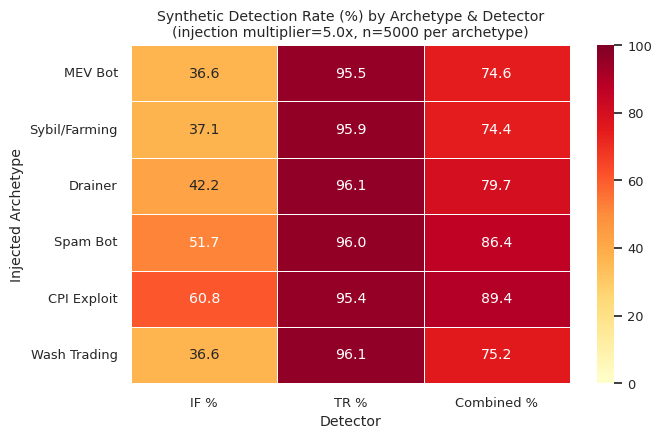

Saved: archetype_detection_rates.png


In [120]:
# ── 4. Contamination: baseline detection on synthetic anomalies ──────────────

rng = np.random.default_rng(42)
feat_idx = {f: i for i, f in enumerate(tx_feature_cols)}

normal_pool = np.where(test_mask_tx & (combined_tx <= np.quantile(combined_tx[test_mask_tx], 0.50)))[0]
if len(normal_pool) == 0:
    normal_pool = np.where(test_mask_tx)[0]

n_syn = int(min(5000, len(normal_pool)))
if n_syn == 0:
    raise RuntimeError('No test transactions available for contamination analysis.')
syn_pick = rng.choice(normal_pool, size=n_syn, replace=False)
X_syn_raw = X_tx[syn_pick].copy()

# Inject synthetic anomalous patterns
for f in ['fee_sol', 'compute_units_consumed', 'fanout_ratio', 'cpi_ratio', 'drain_sol_ratio', 'inner_instructions']:
    if f in feat_idx:
        j = feat_idx[f]
        X_syn_raw[:, j] = X_syn_raw[:, j] * rng.uniform(2.5, 6.0, size=n_syn)

if 'success_flag' in feat_idx:
    X_syn_raw[:, feat_idx['success_flag']] = 0.0

train_std = X_tx[train_mask_tx].std(axis=0) + 1e-6
X_syn_raw += rng.normal(0.0, 1.25 * train_std, size=X_syn_raw.shape)

# Re-score synthetic tx with trained baseline components
if_syn_raw = -iforest.decision_function(X_syn_raw)
# Training-CDF normalisation: reuse sorted training arrays from cells 9/14.
if_syn = np.searchsorted(_if_train_sort, if_syn_raw, side='right') / len(_if_train_sort)

X_syn_norm = scaler.transform(X_syn_raw).astype(np.float32)
tr_syn_raw, _ = score_tx_ae(tr_model, X_syn_norm, device)
tr_syn = np.searchsorted(_tr_train_sort, tr_syn_raw, side='right') / len(_tr_train_sort)

combined_syn = np.maximum(W_IF * if_syn, W_TR * tr_syn)

if_thr = np.quantile(if_tx_score[val_mask_tx], 1 - ALPHA)
tr_thr = np.quantile(tr_tx_score[val_mask_tx], 1 - ALPHA)
comb_thr = np.quantile(combined_tx[val_mask_tx], 1 - ALPHA)

contamination_results = pd.DataFrame([
    {'detector': 'if_only', 'threshold': float(if_thr), 'synthetic_detection_rate_pct': float((if_syn >= if_thr).mean() * 100)},
    {'detector': 'tr_only', 'threshold': float(tr_thr), 'synthetic_detection_rate_pct': float((tr_syn >= tr_thr).mean() * 100)},
    {'detector': 'baseline_combined', 'threshold': float(comb_thr), 'synthetic_detection_rate_pct': float((combined_syn >= comb_thr).mean() * 100)},
])

print('Synthetic contamination detection rates:')
print(contamination_results.to_string(index=False))

# ── Per-archetype detection rates ────────────────────────────────────────────
# For each Solana archetype, inject that archetype's characteristic feature
# pattern into the normal transaction pool and measure IF / TR / combined
# detection rates. Shows which detector catches which threat type best,
# validating the hybrid ensemble design.

_ARCHETYPE_TEMPLATES = {
    'MEV Bot':       {'fee_sol': 1.0, 'has_compute_budget': 1.0, 'compute_units_consumed': 1.0, 'fanout_ratio': 0.7},
    'Sybil/Farming': {'fanout_ratio': 1.0, 'unique_destinations': 1.0, 'num_token_transfers': 0.8, 'unique_mints': 0.6},
    'Drainer':       {'token_accounts_closed': 1.0, 'drain_sol_ratio': 1.0, 'wallet_sol_delta': 0.8,
                      'max_balance_change': 0.6, 'num_post_token_balances': 0.5},
    'Spam Bot':      {'num_instructions': 1.0, 'num_writable': 0.8, 'has_compute_budget': 0.6},
    'CPI Exploit':   {'cpi_ratio': 1.0, 'inner_instructions': 1.0, 'unique_programs': 0.8,
                      'unique_instruction_types': 0.7, 'token_program_calls': 0.5},
    'Wash Trading':  {'num_token_transfers': 1.0, 'unique_destinations': 0.8,
                      'wallet_sol_delta': 0.3, 'unique_mints': 0.4, 'fanout_ratio': 0.2},
}

INJECT_MULTIPLIER = 5.0   # amplification factor applied per unit template weight

_arch_rows = []
for _arch, _weights in _ARCHETYPE_TEMPLATES.items():
    X_arch = X_tx[syn_pick].copy()
    for _feat, _w in _weights.items():
        if _feat in feat_idx:
            X_arch[:, feat_idx[_feat]] *= (1.0 + _w * INJECT_MULTIPLIER)
    # Light noise so injection doesn't produce perfectly identical vectors
    X_arch += rng.normal(0.0, 0.5 * train_std, size=X_arch.shape)

    _if_raw  = -iforest.decision_function(X_arch)
    _if_sc   = np.searchsorted(_if_train_sort, _if_raw,  side='right') / len(_if_train_sort)

    _X_norm  = scaler.transform(X_arch).astype(np.float32)
    _tr_raw, _ = score_tx_ae(tr_model, _X_norm, device)
    _tr_sc   = np.searchsorted(_tr_train_sort, _tr_raw,  side='right') / len(_tr_train_sort)

    _comb    = np.maximum(W_IF * _if_sc, W_TR * _tr_sc)

    _arch_rows.append({
        'archetype':       _arch,
        'IF %':            round(float((_if_sc  >= if_thr  ).mean() * 100), 1),
        'TR %':            round(float((_tr_sc  >= tr_thr  ).mean() * 100), 1),
        'Combined %':      round(float((_comb   >= comb_thr).mean() * 100), 1),
        'TR_gain_vs_IF':   round(float((_comb   >= comb_thr).mean() * 100) -
                                 float((_if_sc  >= if_thr  ).mean() * 100), 1),
    })

archetype_detection_df = pd.DataFrame(_arch_rows)
print('\nPer-archetype synthetic detection rates:')
print(archetype_detection_df.to_string(index=False))

# Heatmap: archetype × detector
import seaborn as sns
import matplotlib.pyplot as plt

_heat = archetype_detection_df.set_index('archetype')[['IF %', 'TR %', 'Combined %']]
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(_heat, annot=True, fmt='.1f', cmap='YlOrRd', vmin=0, vmax=100,
            linewidths=0.5, ax=ax)
ax.set_title(f'Synthetic Detection Rate (%) by Archetype & Detector\n'
             f'(injection multiplier={INJECT_MULTIPLIER}x, n={n_syn} per archetype)')
ax.set_xlabel('Detector')
ax.set_ylabel('Injected Archetype')
plt.tight_layout()
plt.savefig('archetype_detection_rates.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: archetype_detection_rates.png')


Alpha selection — operational cost curve:
 alpha  conf_threshold  real_flag_pct  mean_detection_pct
 0.001        0.996182           0.13                 5.1
 0.005        0.990885           0.71                22.8
 0.010        0.990023           1.56                25.5
 0.020        0.987980           3.18                31.5
 0.050        0.977548           7.42                51.2
 0.100        0.963692          13.81                67.7
 0.150        0.956747          20.37                72.6
 0.200        0.953417          26.36                75.2

Elbow point: alpha=0.1 (threshold=0.9637, flag_rate=13.81%, mean_detection=67.7%)
Current ALPHA=0.05 is more conservative than the elbow.


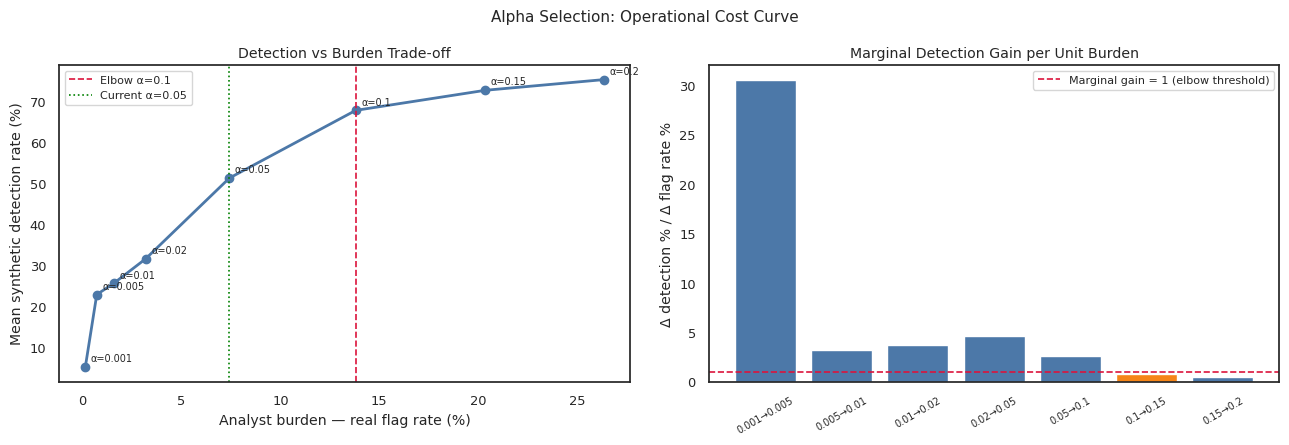

Saved: alpha_selection.png


In [121]:
# ── Alpha selection: operational cost curve ───────────────────────────────────
# ALPHA=0.01 is a conventional default (FPR ≤ 1%) but not data-derived.
# Here we make the choice principled by plotting the trade-off between:
#   - analyst burden  : real_flag_pct (rises with alpha)
#   - detection power : mean synthetic detection rate across archetypes (rises with alpha)
# The elbow of the detection-vs-burden curve is the natural operating point.
# If an ops capacity constraint exists (max wallets/day), alpha is chosen to
# satisfy that constraint directly — shown as a horizontal budget line.

_sweep = alpha_sweep_df.copy()
_arch_cols = list(_ARCHETYPE_TEMPLATES.keys())
_sweep['mean_detection_pct'] = _sweep[_arch_cols].mean(axis=1)

# Extended sweep for a smoother curve
_ALPHA_FINE = [0.001, 0.005, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20]
_fine_rows = []
for _a in _ALPHA_FINE:
    _thr = float(np.quantile(cal_scores, 1 - _a))
    _real_rate = float((test_scores >= _thr).mean() * 100)
    _det_rates = [
        float((_arch_comb_scores[_arch] >= _thr).mean() * 100)
        for _arch in _arch_cols
    ]
    _fine_rows.append({
        'alpha':              _a,
        'conf_threshold':     round(_thr, 6),
        'real_flag_pct':      round(_real_rate, 2),
        'mean_detection_pct': round(float(np.mean(_det_rates)), 1),
    })
_fine_df = pd.DataFrame(_fine_rows)

# Elbow detection: maximise detection gain per unit flag-rate increase
_det   = _fine_df['mean_detection_pct'].values
_burden = _fine_df['real_flag_pct'].values
# Marginal gain: delta_detection / delta_burden (skip first point)
_marginal = np.diff(_det) / (np.diff(_burden) + 1e-8)
_elbow_idx = int(np.argmax(_marginal < 1.0))   # first point where gain < 1% detection per 1% burden
_elbow_alpha = float(_fine_df.iloc[_elbow_idx]['alpha'])
_elbow_thr   = float(_fine_df.iloc[_elbow_idx]['conf_threshold'])

print(f'\nAlpha selection — operational cost curve:')
print(_fine_df[['alpha', 'conf_threshold', 'real_flag_pct', 'mean_detection_pct']].to_string(index=False))
print(f'\nElbow point: alpha={_elbow_alpha} '
      f'(threshold={_elbow_thr:.4f}, '
      f'flag_rate={_fine_df.iloc[_elbow_idx]["real_flag_pct"]:.2f}%, '
      f'mean_detection={_fine_df.iloc[_elbow_idx]["mean_detection_pct"]:.1f}%)')
print(f'Current ALPHA={ALPHA} is {"at" if ALPHA == _elbow_alpha else "more conservative than"} the elbow.')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: detection vs burden scatter with elbow marked
axes[0].plot(_fine_df['real_flag_pct'], _fine_df['mean_detection_pct'],
             'o-', color='#4C78A8', linewidth=2)
for _, _r in _fine_df.iterrows():
    axes[0].annotate(f"α={_r['alpha']}", (_r['real_flag_pct'], _r['mean_detection_pct']),
                     textcoords='offset points', xytext=(4, 4), fontsize=7)
axes[0].axvline(_fine_df.iloc[_elbow_idx]['real_flag_pct'],
                linestyle='--', color='crimson', linewidth=1.2, label=f'Elbow α={_elbow_alpha}')
axes[0].axvline(_fine_df[_fine_df['alpha'] == ALPHA]['real_flag_pct'].values[0],
                linestyle=':', color='green', linewidth=1.2, label=f'Current α={ALPHA}')
axes[0].set_xlabel('Analyst burden — real flag rate (%)')
axes[0].set_ylabel('Mean synthetic detection rate (%)')
axes[0].set_title('Detection vs Burden Trade-off')
axes[0].legend(fontsize=8)

# Right: marginal gain curve
axes[1].bar(range(len(_marginal)),
            np.clip(_marginal, 0, None),
            color=['#F58518' if i == _elbow_idx else '#4C78A8' for i in range(len(_marginal))])
axes[1].axhline(1.0, linestyle='--', color='crimson', linewidth=1.2,
                label='Marginal gain = 1 (elbow threshold)')
axes[1].set_xticks(range(len(_marginal)))
axes[1].set_xticklabels([f'{_fine_df["alpha"].iloc[i]}→{_fine_df["alpha"].iloc[i+1]}'
                          for i in range(len(_marginal))], rotation=30, fontsize=7)
axes[1].set_ylabel('Δ detection % / Δ flag rate %')
axes[1].set_title('Marginal Detection Gain per Unit Burden')
axes[1].legend(fontsize=8)

plt.suptitle('Alpha Selection: Operational Cost Curve', fontsize=11)
plt.tight_layout()
plt.savefig('alpha_selection.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Saved: alpha_selection.png')

In [122]:
# ── 5. Interpretability: what baseline flagged and why ───────────────────────

tx_top_idx = df_flat.groupby('wallet')['combined_tx_score'].idxmax()
tx_top_map = tx_top_idx.to_dict()

flagged_wallets = wallet_scores[
    wallet_scores['wallet'].isin(test_wallets)
    & (wallet_scores['conformal_flag'].fillna(0).astype(int) == 1)
].copy()

if len(flagged_wallets) == 0:
    print('No flagged test wallets at current alpha.')
else:
    explain_rows = []
    for _, row in flagged_wallets.sort_values('raw_score', ascending=False).head(25).iterrows():
        w = row['wallet']
        tx_idx = tx_top_map.get(w)
        if tx_idx is None:
            continue

        feat_err = per_feat_errors[int(tx_idx)]
        topk = np.argsort(feat_err)[-5:][::-1]
        top_feats = [f"{tx_feature_cols[i]}={feat_err[i]:.4f}" for i in topk]

        dominant = 'if' if row['if_score'] >= row['tr_score'] else 'tr'

        explain_rows.append({
            'wallet': w,
            'raw_score': float(row['raw_score']),
            'if_score': float(row['if_score']),
            'tr_score': float(row['tr_score']),
            'conformal_p': float(row['conformal_p']) if pd.notna(row['conformal_p']) else np.nan,
            'semantic_anomaly_type': row.get('semantic_anomaly_type', 'unknown'),
            'dominant_component': dominant,
            'top_feature_contributors': '; '.join(top_feats),
        })

    interpretability_results = pd.DataFrame(explain_rows)
    print('Flagged-wallet explanations:')
    print(interpretability_results.to_string(index=False))

Flagged-wallet explanations:
                                      wallet  raw_score  if_score  tr_score  conformal_p semantic_anomaly_type dominant_component                                                                                                               top_feature_contributors
5qhFTDU5YX7D2kymawuvMK3rBCH4qjryQLcEhP4fR3xA   0.999978  0.999967  0.999990     0.000039              Spam Bot                 tr   wallet_sol_delta=23.1595; compute_units_consumed=0.1676; max_token_value=0.1478; total_token_value=0.1445; avg_token_transfer=0.1391
5yRjKZSBTAxemkh8Jtjp4M7fbYxLGBpwjAKgg35KLx36   0.999518  0.999047  0.999990     0.000078              Spam Bot                 tr   wallet_sol_delta=25.3914; compute_units_consumed=0.1668; max_token_value=0.1481; total_token_value=0.1441; avg_token_transfer=0.1398
2MEW6xNgiPZQ7BTdAJvpzH19SZCvrGzmrXiY6URzAWzv   0.999490  0.998990  0.999990     0.000078           CPI Exploit                 tr   wallet_sol_delta=21.9639; compute_units_cons

SHAP mode: tree
Top IF feature drivers by mean |SHAP|:
                feature  mean_abs_shap
     max_balance_change       0.516269
       num_instructions       0.459778
        unique_programs       0.431912
    num_token_transfers       0.431831
    unique_destinations       0.431484
         unique_sources       0.429222
                fee_sol       0.361992
num_post_token_balances       0.356185
           num_writable       0.355438
    token_program_calls       0.355347
 num_pre_token_balances       0.347528
           net_sol_flow       0.345754
     inner_instructions       0.336748
             delta_time       0.313033
              cpi_ratio       0.293998


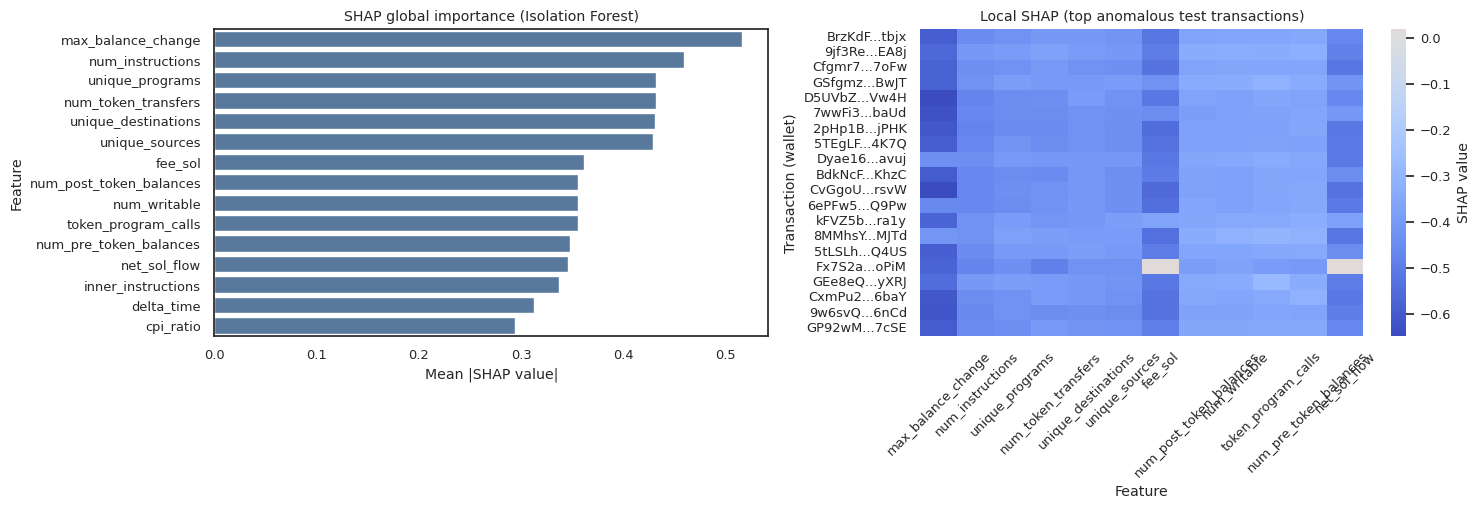

Saved SHAP outputs: `shap_global_df`, `shap_local_top_df` (and dashboard keys if available).


In [123]:
# ── SHAP interpretability (Isolation Forest component) ────────────────────────
# Addresses the black-box concern by explaining which features drive IF anomaly
# scores for top anomalous test transactions.

shap_global_df = pd.DataFrame()
shap_local_top_df = pd.DataFrame()

try:
    import shap
except Exception:
    print('SHAP is not installed in this environment. Run `pip install shap` and re-run this cell.')
else:
    required_vars = ['iforest', 'if_tx_score', 'X_tx_norm', 'test_mask_tx', 'tx_feature_cols', 'df_flat']
    missing_vars = [v for v in required_vars if v not in globals()]
    if missing_vars:
        raise RuntimeError(f'Missing prerequisites for SHAP: {missing_vars}')

    bg_n = int(min(2000, np.sum(train_mask_tx))) if 'train_mask_tx' in globals() else int(min(2000, len(X_tx_norm)))
    ex_n = int(min(300, np.sum(test_mask_tx)))
    if ex_n <= 0:
        raise RuntimeError('No test transactions available for SHAP interpretation.')

    rng_shap = np.random.default_rng(42)
    if 'train_mask_tx' in globals() and np.sum(train_mask_tx) > 0:
        train_idx = np.where(train_mask_tx)[0]
    else:
        train_idx = np.arange(len(X_tx_norm))

    bg_idx = rng_shap.choice(train_idx, size=bg_n, replace=False) if len(train_idx) > bg_n else train_idx

    test_idx = np.where(test_mask_tx)[0]
    top_order = np.argsort(if_tx_score[test_mask_tx])[-ex_n:][::-1]
    explain_idx = test_idx[top_order]

    X_bg = X_tx_norm[bg_idx].astype(np.float32)
    X_ex = X_tx_norm[explain_idx].astype(np.float32)

    shap_values = None
    shap_mode = 'tree'

    try:
        explainer = shap.TreeExplainer(iforest)
        shap_values = explainer.shap_values(X_ex)
        if isinstance(shap_values, list):
            shap_values = shap_values[0]
        shap_values = np.asarray(shap_values, dtype=float)
    except Exception:
        shap_mode = 'model_agnostic'

        def _if_anom(x):
            x = np.asarray(x, dtype=np.float32)
            return -iforest.decision_function(x)

        explainer = shap.Explainer(_if_anom, X_bg, feature_names=tx_feature_cols)
        shap_out = explainer(X_ex)
        shap_values = np.asarray(shap_out.values, dtype=float)

    if shap_values.ndim != 2 or shap_values.shape[1] != len(tx_feature_cols):
        raise RuntimeError(f'Unexpected SHAP output shape: {shap_values.shape}')

    # Global IF feature importance
    mean_abs = np.mean(np.abs(shap_values), axis=0)
    shap_global_df = (
        pd.DataFrame({'feature': tx_feature_cols, 'mean_abs_shap': mean_abs})
        .sort_values('mean_abs_shap', ascending=False)
        .reset_index(drop=True)
    )

    print(f'SHAP mode: {shap_mode}')
    print('Top IF feature drivers by mean |SHAP|:')
    print(shap_global_df.head(15).to_string(index=False))

    # Local explanations for top anomalous transactions
    top_feat = shap_global_df.head(12)['feature'].tolist()
    top_feat_idx = [tx_feature_cols.index(f) for f in top_feat]

    shap_local_top_df = pd.DataFrame(
        shap_values[:, top_feat_idx],
        columns=top_feat,
    )
    shap_local_top_df['tx_idx'] = explain_idx
    shap_local_top_df['wallet'] = df_flat.iloc[explain_idx]['wallet'].astype(str).values
    shap_local_top_df['if_score'] = if_tx_score[explain_idx]

    # Seaborn visualisations
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

    sns.barplot(data=shap_global_df.head(15), x='mean_abs_shap', y='feature', color='#4C78A8', ax=axes[0])
    axes[0].set_title('SHAP global importance (Isolation Forest)')
    axes[0].set_xlabel('Mean |SHAP value|')
    axes[0].set_ylabel('Feature')

    hm_n = int(min(20, len(shap_local_top_df)))
    hm = shap_local_top_df[top_feat].head(hm_n).to_numpy(dtype=float)
    row_labels = []
    for w in shap_local_top_df['wallet'].head(hm_n):
        ws = str(w)
        row_labels.append(ws if len(ws) <= 14 else f'{ws[:6]}...{ws[-4:]}')

    sns.heatmap(
        hm,
        cmap='coolwarm',
        center=0.0,
        xticklabels=top_feat,
        yticklabels=row_labels,
        cbar_kws={'label': 'SHAP value'},
        ax=axes[1],
    )
    axes[1].set_title('Local SHAP (top anomalous test transactions)')
    axes[1].set_xlabel('Feature')
    axes[1].set_ylabel('Transaction (wallet)')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    if 'no_label_dashboard' in globals():
        no_label_dashboard['if_shap_global'] = shap_global_df
        no_label_dashboard['if_shap_local_top'] = shap_local_top_df

print('Saved SHAP outputs: `shap_global_df`, `shap_local_top_df` (and dashboard keys if available).')

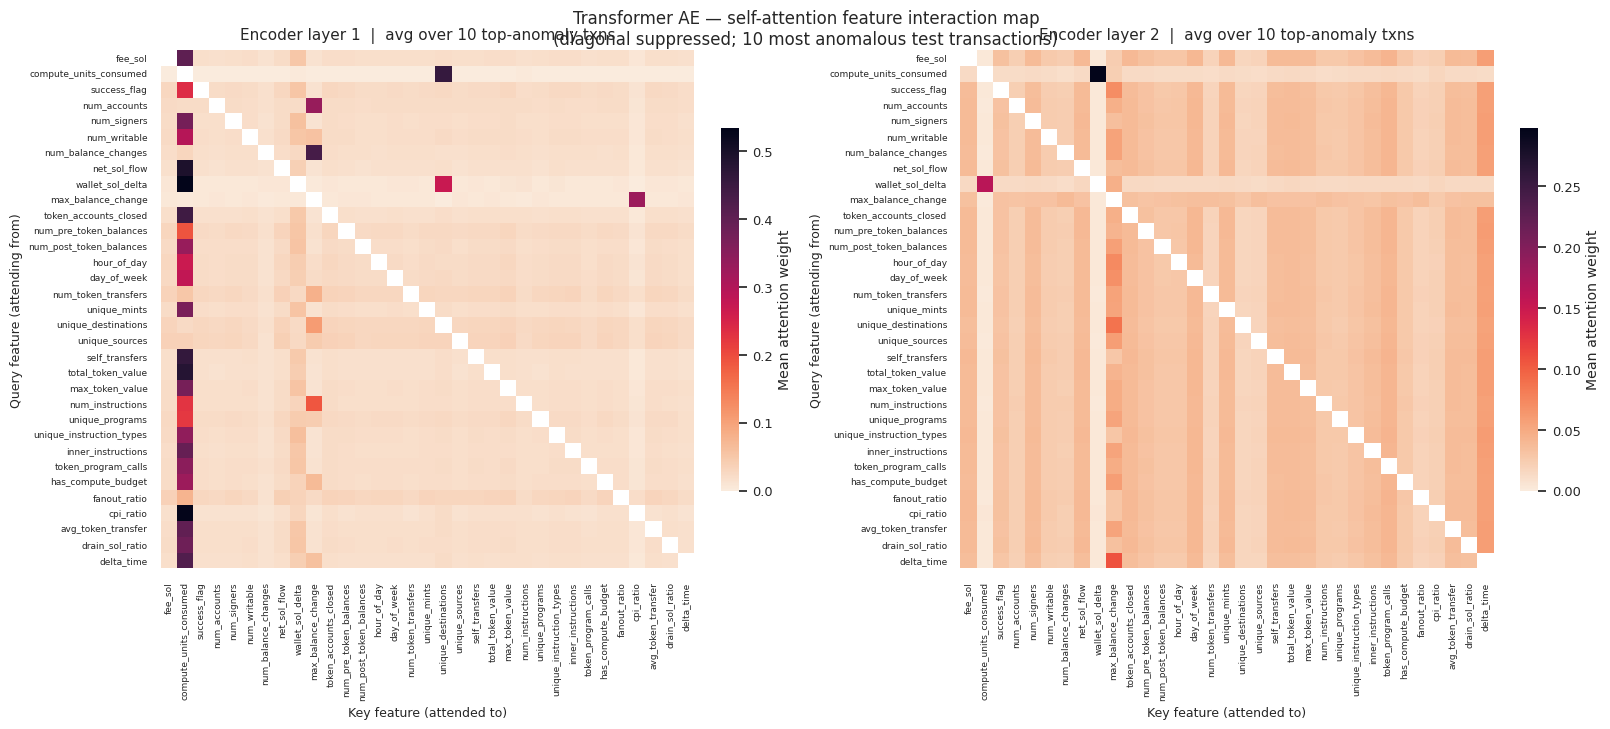

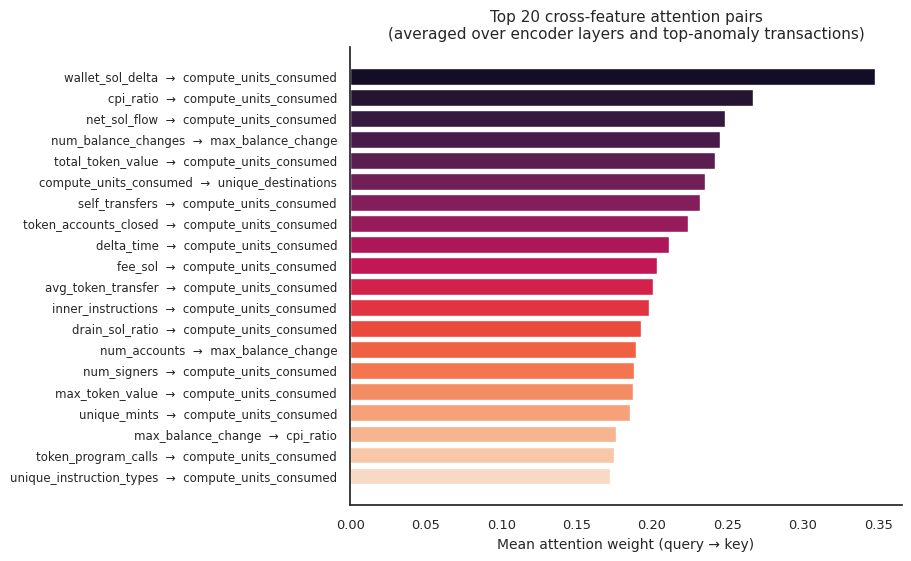


Top 20 attended feature pairs:
           query_feature            key_feature  mean_attention
        wallet_sol_delta compute_units_consumed        0.348064
               cpi_ratio compute_units_consumed        0.267225
            net_sol_flow compute_units_consumed        0.248255
     num_balance_changes     max_balance_change        0.245093
       total_token_value compute_units_consumed        0.241660
  compute_units_consumed    unique_destinations        0.235028
          self_transfers compute_units_consumed        0.231739
   token_accounts_closed compute_units_consumed        0.224129
              delta_time compute_units_consumed        0.211049
                 fee_sol compute_units_consumed        0.203292
      avg_token_transfer compute_units_consumed        0.200475
      inner_instructions compute_units_consumed        0.197719
         drain_sol_ratio compute_units_consumed        0.192472
            num_accounts     max_balance_change        0.189658
        

In [124]:
# ── Transformer AE attention weights (interpretability) ──────────────────────
# Complements per_feat_errors (what failed to reconstruct) by showing
# *which feature–feature interactions* the encoder was attending to.
#
# Method: call each TransformerEncoderLayer's self_attn directly with
# need_weights=True for the top-N anomalous test transactions, then average
# over heads and transactions.  Result: one F×F heatmap per encoder layer
# showing mean attention from token i → token j.
#
# A second panel ranks the strongest off-diagonal feature pairs, giving a
# readable summary of which cross-feature dependencies drove the anomaly.

_REQUIRED_ATTN = ['tr_model', 'X_tx_norm', 'test_mask_tx',
                  'tx_feature_cols', 'tr_tx_score', 'device']
_miss_attn = [v for v in _REQUIRED_ATTN if v not in globals()]
if _miss_attn:
    raise RuntimeError(f'Missing prerequisites for attention viz: {_miss_attn}')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

N_TOP_ATTN = 10   # top anomalous test transactions to average over

test_idx_attn = np.where(test_mask_tx)[0]
top_order_attn = np.argsort(tr_tx_score[test_mask_tx])[-N_TOP_ATTN:][::-1]
explain_idx_attn = test_idx_attn[top_order_attn]

feat_names = list(tx_feature_cols)
F_dim = len(feat_names)

X_top_attn = torch.from_numpy(X_tx_norm[explain_idx_attn]).to(device)  # (N_TOP, F)

tr_model.eval()
layer_attns = []   # list of np arrays (N_TOP, F, F) — averaged over heads per layer

with torch.no_grad():
    pos = torch.arange(F_dim, device=device)
    h   = tr_model.feat_proj(X_top_attn.unsqueeze(-1)) + tr_model.pos_embed(pos).unsqueeze(0)
    # h: (N_TOP, F, d_model)

    for layer in tr_model.encoder.layers:
        # Extract attention weights with need_weights=True.
        # average_attn_weights=False → (B, nhead, F, F); added in PyTorch 1.11.
        # Fallback: older PyTorch returns (B, F, F) already averaged.
        try:
            _, attn_w = layer.self_attn(
                h, h, h, need_weights=True, average_attn_weights=False
            )
            # attn_w: (B, nhead, F, F)
            if attn_w is not None:
                avg_heads = attn_w.mean(dim=1).cpu().numpy()   # (B, F, F)
            else:
                avg_heads = None
        except TypeError:
            _, attn_w = layer.self_attn(h, h, h, need_weights=True)
            # attn_w: (B, F, F)
            avg_heads = attn_w.cpu().numpy() if attn_w is not None else None

        if avg_heads is not None:
            layer_attns.append(avg_heads.mean(axis=0))   # (F, F) mean over top-N txns

        h = layer(h)   # continue forward pass normally

if not layer_attns:
    print('Attention weights unavailable (need_weights returned None). '
          'Check PyTorch version ≥ 1.9.')
else:
    n_layers = len(layer_attns)
    sns.set_theme(style='white', font_scale=0.85)
    pal = sns.color_palette('rocket_r', as_cmap=True)

    # ── Figure 1: per-layer F×F heatmap ──────────────────────────────────────
    fig1, axes1 = plt.subplots(1, n_layers, figsize=(8 * n_layers, 7),
                               constrained_layout=True)
    if n_layers == 1:
        axes1 = [axes1]

    for li, (ax, attn_map) in enumerate(zip(axes1, layer_attns)):
        mask = np.eye(F_dim, dtype=bool)   # suppress diagonal (self-attention)
        sns.heatmap(
            attn_map,
            ax=ax,
            cmap=pal,
            mask=mask,
            xticklabels=feat_names,
            yticklabels=feat_names,
            linewidths=0,
            vmin=0,
            cbar_kws={'label': 'Mean attention weight', 'shrink': 0.7},
        )
        ax.set_title(
            f'Encoder layer {li + 1}  |  avg over {N_TOP_ATTN} top-anomaly txns',
            fontsize=11, pad=8
        )
        ax.tick_params(axis='x', rotation=90, labelsize=6.5)
        ax.tick_params(axis='y', rotation=0,  labelsize=6.5)
        ax.set_xlabel('Key feature (attended to)', fontsize=9)
        ax.set_ylabel('Query feature (attending from)', fontsize=9)

    fig1.suptitle(
        'Transformer AE — self-attention feature interaction map\n'
        f'(diagonal suppressed; {N_TOP_ATTN} most anomalous test transactions)',
        fontsize=12, y=1.02
    )
    plt.show()

    # ── Figure 2: top off-diagonal feature pairs ──────────────────────────────
    # Average attention across all layers, then rank off-diagonal pairs.
    mean_attn = np.mean(layer_attns, axis=0)          # (F, F)
    np.fill_diagonal(mean_attn, 0.0)

    N_PAIRS = 20
    flat_idx = np.argsort(mean_attn, axis=None)[-N_PAIRS:][::-1]
    rows_i, cols_j = np.unravel_index(flat_idx, mean_attn.shape)

    pair_df = pd.DataFrame({
        'query_feature':  [feat_names[i] for i in rows_i],
        'key_feature':    [feat_names[j] for j in cols_j],
        'mean_attention': mean_attn[rows_i, cols_j],
    })

    fig2, ax2 = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
    bar_labels = [f"{r}  →  {k}" for r, k in zip(pair_df['query_feature'], pair_df['key_feature'])]
    colors = sns.color_palette('rocket_r', N_PAIRS)[::-1]
    ax2.barh(range(N_PAIRS), pair_df['mean_attention'].values[::-1], color=colors[::-1])
    ax2.set_yticks(range(N_PAIRS))
    ax2.set_yticklabels(bar_labels[::-1], fontsize=8.5)
    ax2.set_xlabel('Mean attention weight (query → key)', fontsize=10)
    ax2.set_title(
        f'Top {N_PAIRS} cross-feature attention pairs\n'
        '(averaged over encoder layers and top-anomaly transactions)',
        fontsize=11
    )
    ax2.spines[['top', 'right']].set_visible(False)
    plt.show()

    print(f'\nTop {N_PAIRS} attended feature pairs:')
    print(pair_df.to_string(index=False))
    print(
        '\nInterpretation: high attention weight from query Q → key K means the encoder'
        '\nconsiders feature K context when reconstructing Q.  Pairs that consistently'
        '\nappear in top-anomaly transactions but not in normal traffic indicate the'
        '\ncross-feature patterns most associated with anomalous behaviour.'
    )


In [125]:
# ── 6. No-label evaluation dashboard ──────────────────────────────────────────
from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.metrics import roc_auc_score, average_precision_score


def _clean(x):
    x = np.asarray(x, dtype=float)
    return x[np.isfinite(x)]


def _score_summary(name, values):
    x = _clean(values)
    if len(x) == 0:
        return {
            'detector': name,
            'n': 0,
            'mean': np.nan,
            'std': np.nan,
            'p50': np.nan,
            'p90': np.nan,
            'p95': np.nan,
            'p99': np.nan,
            'max': np.nan,
        }
    return {
        'detector': name,
        'n': int(len(x)),
        'mean': float(np.mean(x)),
        'std': float(np.std(x)),
        'p50': float(np.quantile(x, 0.50)),
        'p90': float(np.quantile(x, 0.90)),
        'p95': float(np.quantile(x, 0.95)),
        'p99': float(np.quantile(x, 0.99)),
        'max': float(np.max(x)),
    }


def _psi(expected, actual, bins=10, eps=1e-6):
    exp = _clean(expected)
    act = _clean(actual)
    if len(exp) == 0 or len(act) == 0:
        return np.nan

    edges = np.quantile(exp, np.linspace(0, 1, bins + 1))
    edges = np.unique(edges)
    if len(edges) < 3:
        return 0.0

    exp_hist, _ = np.histogram(exp, bins=edges)
    act_hist, _ = np.histogram(act, bins=edges)

    exp_pct = np.clip(exp_hist / max(exp_hist.sum(), 1), eps, None)
    act_pct = np.clip(act_hist / max(act_hist.sum(), 1), eps, None)
    return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))


def _topk_jaccard(a, b, k):
    a = _clean(a)
    b = _clean(b)
    k = int(min(k, len(a), len(b)))
    if k <= 0:
        return np.nan

    set_a = set(np.argsort(a)[-k:])
    set_b = set(np.argsort(b)[-k:])
    inter = len(set_a & set_b)
    union = len(set_a | set_b)
    return float(inter / union) if union else 1.0


def _conformal_rate(cal_scores, test_scores, alpha):
    cal = _clean(cal_scores)
    tst = _clean(test_scores)
    if len(cal) == 0 or len(tst) == 0:
        return np.nan, np.nan

    thr = float(np.quantile(cal, 1 - alpha))
    pvals = np.array([(np.sum(cal >= s) + 1) / (len(cal) + 1) for s in tst])
    rate = float((pvals <= alpha).mean())
    return thr, rate


def _drift_row(name, ref, cur):
    ref = _clean(ref)
    cur = _clean(cur)
    if len(ref) == 0 or len(cur) == 0:
        return {
            'score': name,
            'ks_stat': np.nan,
            'ks_pvalue': np.nan,
            'wasserstein': np.nan,
            'psi_10bins': np.nan,
        }

    ks_stat, ks_p = ks_2samp(ref, cur)
    return {
        'score': name,
        'ks_stat': float(ks_stat),
        'ks_pvalue': float(ks_p),
        'wasserstein': float(wasserstein_distance(ref, cur)),
        'psi_10bins': float(_psi(ref, cur, bins=10)),
    }


required = {'wallet', 'if_score', 'tr_score', 'raw_score'}
missing = sorted(required - set(wallet_scores.columns))
if missing:
    raise ValueError(f'Missing required wallet score columns: {missing}')

# Evaluation masks (prefer true temporal test/val wallet split if available)
if 'test_wallets' in globals():
    test_mask_eval = wallet_scores['wallet'].isin(test_wallets).values
else:
    test_mask_eval = np.ones(len(wallet_scores), dtype=bool)

if 'val_wallets' in globals():
    val_mask_eval = wallet_scores['wallet'].isin(val_wallets).values
else:
    val_mask_eval = ~test_mask_eval

if val_mask_eval.sum() == 0:
    val_mask_eval = test_mask_eval.copy()

# Core vectors
if_test = wallet_scores.loc[test_mask_eval, 'if_score'].to_numpy(dtype=float)
tr_test = wallet_scores.loc[test_mask_eval, 'tr_score'].to_numpy(dtype=float)
raw_test = wallet_scores.loc[test_mask_eval, 'raw_score'].to_numpy(dtype=float)

if_val = wallet_scores.loc[val_mask_eval, 'if_score'].to_numpy(dtype=float)
tr_val = wallet_scores.loc[val_mask_eval, 'tr_score'].to_numpy(dtype=float)
raw_val = wallet_scores.loc[val_mask_eval, 'raw_score'].to_numpy(dtype=float)

if 'conformal_flag' in wallet_scores.columns:
    flags_test = wallet_scores.loc[test_mask_eval, 'conformal_flag'].fillna(0).astype(int).to_numpy()
else:
    flags_test = np.zeros(test_mask_eval.sum(), dtype=int)

if 'conformal_p' in wallet_scores.columns:
    pvals_test = wallet_scores.loc[test_mask_eval, 'conformal_p'].to_numpy(dtype=float)
else:
    pvals_test = np.array([], dtype=float)

# 1) Workload / alert-rate view
n_test = int(test_mask_eval.sum())
n_flagged = int(flags_test.sum())
flag_rate = float(n_flagged / max(n_test, 1))

no_label_overview = pd.DataFrame([{
    'n_test_wallets': n_test,
    'n_flagged_wallets': n_flagged,
    'flag_rate_pct': flag_rate * 100,
    'median_risk_score': float(wallet_scores.loc[test_mask_eval, 'risk_score'].median()) if 'risk_score' in wallet_scores.columns else np.nan,
    'p95_risk_score': float(wallet_scores.loc[test_mask_eval, 'risk_score'].quantile(0.95)) if 'risk_score' in wallet_scores.columns else np.nan,
    'conformal_p_median': float(np.nanmedian(pvals_test)) if len(pvals_test) else np.nan,
    'conformal_p_p05': float(np.nanquantile(pvals_test, 0.05)) if len(pvals_test) else np.nan,
}])

print('No-label overview:')
print(no_label_overview.to_string(index=False))

# Time-based analyst workload (daily alerts from top-scored tx per wallet)
alerts_over_time = pd.DataFrame()
if {'wallet', 'block_timestamp', 'combined_tx_score'}.issubset(df_flat.columns):
    top_tx_idx = df_flat.groupby('wallet')['combined_tx_score'].idxmax()
    ts_map = (
        df_flat.loc[top_tx_idx, ['wallet', 'block_timestamp']]
        .drop_duplicates('wallet')
        .set_index('wallet')['block_timestamp']
    )
    test_wallet_df = wallet_scores.loc[test_mask_eval, ['wallet']].copy()
    test_wallet_df['flag'] = flags_test
    test_wallet_df['top_tx_ts'] = test_wallet_df['wallet'].map(ts_map)

    flagged_ts = pd.to_datetime(test_wallet_df.loc[test_wallet_df['flag'] == 1, 'top_tx_ts'], errors='coerce')
    flagged_ts = flagged_ts.dropna()
    if len(flagged_ts):
        alerts_over_time = (
            flagged_ts.dt.floor('D').value_counts().sort_index()
            .rename_axis('date').reset_index(name='alerts')
        )
        print('\nAlert workload (daily) preview:')
        print(alerts_over_time.head(10).to_string(index=False))

# 2) Conformal diagnostics: realized flag rate vs target alpha
alpha_grid = [0.005, 0.01, 0.02, 0.05]
conformal_rows = []
for a in alpha_grid:
    thr, realized_rate = _conformal_rate(raw_val, raw_test, a)
    conformal_rows.append({
        'alpha_target': float(a),
        'threshold': thr,
        'realized_flag_rate_pct': float(realized_rate * 100) if np.isfinite(realized_rate) else np.nan,
        'abs_gap_pct_points': float(abs(realized_rate - a) * 100) if np.isfinite(realized_rate) else np.nan,
    })
conformal_diagnostics = pd.DataFrame(conformal_rows)

print('\nConformal diagnostics:')
print(conformal_diagnostics.to_string(index=False))

# 3) Score diagnostics
score_diagnostics = pd.DataFrame([
    _score_summary('if_score_test', if_test),
    _score_summary('tr_score_test', tr_test),
    _score_summary('raw_score_test', raw_test),
    _score_summary('if_score_val', if_val),
    _score_summary('tr_score_val', tr_val),
    _score_summary('raw_score_val', raw_val),
])

print('\nScore diagnostics:')
print(score_diagnostics.to_string(index=False))

# 4) Model-aligned error metrics table
model_score_map = {
    'baseline': wallet_scores['raw_score'].to_numpy(dtype=float),
    'if_only': wallet_scores['if_score'].to_numpy(dtype=float),
    'tr_only': wallet_scores['tr_score'].to_numpy(dtype=float),
}

if '_comp_ws' in globals() and isinstance(_comp_ws, pd.DataFrame):
    _ext_cols = [c for c in ['lof_score', 'ocsvm_score', 'mlp_score'] if c in _comp_ws.columns]
    if len(_ext_cols):
        _ext = (
            _comp_ws[['wallet'] + _ext_cols]
            .drop_duplicates('wallet')
            .set_index('wallet')
            .reindex(wallet_scores['wallet'])
            .fillna(0.0)
        )
        for _c in _ext_cols:
            model_score_map[_c.replace('_score', '')] = _ext[_c].to_numpy(dtype=float)

_base_val_m = _clean(model_score_map['baseline'][val_mask_eval])
_base_test_m = _clean(model_score_map['baseline'][test_mask_eval])
_base_thr_m = float(np.quantile(_base_val_m, 1 - ALPHA)) if len(_base_val_m) else np.nan
_base_flags_m = (_base_test_m >= _base_thr_m).astype(int) if np.isfinite(_base_thr_m) else np.array([], dtype=int)

_syn_rate_map = {}
if 'contamination_results' in globals() and isinstance(contamination_results, pd.DataFrame) and len(contamination_results):
    _det_map = {'baseline_combined': 'baseline', 'if_only': 'if_only', 'tr_only': 'tr_only'}
    for _, _r in contamination_results.iterrows():
        _name = _det_map.get(str(_r.get('detector', '')))
        if _name:
            _syn_rate_map[_name] = float(_r.get('synthetic_detection_rate_pct', np.nan))

_model_rows = []
for _det, _arr in model_score_map.items():
    _val_s = _clean(_arr[val_mask_eval])
    _tst_s = _clean(_arr[test_mask_eval])
    if len(_val_s) == 0 or len(_tst_s) == 0:
        continue

    _thr = float(np.quantile(_val_s, 1 - ALPHA))
    _fl = (_tst_s >= _thr).astype(int)

    _inter = int(np.sum((_fl == 1) & (_base_flags_m == 1))) if len(_base_flags_m) else 0
    _union = int(np.sum((_fl == 1) | (_base_flags_m == 1))) if len(_base_flags_m) else 0
    _jac = float(_inter / _union) if _union > 0 else 1.0

    _rho = spearmanr(_tst_s, _base_test_m).correlation if len(_tst_s) == len(_base_test_m) else np.nan
    _rho = float(0.0 if pd.isna(_rho) else _rho)

    _dr = _drift_row(_det, _val_s, _tst_s)
    _tail = float(np.quantile(_tst_s, 0.99) - np.quantile(_tst_s, 0.50))

    _model_rows.append({
        'detector': _det,
        'val_threshold_alpha': _thr,
        'test_flagged_wallets': int(_fl.sum()),
        'test_flag_rate_pct': float(_fl.mean() * 100),
        'test_tail_contrast': _tail,
        'jaccard_vs_baseline': _jac,
        'rank_corr_vs_baseline': _rho,
        'ks_stat_val_test': _dr['ks_stat'],
        'wasserstein_val_test': _dr['wasserstein'],
        'psi_10bins_val_test': _dr['psi_10bins'],
        'synthetic_detection_rate_pct': float(_syn_rate_map.get(_det, np.nan)),
    })

model_error_metrics = pd.DataFrame(_model_rows)
if len(model_error_metrics):
    _ord = {'baseline': 0, 'if_only': 1, 'tr_only': 2, 'lof': 3, 'ocsvm': 4, 'mlp': 5}
    model_error_metrics['sort_key'] = model_error_metrics['detector'].map(_ord).fillna(99)
    model_error_metrics = model_error_metrics.sort_values(['sort_key', 'detector']).drop(columns=['sort_key']).reset_index(drop=True)

print('\nModel error metrics (aligned to detectors):')
print(model_error_metrics.to_string(index=False) if len(model_error_metrics) else 'No model metrics available.')

# 4b) Logical-perspective comparison (no labels)
logical_perspective_summary = pd.DataFrame()
if len(model_error_metrics):
    logical_perspective_summary = model_error_metrics.copy()

if 'ablation_results' in globals() and isinstance(ablation_results, pd.DataFrame) and len(ablation_results):
    _abl = (
        ablation_results.rename(columns={'run': 'detector'})
        [['detector', 'jaccard_vs_baseline', 'delta_rate_vs_baseline']]
        .rename(columns={
            'jaccard_vs_baseline': 'ablation_jaccard_vs_baseline',
            'delta_rate_vs_baseline': 'ablation_delta_flag_rate_pct',
        })
    )
    logical_perspective_summary = (
        _abl if len(logical_perspective_summary) == 0
        else logical_perspective_summary.merge(_abl, on='detector', how='outer')
    )

if 'perm_df' in globals() and isinstance(perm_df, pd.DataFrame) and len(perm_df):
    _perm = perm_df.copy()
    _perm['detector'] = _perm['comparison'].astype(str).str.replace('baseline vs ', '', regex=False)
    _perm = _perm[['detector', 'observed_jaccard', 'perm_p']].rename(columns={
        'observed_jaccard': 'perm_observed_jaccard',
        'perm_p': 'perm_p_jaccard_overlap',
    })
    logical_perspective_summary = (
        _perm if len(logical_perspective_summary) == 0
        else logical_perspective_summary.merge(_perm, on='detector', how='outer')
    )

if len(logical_perspective_summary):
    _ord = {'baseline': 0, 'if_only': 1, 'tr_only': 2, 'lof': 3, 'ocsvm': 4, 'mlp': 5}
    logical_perspective_summary['sort_key'] = logical_perspective_summary['detector'].map(_ord).fillna(99)
    logical_perspective_summary = (
        logical_perspective_summary
        .sort_values(['sort_key', 'detector'])
        .drop(columns=['sort_key'])
        .reset_index(drop=True)
    )

print('\nLogical perspective summary (ablation + stability + permutation):')
print(logical_perspective_summary.to_string(index=False) if len(logical_perspective_summary) else 'No logical perspective summary available.')

# 5) Detector agreement and top-k overlap
agreement_corr = pd.DataFrame({
    'if_score': if_test,
    'tr_score': tr_test,
    'raw_score': raw_test,
}).corr(method='spearman')

overlap_rows = []
for k in [50, 100, 250]:
    overlap_rows.append({
        'k': int(k),
        'jaccard_if_vs_tr': _topk_jaccard(if_test, tr_test, k),
        'jaccard_if_vs_raw': _topk_jaccard(if_test, raw_test, k),
        'jaccard_tr_vs_raw': _topk_jaccard(tr_test, raw_test, k),
    })
detector_topk_overlap = pd.DataFrame(overlap_rows)

print('\nDetector agreement (Spearman correlation):')
print(agreement_corr.to_string())
print('\nTop-k overlap (Jaccard):')
print(detector_topk_overlap.to_string(index=False))

# 5) Drift diagnostics (val -> test)
drift_results = pd.DataFrame([
    _drift_row('if_score', if_val, if_test),
    _drift_row('tr_score', tr_val, tr_test),
    _drift_row('raw_score', raw_val, raw_test),
])

print('\nDrift diagnostics (val -> test):')
print(drift_results.to_string(index=False))

# 6) Reconstruction feature lift on flagged wallets (no labels)
feature_lift_results = pd.DataFrame()
if 'per_feat_errors' in globals() and isinstance(per_feat_errors, np.ndarray) and len(per_feat_errors) == len(df_flat):
    top_tx_by_wallet = df_flat.groupby('wallet')['combined_tx_score'].idxmax()
    test_wallet_df = wallet_scores.loc[test_mask_eval, ['wallet']].copy()
    test_wallet_df['flag'] = flags_test

    flagged_wallets = test_wallet_df.loc[test_wallet_df['flag'] == 1, 'wallet']
    unflagged_wallets = test_wallet_df.loc[test_wallet_df['flag'] == 0, 'wallet']

    flagged_idx = top_tx_by_wallet.reindex(flagged_wallets).dropna().astype(int).to_numpy()
    unflagged_idx = top_tx_by_wallet.reindex(unflagged_wallets).dropna().astype(int).to_numpy()

    if len(flagged_idx) > 0 and len(unflagged_idx) > 0:
        flagged_mean = per_feat_errors[flagged_idx].mean(axis=0)
        unflagged_mean = per_feat_errors[unflagged_idx].mean(axis=0)
        lift = (flagged_mean + 1e-12) / (unflagged_mean + 1e-12)

        feature_lift_results = pd.DataFrame({
            'feature': tx_feature_cols,
            'flagged_mean_error': flagged_mean,
            'unflagged_mean_error': unflagged_mean,
            'lift_vs_unflagged': lift,
        }).sort_values('lift_vs_unflagged', ascending=False)

        print('\nTop feature lifts (flagged vs unflagged test wallets):')
        print(feature_lift_results.head(12).to_string(index=False))
    else:
        print('\nFeature-lift view skipped: need both flagged and unflagged wallets in test set.')
else:
    print('\nFeature-lift view skipped: per-feature reconstruction errors unavailable.')

# 7) Synthetic proxy separability (if contamination cell already ran)
synthetic_proxy_metrics = pd.DataFrame()
if all(v in globals() for v in ['combined_syn', 'combined_tx', 'test_mask_tx']):
    real_ref = _clean(np.asarray(combined_tx)[np.asarray(test_mask_tx)])
    syn_ref = _clean(np.asarray(combined_syn))

    if len(real_ref) > 0 and len(syn_ref) > 0:
        y = np.concatenate([np.zeros(len(real_ref), dtype=int), np.ones(len(syn_ref), dtype=int)])
        s = np.concatenate([real_ref, syn_ref])

        try:
            roc = float(roc_auc_score(y, s))
            ap = float(average_precision_score(y, s))
        except Exception:
            roc, ap = np.nan, np.nan

        synthetic_proxy_metrics = pd.DataFrame([{
            'n_real_reference': int(len(real_ref)),
            'n_synthetic': int(len(syn_ref)),
            'synthetic_roc_auc_proxy': roc,
            'synthetic_pr_auc_proxy': ap,
        }])

        print('\nSynthetic proxy separability:')
        print(synthetic_proxy_metrics.to_string(index=False))

        if 'contamination_results' in globals():
            print('\nSynthetic threshold detection rates:')
            print(contamination_results.to_string(index=False))

# Bundle outputs for reuse
no_label_dashboard = {
    'overview': no_label_overview,
    'alerts_over_time': alerts_over_time,
    'conformal_diagnostics': conformal_diagnostics,
    'score_diagnostics': score_diagnostics,
    'model_error_metrics': model_error_metrics,
    'logical_perspective_summary': logical_perspective_summary,
    'agreement_corr': agreement_corr,
    'detector_topk_overlap': detector_topk_overlap,
    'drift_results': drift_results,
    'feature_lift_results': feature_lift_results,
    'synthetic_proxy_metrics': synthetic_proxy_metrics,
}

if 'shap_global_df' in globals() and isinstance(shap_global_df, pd.DataFrame) and len(shap_global_df):
    no_label_dashboard['if_shap_global'] = shap_global_df
if 'shap_local_top_df' in globals() and isinstance(shap_local_top_df, pd.DataFrame) and len(shap_local_top_df):
    no_label_dashboard['if_shap_local_top'] = shap_local_top_df

print('\nSaved dashboard tables in `no_label_dashboard`.')

No-label overview:
 n_test_wallets  n_flagged_wallets  flag_rate_pct  median_risk_score  p95_risk_score  conformal_p_median  conformal_p_p05
          25217               1871       7.419598            0.32797        1.480879            0.469926         0.033046

Alert workload (daily) preview:
                     date  alerts
2024-09-03 00:00:00+00:00       1
2024-09-06 00:00:00+00:00       2
2024-09-07 00:00:00+00:00       1
2024-09-10 00:00:00+00:00       1
2024-09-12 00:00:00+00:00       2
2024-09-14 00:00:00+00:00       4
2024-09-15 00:00:00+00:00       1
2024-09-16 00:00:00+00:00       1
2024-09-19 00:00:00+00:00       1
2024-09-20 00:00:00+00:00       1

Conformal diagnostics:
 alpha_target  threshold  realized_flag_rate_pct  abs_gap_pct_points
        0.005   0.990885                0.705873            0.205873
        0.010   0.990023                1.550541            0.550541
        0.020   0.987980                3.160566            1.160566
        0.050   0.977548      

Dashboard snapshot:
 n_test_wallets  n_flagged_wallets  flag_rate_pct  median_risk_score  p95_risk_score  conformal_p_median  conformal_p_p05
          25217               1871       7.419598            0.32797        1.480879            0.469926         0.033046


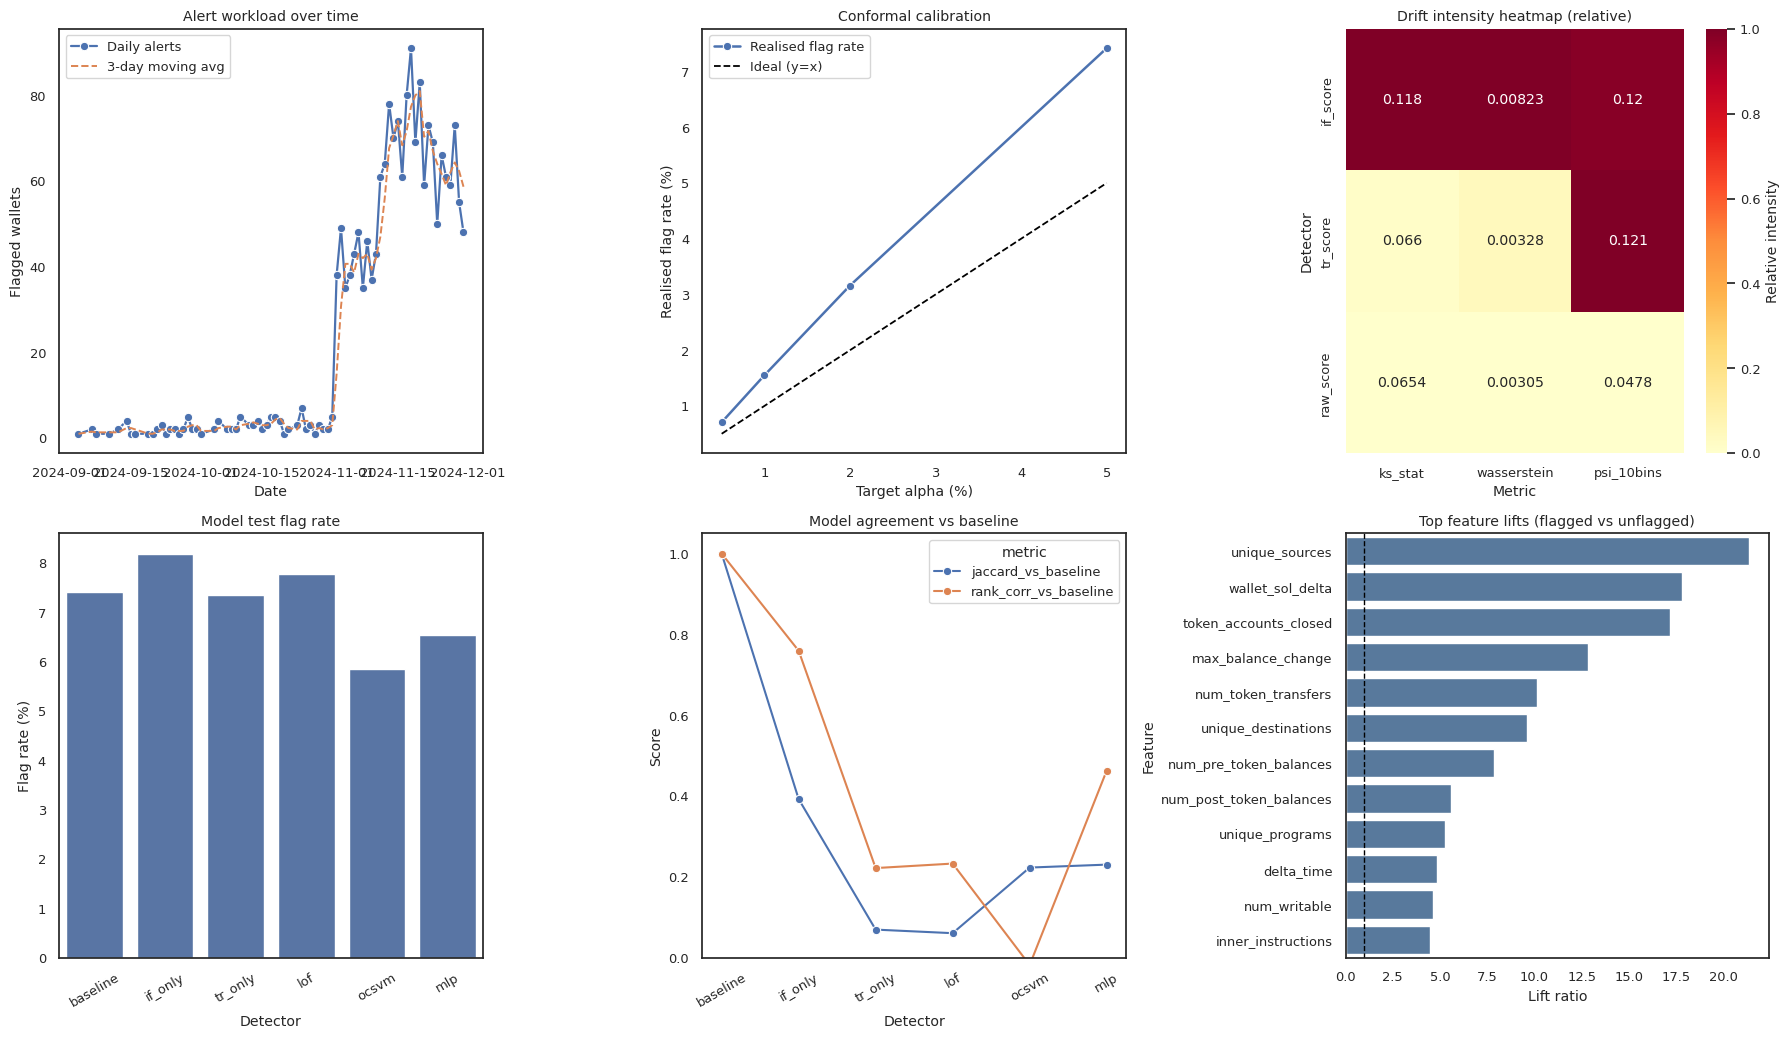

In [126]:
# ── 7. No-label dashboard plots (compact Seaborn renderer) ───────────────────
if 'no_label_dashboard' not in globals():
    raise RuntimeError('Run section 6 (No-label evaluation dashboard) first.')


def render_no_label_dashboard(dashboard, save_path=None, show=True, figsize=(18, 10.5)):
    alerts_over_time = dashboard.get('alerts_over_time', pd.DataFrame())
    conformal_diagnostics = dashboard.get('conformal_diagnostics', pd.DataFrame())
    drift_results = dashboard.get('drift_results', pd.DataFrame())
    feature_lift_results = dashboard.get('feature_lift_results', pd.DataFrame())
    detector_topk_overlap = dashboard.get('detector_topk_overlap', pd.DataFrame())
    model_error_metrics = dashboard.get('model_error_metrics', pd.DataFrame())

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()

    def _blank(ax, title, msg):
        ax.text(0.5, 0.5, msg, ha='center', va='center')
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])

    # 1) Alert trend
    if isinstance(alerts_over_time, pd.DataFrame) and len(alerts_over_time):
        aot = alerts_over_time.copy()
        aot['date'] = pd.to_datetime(aot['date'], errors='coerce')
        aot = aot.dropna(subset=['date'])
        aot['alerts_roll3'] = aot['alerts'].rolling(3, min_periods=1).mean()

        sns.lineplot(data=aot, x='date', y='alerts', marker='o', linewidth=1.6, label='Daily alerts', ax=ax1)
        sns.lineplot(data=aot, x='date', y='alerts_roll3', linewidth=1.4, linestyle='--', label='3-day moving avg', ax=ax1)
        ax1.set_title('Alert workload over time')
        ax1.set_xlabel('Date')
        ax1.set_ylabel('Flagged wallets')
        ax1.legend(loc='best')
    else:
        _blank(ax1, 'Alert workload over time', 'No alert time-series available')

    # 2) Conformal calibration
    if isinstance(conformal_diagnostics, pd.DataFrame) and len(conformal_diagnostics):
        cd = conformal_diagnostics.copy()
        y_col = 'realised_flag_rate_pct' if 'realised_flag_rate_pct' in cd.columns else 'realized_flag_rate_pct'
        cd['target_alpha_pct'] = 100.0 * cd['alpha_target'].astype(float)

        sns.lineplot(data=cd, x='target_alpha_pct', y=y_col, marker='o', linewidth=1.8, label='Realised flag rate', ax=ax2)
        _x = np.sort(cd['target_alpha_pct'].to_numpy(dtype=float))
        sns.lineplot(data=pd.DataFrame({'target_alpha_pct': _x, 'ideal': _x}), x='target_alpha_pct', y='ideal',
                     linestyle='--', linewidth=1.3, color='black', label='Ideal (y=x)', ax=ax2)
        ax2.set_title('Conformal calibration')
        ax2.set_xlabel('Target alpha (%)')
        ax2.set_ylabel('Realised flag rate (%)')
        ax2.legend(loc='best')
    else:
        _blank(ax2, 'Conformal calibration', 'No conformal diagnostics available')

    # 3) Drift heatmap
    if isinstance(drift_results, pd.DataFrame) and len(drift_results):
        cols = [c for c in ['ks_stat', 'wasserstein', 'psi_10bins'] if c in drift_results.columns]
        if len(cols):
            raw = drift_results.set_index('score')[cols].astype(float)
            norm = (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)
            annot = raw.applymap(lambda v: f'{v:.3g}')
            sns.heatmap(norm, cmap='YlOrRd', vmin=0.0, vmax=1.0, annot=annot, fmt='', ax=ax3,
                        cbar_kws={'label': 'Relative intensity'})
            ax3.set_title('Drift intensity heatmap (relative)')
            ax3.set_xlabel('Metric')
            ax3.set_ylabel('Detector')
        else:
            _blank(ax3, 'Drift intensity heatmap (relative)', 'No drift columns available')
    else:
        _blank(ax3, 'Drift intensity heatmap (relative)', 'No drift diagnostics available')

    # 4) Model flag rates
    if isinstance(model_error_metrics, pd.DataFrame) and len(model_error_metrics):
        sns.barplot(data=model_error_metrics, x='detector', y='test_flag_rate_pct', ax=ax4)
        ax4.tick_params(axis='x', rotation=30)
        ax4.set_title('Model test flag rate')
        ax4.set_xlabel('Detector')
        ax4.set_ylabel('Flag rate (%)')
    else:
        _blank(ax4, 'Model test flag rate', 'No model error metrics available')

    # 5) Model agreement vs baseline
    if isinstance(model_error_metrics, pd.DataFrame) and len(model_error_metrics):
        mcols = [c for c in ['jaccard_vs_baseline', 'rank_corr_vs_baseline'] if c in model_error_metrics.columns]
        if len(mcols):
            mm = model_error_metrics.melt(id_vars='detector', value_vars=mcols, var_name='metric', value_name='value')
            sns.lineplot(data=mm, x='detector', y='value', hue='metric', marker='o', ax=ax5)
            ax5.tick_params(axis='x', rotation=30)
            ax5.set_ylim(0.0, 1.05)
            ax5.set_title('Model agreement vs baseline')
            ax5.set_xlabel('Detector')
            ax5.set_ylabel('Score')
        else:
            _blank(ax5, 'Model agreement vs baseline', 'No agreement columns found')
    else:
        _blank(ax5, 'Model agreement vs baseline', 'No model error metrics available')

    # 6) Feature lift (fallback: top-k overlap)
    if isinstance(feature_lift_results, pd.DataFrame) and len(feature_lift_results):
        top = feature_lift_results.head(12).sort_values('lift_vs_unflagged', ascending=False)
        sns.barplot(data=top, x='lift_vs_unflagged', y='feature', color='#4C78A8', ax=ax6)
        ax6.axvline(1.0, linestyle='--', color='black', linewidth=1)
        ax6.set_title('Top feature lifts (flagged vs unflagged)')
        ax6.set_xlabel('Lift ratio')
        ax6.set_ylabel('Feature')
    elif isinstance(detector_topk_overlap, pd.DataFrame) and len(detector_topk_overlap):
        dt = detector_topk_overlap.melt(id_vars='k', var_name='comparison', value_name='jaccard')
        sns.lineplot(data=dt, x='k', y='jaccard', hue='comparison', marker='o', ax=ax6)
        ax6.set_title('Detector top-k overlap')
        ax6.set_xlabel('k')
        ax6.set_ylabel('Jaccard overlap')
        ax6.set_ylim(0.0, 1.0)
    else:
        _blank(ax6, 'Feature lift / overlap', 'No feature-lift or overlap data available')

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=160, bbox_inches='tight')

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig


overview = no_label_dashboard.get('overview', pd.DataFrame())
if isinstance(overview, pd.DataFrame) and len(overview):
    print('Dashboard snapshot:')
    print(overview.to_string(index=False))

_ = render_no_label_dashboard(no_label_dashboard, save_path=None, show=True)

In [127]:
# ── 8. Export monitoring artifacts (CSV + PNG) ───────────────────────────────
import os

if 'no_label_dashboard' not in globals():
    raise RuntimeError('Run section 6 (No-label evaluation dashboard) first.')
if 'render_no_label_dashboard' not in globals():
    raise RuntimeError('Run section 7 first (dashboard renderer missing).')

EXPORT_ROOT = '/kaggle/working' if os.path.isdir('/kaggle/working') else os.getcwd()
OUT_DIR = os.path.join(EXPORT_ROOT, 'monitoring')
os.makedirs(OUT_DIR, exist_ok=True)

export_rows = []

# 1) Export dashboard tables
for name, obj in no_label_dashboard.items():
    if isinstance(obj, pd.DataFrame):
        out_path = os.path.join(OUT_DIR, f'{name}.csv')
        obj.to_csv(out_path, index=(name == 'agreement_corr'))
        export_rows.append({'artifact': name, 'type': 'csv', 'path': out_path, 'rows': int(len(obj))})

# 2) Render one compact dashboard figure via shared renderer
fig_path = os.path.join(OUT_DIR, 'no_label_dashboard.png')
_ = render_no_label_dashboard(no_label_dashboard, save_path=fig_path, show=False)
export_rows.append({'artifact': 'no_label_dashboard', 'type': 'png', 'path': fig_path, 'rows': np.nan})

# 3) Save manifest
manifest = pd.DataFrame(export_rows)
manifest_path = os.path.join(OUT_DIR, 'monitoring_manifest.csv')
manifest.to_csv(manifest_path, index=False)

print('Export complete. Artifacts:')
print(manifest.to_string(index=False))
print(f'\nOutput folder: {OUT_DIR}')

Export complete. Artifacts:
                   artifact type                                                       path  rows
                   overview  csv                    /kaggle/working/monitoring/overview.csv   1.0
           alerts_over_time  csv            /kaggle/working/monitoring/alerts_over_time.csv  76.0
      conformal_diagnostics  csv       /kaggle/working/monitoring/conformal_diagnostics.csv   4.0
          score_diagnostics  csv           /kaggle/working/monitoring/score_diagnostics.csv   6.0
        model_error_metrics  csv         /kaggle/working/monitoring/model_error_metrics.csv   6.0
logical_perspective_summary  csv /kaggle/working/monitoring/logical_perspective_summary.csv   6.0
             agreement_corr  csv              /kaggle/working/monitoring/agreement_corr.csv   3.0
      detector_topk_overlap  csv       /kaggle/working/monitoring/detector_topk_overlap.csv   3.0
              drift_results  csv               /kaggle/working/monitoring/drift_results.cs

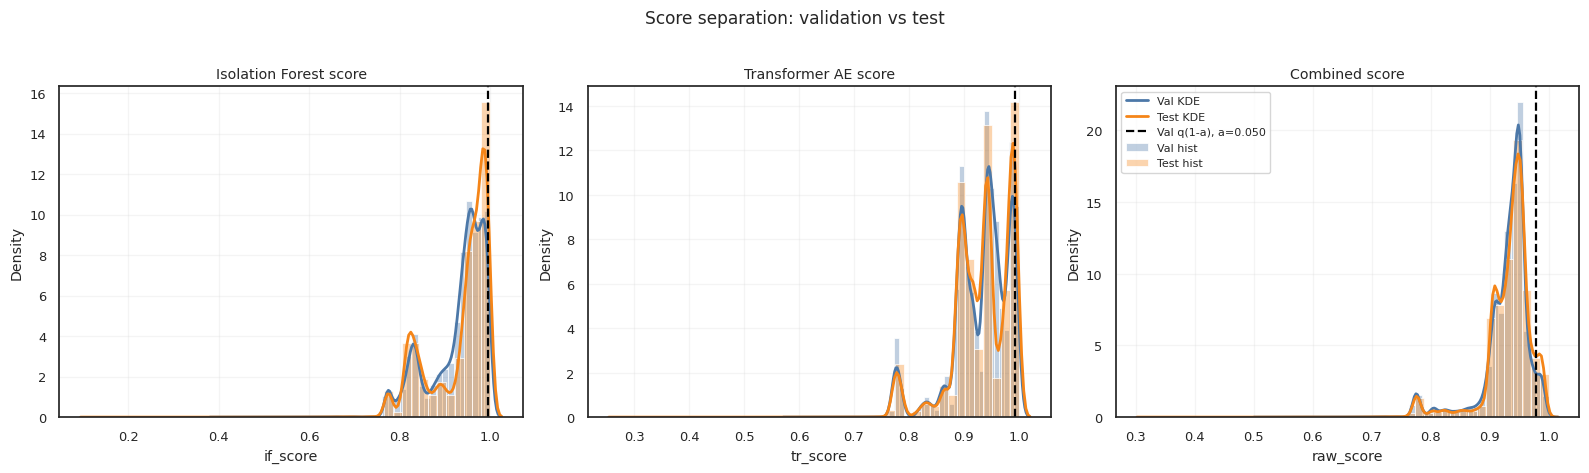

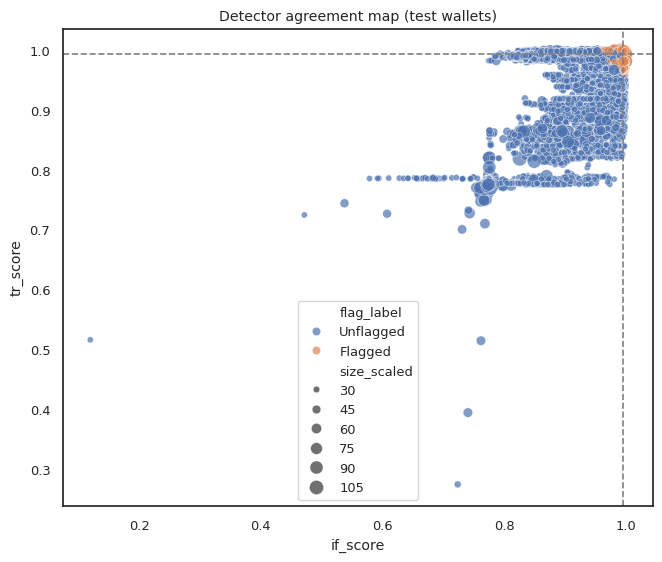

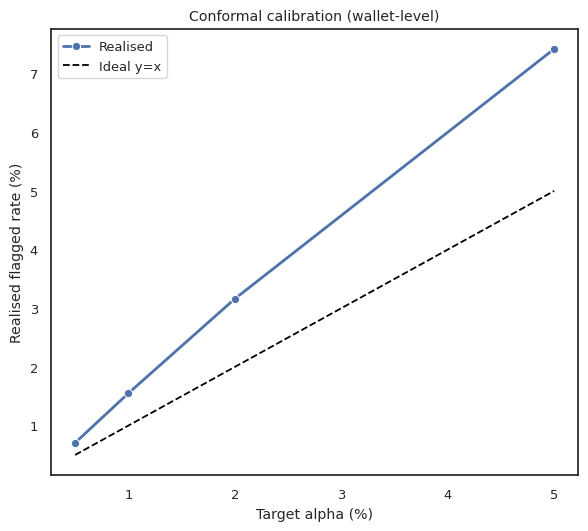

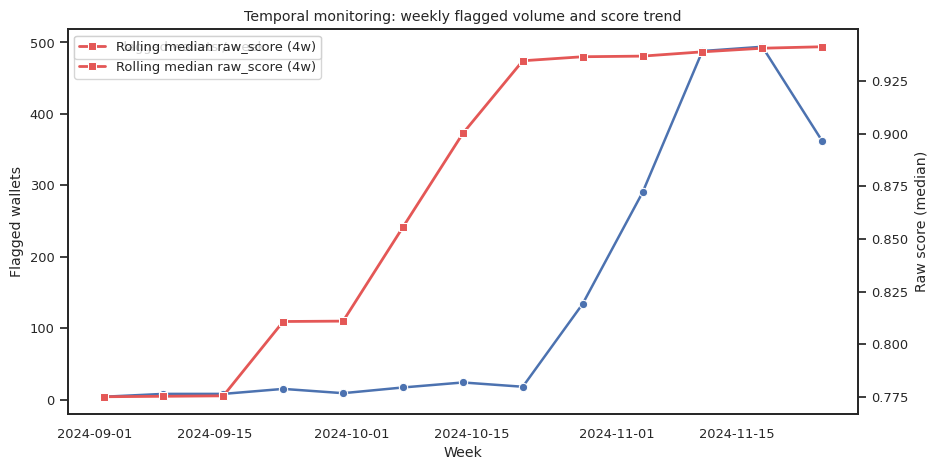

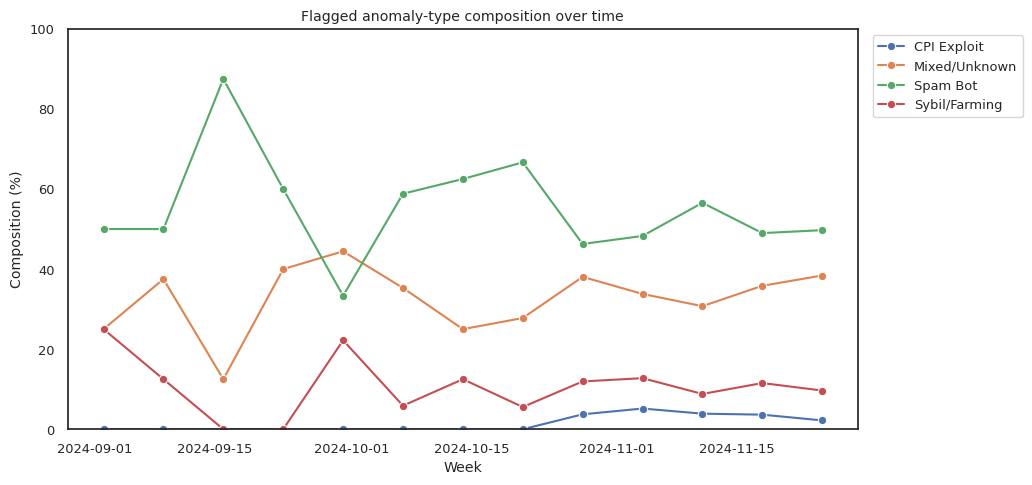

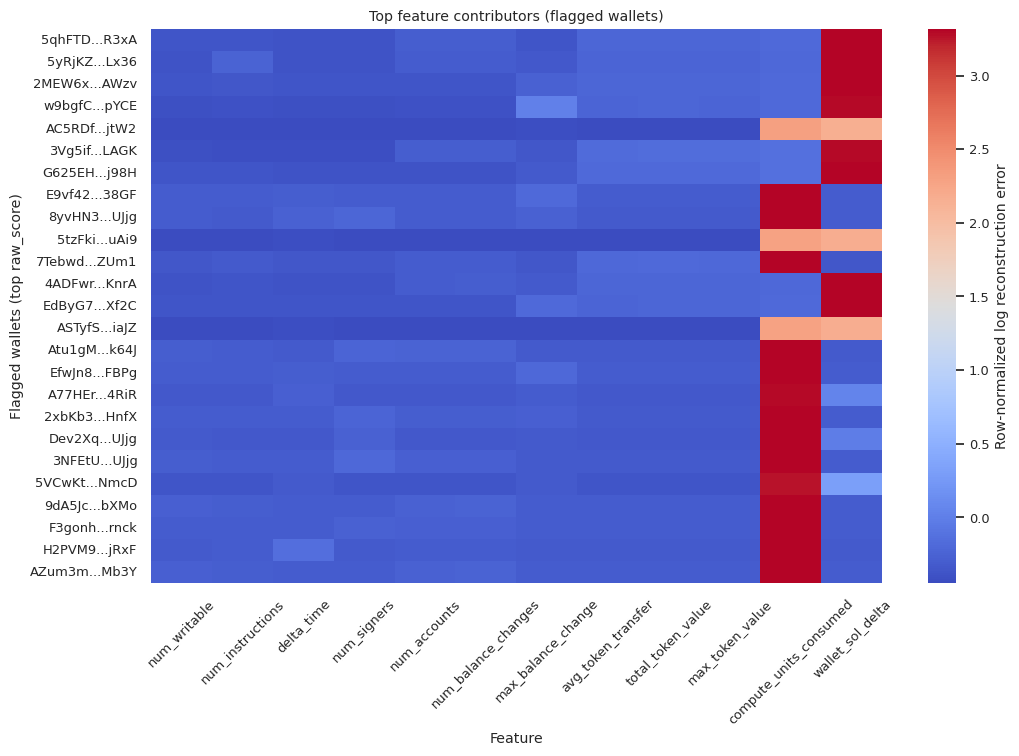

Main-report figures generated:
                         figure                                                                                  path
      score_separation_hist_kde       /kaggle/working/monitoring/main_report_figures/01_score_separation_hist_kde.png
     detector_agreement_scatter      /kaggle/working/monitoring/main_report_figures/02_detector_agreement_scatter.png
    conformal_calibration_curve     /kaggle/working/monitoring/main_report_figures/03_conformal_calibration_curve.png
      temporal_monitoring_trend       /kaggle/working/monitoring/main_report_figures/04_temporal_monitoring_trend.png
anomaly_type_composition_weekly /kaggle/working/monitoring/main_report_figures/05_anomaly_type_composition_weekly.png
    feature_contributor_heatmap     /kaggle/working/monitoring/main_report_figures/06_feature_contributor_heatmap.png

Output folder: /kaggle/working/monitoring/main_report_figures


In [128]:
# ── 11. Main-report figures (high-signal, publication-ready) ─────────────────
import os


def _finite(a):
    x = np.asarray(a, dtype=float)
    return x[np.isfinite(x)]


def _psi_local(expected, actual, bins=10, eps=1e-6):
    exp = _finite(expected)
    act = _finite(actual)
    if len(exp) == 0 or len(act) == 0:
        return np.nan

    edges = np.quantile(exp, np.linspace(0, 1, bins + 1))
    edges = np.unique(edges)
    if len(edges) < 3:
        return 0.0

    exp_hist, _ = np.histogram(exp, bins=edges)
    act_hist, _ = np.histogram(act, bins=edges)

    exp_pct = np.clip(exp_hist / max(exp_hist.sum(), 1), eps, None)
    act_pct = np.clip(act_hist / max(act_hist.sum(), 1), eps, None)
    return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))


def _conformal_rate_local(cal_scores, test_scores, alpha):
    cal = _finite(cal_scores)
    tst = _finite(test_scores)
    if len(cal) == 0 or len(tst) == 0:
        return np.nan, np.nan

    thr = float(np.quantile(cal, 1 - alpha))
    pvals = np.array([(np.sum(cal >= s) + 1) / (len(cal) + 1) for s in tst], dtype=float)
    rate = float((pvals <= alpha).mean())
    return thr, rate


def _plot_hist_kde(ax, data, color, label, alpha=0.35):
    x = _finite(data)
    if len(x) == 0:
        return

    sns.histplot(x=x, bins=45, stat='density', alpha=alpha, color=color, label=f'{label} hist', ax=ax)
    if len(np.unique(x)) > 3:
        try:
            sns.kdeplot(x=x, color=color, linewidth=2.0, label=f'{label} KDE', ax=ax)
        except Exception:
            pass


def _wallet_time_map(df):
    if {'wallet', 'block_timestamp', 'combined_tx_score'}.issubset(df.columns):
        idx = df.groupby('wallet')['combined_tx_score'].idxmax()
    elif {'wallet', 'block_timestamp', 'tr_tx_score'}.issubset(df.columns):
        idx = df.groupby('wallet')['tr_tx_score'].idxmax()
    elif {'wallet', 'block_timestamp'}.issubset(df.columns):
        idx = df.groupby('wallet')['block_timestamp'].idxmax()
    else:
        return pd.Series(dtype='datetime64[ns]')

    out = (
        df.loc[idx, ['wallet', 'block_timestamp']]
        .drop_duplicates('wallet')
        .set_index('wallet')['block_timestamp']
    )
    return pd.to_datetime(out, errors='coerce')


if 'wallet_scores' not in globals() or 'df_flat' not in globals():
    raise RuntimeError('Run earlier sections first (wallet_scores/df_flat missing).')

EXPORT_ROOT = '/kaggle/working' if os.path.isdir('/kaggle/working') else os.getcwd()
MAIN_FIG_DIR = os.path.join(EXPORT_ROOT, 'monitoring', 'main_report_figures')
os.makedirs(MAIN_FIG_DIR, exist_ok=True)
main_fig_manifest = []

alpha_main = float(ALPHA) if 'ALPHA' in globals() else 0.01

# Masks
if 'test_wallets' in globals():
    test_mask_main = wallet_scores['wallet'].isin(test_wallets).to_numpy()
else:
    test_mask_main = np.ones(len(wallet_scores), dtype=bool)

if 'val_wallets' in globals():
    val_mask_main = wallet_scores['wallet'].isin(val_wallets).to_numpy()
else:
    val_mask_main = ~test_mask_main

if val_mask_main.sum() == 0:
    val_mask_main = test_mask_main.copy()

# Common vectors
for col in ['if_score', 'tr_score', 'raw_score']:
    if col not in wallet_scores.columns:
        raise RuntimeError(f'Missing required column in wallet_scores: {col}')

if 'conformal_flag' in wallet_scores.columns:
    flag_main = wallet_scores['conformal_flag'].fillna(0).astype(int).to_numpy()
else:
    flag_main = np.zeros(len(wallet_scores), dtype=int)

if 'n_tx' in wallet_scores.columns:
    n_tx_main = wallet_scores['n_tx'].fillna(1).to_numpy(dtype=float)
else:
    n_tx_main = np.ones(len(wallet_scores), dtype=float)

# ── Figure 1: Score separation (hist + KDE) ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharey=False)
score_specs = [
    ('if_score', 'Isolation Forest score'),
    ('tr_score', 'Transformer AE score'),
    ('raw_score', 'Combined score'),
]

for ax, (col, title) in zip(axes, score_specs):
    val_x = _finite(wallet_scores.loc[val_mask_main, col].to_numpy(dtype=float))
    tst_x = _finite(wallet_scores.loc[test_mask_main, col].to_numpy(dtype=float))

    _plot_hist_kde(ax, val_x, color='#4C78A8', label='Val')
    _plot_hist_kde(ax, tst_x, color='#F58518', label='Test')

    if len(val_x):
        thr = float(np.quantile(val_x, 1 - alpha_main))
        ax.axvline(thr, linestyle='--', linewidth=1.6, color='black', label=f'Val q(1-a), a={alpha_main:.3f}')

    ax.set_title(title)
    ax.set_xlabel(col)
    ax.grid(alpha=0.20)

axes[0].set_ylabel('Density')
handles, labels = axes[-1].get_legend_handles_labels()
if len(handles):
    axes[-1].legend(loc='best', fontsize=8)

fig.suptitle('Score separation: validation vs test', y=1.02)
plt.tight_layout()
fig1_path = os.path.join(MAIN_FIG_DIR, '01_score_separation_hist_kde.png')
fig.savefig(fig1_path, dpi=170, bbox_inches='tight')
plt.show()
main_fig_manifest.append({'figure': 'score_separation_hist_kde', 'path': fig1_path})

# ── Figure 2: Detector agreement map ─────────────────────────────────────────
plot_df = wallet_scores.loc[test_mask_main, ['wallet', 'if_score', 'tr_score', 'raw_score']].copy()
plot_df['flag'] = flag_main[test_mask_main]
plot_df['n_tx'] = n_tx_main[test_mask_main]

if len(plot_df):
    plot_df = plot_df.copy()
    plot_df['flag_label'] = np.where(plot_df['flag'].astype(int) == 1, 'Flagged', 'Unflagged')
    plot_df['size_scaled'] = 20 + 90 * (
        np.log1p(plot_df['n_tx'].to_numpy()) / np.log1p(max(plot_df['n_tx'].max(), 1))
    )

    fig, ax = plt.subplots(figsize=(7.6, 6.2))
    sns.scatterplot(
        data=plot_df,
        x='if_score',
        y='tr_score',
        hue='flag_label',
        size='size_scaled',
        sizes=(20, 110),
        alpha=0.70,
        ax=ax,
    )

    thr_if = float(np.quantile(_finite(wallet_scores.loc[val_mask_main, 'if_score']), 1 - alpha_main))
    thr_tr = float(np.quantile(_finite(wallet_scores.loc[val_mask_main, 'tr_score']), 1 - alpha_main))
    ax.axvline(thr_if, linestyle='--', linewidth=1.2, color='gray')
    ax.axhline(thr_tr, linestyle='--', linewidth=1.2, color='gray')

    ax.set_title('Detector agreement map (test wallets)')
    ax.set_xlabel('if_score')
    ax.set_ylabel('tr_score')
    ax.legend(loc='best')

    fig2_path = os.path.join(MAIN_FIG_DIR, '02_detector_agreement_scatter.png')
    fig.savefig(fig2_path, dpi=170, bbox_inches='tight')
    plt.show()
    main_fig_manifest.append({'figure': 'detector_agreement_scatter', 'path': fig2_path})

# ── Figure 3: Conformal calibration curve ────────────────────────────────────
if 'no_label_dashboard' in globals() and isinstance(no_label_dashboard.get('conformal_diagnostics', None), pd.DataFrame):
    conf_df = no_label_dashboard['conformal_diagnostics'].copy()
else:
    alpha_grid = [0.005, 0.01, 0.02, 0.05]
    conf_rows = []
    cal = wallet_scores.loc[val_mask_main, 'raw_score'].to_numpy(dtype=float)
    tst = wallet_scores.loc[test_mask_main, 'raw_score'].to_numpy(dtype=float)
    for a in alpha_grid:
        thr, rr = _conformal_rate_local(cal, tst, a)
        conf_rows.append({'alpha_target': float(a), 'threshold': thr, 'realized_flag_rate_pct': float(rr * 100)})
    conf_df = pd.DataFrame(conf_rows)

if len(conf_df):
    conf_df = conf_df.copy()
    y_col = 'realised_flag_rate_pct' if 'realised_flag_rate_pct' in conf_df.columns else 'realized_flag_rate_pct'
    conf_df['target_alpha_pct'] = 100.0 * conf_df['alpha_target'].astype(float)

    fig, ax = plt.subplots(figsize=(6.8, 5.8))
    sns.lineplot(data=conf_df, x='target_alpha_pct', y=y_col, marker='o', linewidth=2.0, label='Realised', ax=ax)
    _x = np.sort(conf_df['target_alpha_pct'].to_numpy(dtype=float))
    _ideal = pd.DataFrame({'target_alpha_pct': _x, 'ideal': _x})
    sns.lineplot(data=_ideal, x='target_alpha_pct', y='ideal', linestyle='--', linewidth=1.3, color='black', label='Ideal y=x', ax=ax)
    ax.set_title('Conformal calibration (wallet-level)')
    ax.set_xlabel('Target alpha (%)')
    ax.set_ylabel('Realised flagged rate (%)')
    ax.legend(loc='best')

    fig3_path = os.path.join(MAIN_FIG_DIR, '03_conformal_calibration_curve.png')
    fig.savefig(fig3_path, dpi=170, bbox_inches='tight')
    plt.show()
    main_fig_manifest.append({'figure': 'conformal_calibration_curve', 'path': fig3_path})

# Shared wallet->time map
wallet_ts_map = _wallet_time_map(df_flat)

# ── Figure 4: Temporal monitoring trend ──────────────────────────────────────
trend_df = wallet_scores.loc[test_mask_main, ['wallet', 'raw_score']].copy()
trend_df['flag'] = flag_main[test_mask_main]
trend_df['top_tx_ts'] = pd.to_datetime(trend_df['wallet'].map(wallet_ts_map), errors='coerce')
trend_df = trend_df.dropna(subset=['top_tx_ts'])

if len(trend_df):
    trend_df['week'] = trend_df['top_tx_ts'].dt.to_period('W').dt.start_time

    weekly_flagged = trend_df.groupby('week')['flag'].sum().sort_index()
    weekly_med_raw = trend_df.groupby('week')['raw_score'].median().sort_index()
    weekly_med_roll = weekly_med_raw.rolling(4, min_periods=1).median()

    _trend_plot = pd.DataFrame({
        'week': weekly_flagged.index,
        'flagged_wallets': weekly_flagged.values,
        'rolling_median_raw_score': weekly_med_roll.reindex(weekly_flagged.index).values,
    })

    fig, ax1 = plt.subplots(figsize=(10.2, 5.0))
    sns.lineplot(data=_trend_plot, x='week', y='flagged_wallets', marker='o', linewidth=1.8, label='Flagged wallets / week', ax=ax1)
    ax1.set_xlabel('Week')
    ax1.set_ylabel('Flagged wallets')

    ax2 = ax1.twinx()
    sns.lineplot(
        data=_trend_plot,
        x='week',
        y='rolling_median_raw_score',
        marker='s',
        linewidth=2.0,
        color='#E45756',
        label='Rolling median raw_score (4w)',
        ax=ax2,
    )
    ax2.set_ylabel('Raw score (median)')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    ax1.set_title('Temporal monitoring: weekly flagged volume and score trend')

    fig4_path = os.path.join(MAIN_FIG_DIR, '04_temporal_monitoring_trend.png')
    fig.savefig(fig4_path, dpi=170, bbox_inches='tight')
    plt.show()
    main_fig_manifest.append({'figure': 'temporal_monitoring_trend', 'path': fig4_path})

# ── Figure 5: Anomaly-type composition over time ─────────────────────────────
if 'semantic_anomaly_type' in wallet_scores.columns:
    comp_df = wallet_scores.loc[test_mask_main, ['wallet', 'semantic_anomaly_type']].copy()
    comp_df['flag'] = flag_main[test_mask_main]
    comp_df['top_tx_ts'] = pd.to_datetime(comp_df['wallet'].map(wallet_ts_map), errors='coerce')
    comp_df = comp_df.dropna(subset=['top_tx_ts'])
    comp_df = comp_df[(comp_df['flag'] == 1) & comp_df['semantic_anomaly_type'].notna()]

    if len(comp_df):
        comp_df['week'] = comp_df['top_tx_ts'].dt.to_period('W').dt.start_time
        type_week = comp_df.groupby(['week', 'semantic_anomaly_type']).size().unstack(fill_value=0).sort_index()
        type_week = type_week.loc[type_week.sum(axis=1) > 0]

        if len(type_week):
            comp_pct = (type_week.div(type_week.sum(axis=1), axis=0) * 100).reset_index()
            comp_long = comp_pct.melt(id_vars='week', var_name='semantic_anomaly_type', value_name='composition_pct')

            fig, ax = plt.subplots(figsize=(10.2, 5.2))
            sns.lineplot(data=comp_long, x='week', y='composition_pct', hue='semantic_anomaly_type', marker='o', ax=ax)
            ax.set_title('Flagged anomaly-type composition over time')
            ax.set_xlabel('Week')
            ax.set_ylabel('Composition (%)')
            ax.set_ylim(0, 100)
            ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0))

            fig5_path = os.path.join(MAIN_FIG_DIR, '05_anomaly_type_composition_weekly.png')
            fig.savefig(fig5_path, dpi=170, bbox_inches='tight')
            plt.show()
            main_fig_manifest.append({'figure': 'anomaly_type_composition_weekly', 'path': fig5_path})

# ── Figure 6: Top feature-contributor heatmap ────────────────────────────────
if all(v in globals() for v in ['per_feat_errors', 'tx_feature_cols']) and isinstance(per_feat_errors, np.ndarray):
    if 'combined_tx_score' in df_flat.columns:
        top_tx_idx_map = df_flat.groupby('wallet')['combined_tx_score'].idxmax()
    elif 'tr_tx_score' in df_flat.columns:
        top_tx_idx_map = df_flat.groupby('wallet')['tr_tx_score'].idxmax()
    else:
        top_tx_idx_map = df_flat.reset_index().groupby('wallet')['index'].first()

    flagged_wallets = wallet_scores.loc[test_mask_main].copy()
    flagged_wallets['flag'] = flag_main[test_mask_main]
    flagged_wallets = flagged_wallets[flagged_wallets['flag'] == 1]

    if len(flagged_wallets):
        top_wallets = flagged_wallets.sort_values('raw_score', ascending=False).head(25)['wallet']
        tx_lookup = top_tx_idx_map.reindex(top_wallets).dropna()
        tx_idx = tx_lookup.astype(int).to_numpy()

        if len(tx_idx):
            mat = per_feat_errors[tx_idx]
            n_show_feat = int(min(12, mat.shape[1]))
            feat_ids = np.argsort(mat.mean(axis=0))[-n_show_feat:]
            feat_names = [tx_feature_cols[i] for i in feat_ids]
            mat_show = np.log1p(mat[:, feat_ids])

            row_std = mat_show.std(axis=1, keepdims=True) + 1e-9
            mat_norm = (mat_show - mat_show.mean(axis=1, keepdims=True)) / row_std

            wallet_labels = []
            for w in tx_lookup.index.astype(str):
                wallet_labels.append(w if len(w) <= 14 else f"{w[:6]}...{w[-4:]}")

            fig, ax = plt.subplots(figsize=(11.8, 7.2))
            sns.heatmap(
                mat_norm,
                cmap='coolwarm',
                xticklabels=feat_names,
                yticklabels=wallet_labels,
                cbar_kws={'label': 'Row-normalized log reconstruction error'},
                ax=ax,
            )
            ax.set_title('Top feature contributors (flagged wallets)')
            ax.set_xlabel('Feature')
            ax.set_ylabel('Flagged wallets (top raw_score)')
            ax.tick_params(axis='x', rotation=45)

            fig6_path = os.path.join(MAIN_FIG_DIR, '06_feature_contributor_heatmap.png')
            fig.savefig(fig6_path, dpi=170, bbox_inches='tight')
            plt.show()
            main_fig_manifest.append({'figure': 'feature_contributor_heatmap', 'path': fig6_path})

main_report_figures_manifest = pd.DataFrame(main_fig_manifest)
print('Main-report figures generated:')
print(main_report_figures_manifest.to_string(index=False) if len(main_report_figures_manifest) else 'No figures generated.')
print(f'\nOutput folder: {MAIN_FIG_DIR}')

if 'no_label_dashboard' in globals() and isinstance(main_report_figures_manifest, pd.DataFrame):
    no_label_dashboard['main_report_figures_manifest'] = main_report_figures_manifest

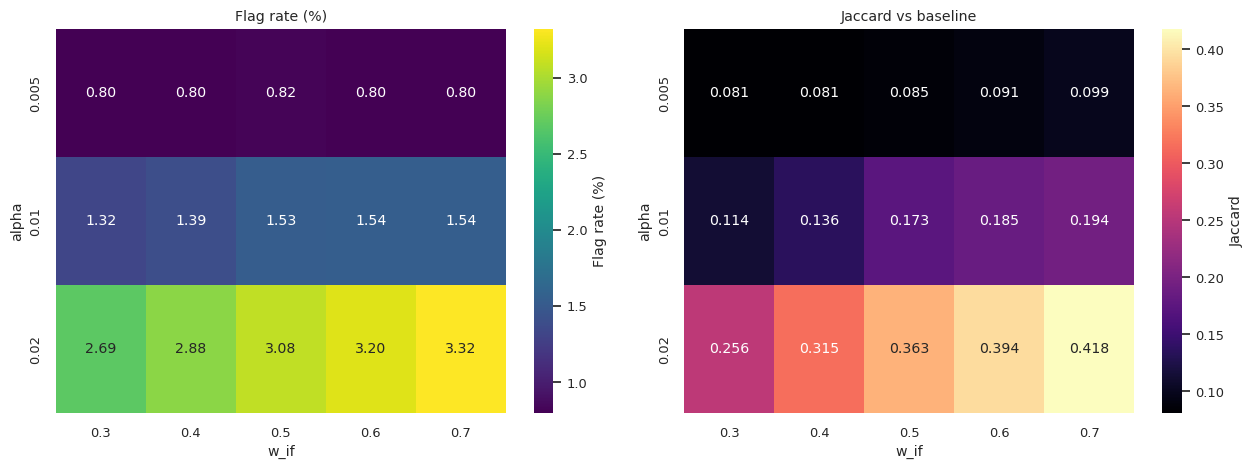

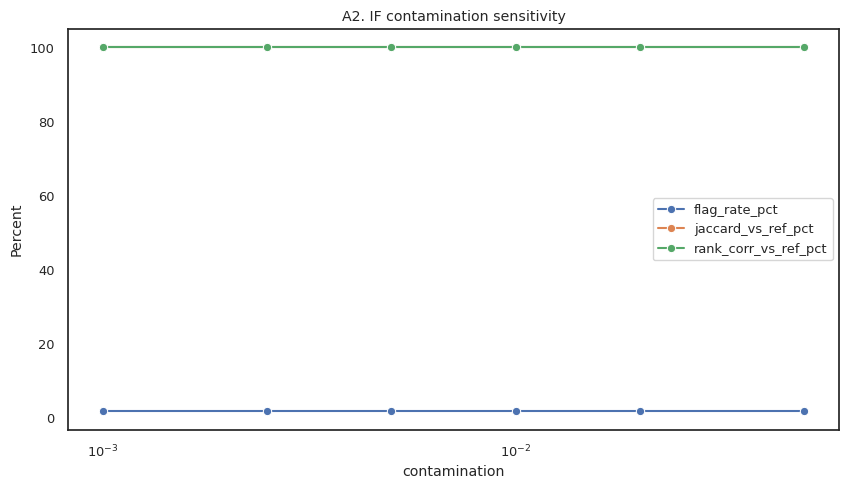

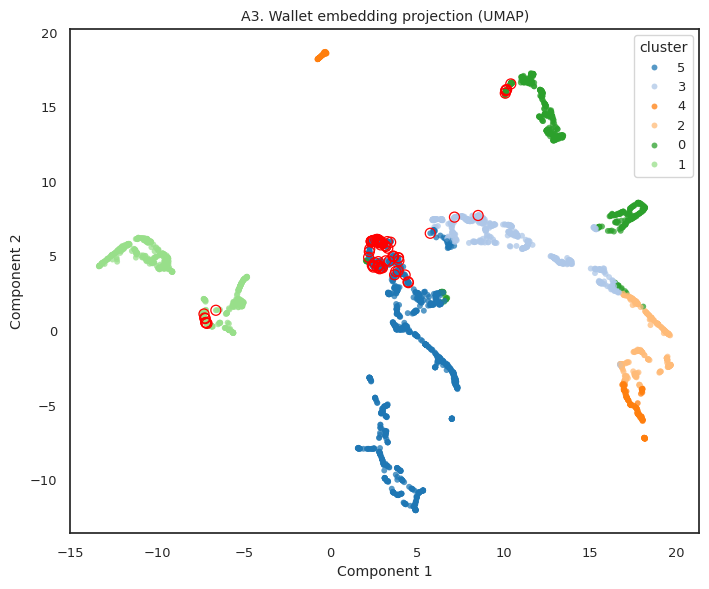

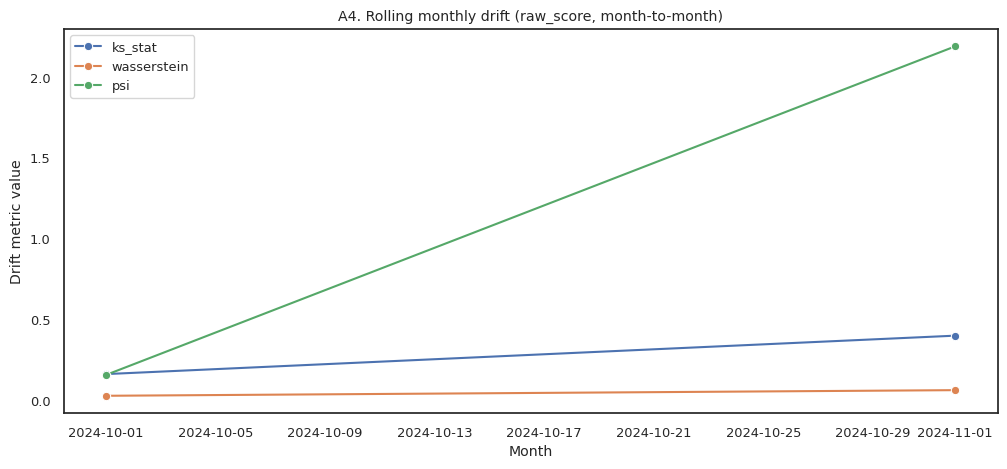

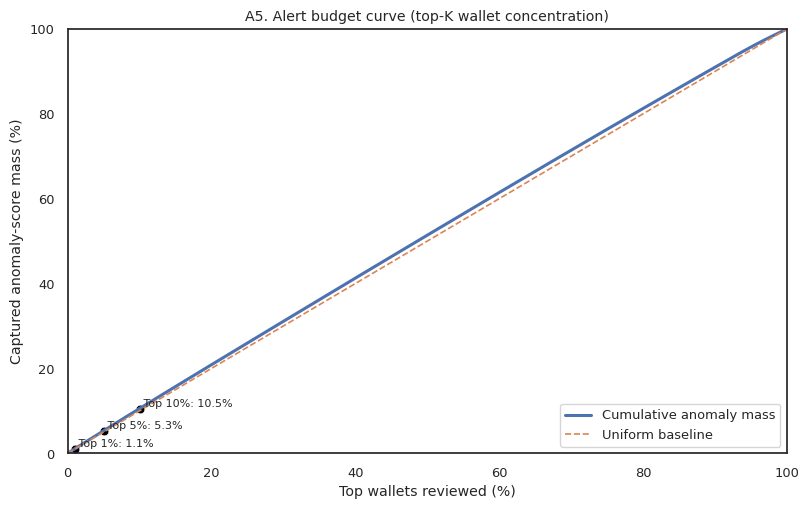

Appendix figures generated:
                         figure                                                                            path
     A1_hyperparameter_heatmaps      /kaggle/working/monitoring/appendix_figures/A1_hyperparameter_heatmaps.png
A2_if_contamination_sensitivity /kaggle/working/monitoring/appendix_figures/A2_if_contamination_sensitivity.png
        A3_embedding_projection         /kaggle/working/monitoring/appendix_figures/A3_embedding_projection.png
         A4_monthly_drift_panel          /kaggle/working/monitoring/appendix_figures/A4_monthly_drift_panel.png
          A5_alert_budget_curve           /kaggle/working/monitoring/appendix_figures/A5_alert_budget_curve.png

Output folder: /kaggle/working/monitoring/appendix_figures


In [129]:
# ── 12. Appendix visual pack (robustness + ops diagnostics) ─────────────────
import os
from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


EXPORT_ROOT = '/kaggle/working' if os.path.isdir('/kaggle/working') else os.getcwd()
APP_FIG_DIR = os.path.join(EXPORT_ROOT, 'monitoring', 'appendix_figures')
os.makedirs(APP_FIG_DIR, exist_ok=True)
appendix_manifest = []


def _finite_local(a):
    x = np.asarray(a, dtype=float)
    return x[np.isfinite(x)]


def _psi_month(expected, actual, bins=10, eps=1e-6):
    exp = _finite_local(expected)
    act = _finite_local(actual)
    if len(exp) == 0 or len(act) == 0:
        return np.nan

    edges = np.quantile(exp, np.linspace(0, 1, bins + 1))
    edges = np.unique(edges)
    if len(edges) < 3:
        return 0.0

    exp_hist, _ = np.histogram(exp, bins=edges)
    act_hist, _ = np.histogram(act, bins=edges)

    exp_pct = np.clip(exp_hist / max(exp_hist.sum(), 1), eps, None)
    act_pct = np.clip(act_hist / max(act_hist.sum(), 1), eps, None)
    return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))


def _wallet_time_map_appendix(df):
    if {'wallet', 'block_timestamp', 'combined_tx_score'}.issubset(df.columns):
        idx = df.groupby('wallet')['combined_tx_score'].idxmax()
    elif {'wallet', 'block_timestamp', 'tr_tx_score'}.issubset(df.columns):
        idx = df.groupby('wallet')['tr_tx_score'].idxmax()
    elif {'wallet', 'block_timestamp'}.issubset(df.columns):
        idx = df.groupby('wallet')['block_timestamp'].idxmax()
    else:
        return pd.Series(dtype='datetime64[ns]')

    out = (
        df.loc[idx, ['wallet', 'block_timestamp']]
        .drop_duplicates('wallet')
        .set_index('wallet')['block_timestamp']
    )
    return pd.to_datetime(out, errors='coerce')


# A1) Hyperparameter heatmaps (from section 3 sensitivity sweep)
if 'sensitivity_results' in globals() and isinstance(sensitivity_results, pd.DataFrame) and len(sensitivity_results):
    piv_flag = sensitivity_results.pivot(index='alpha', columns='w_if', values='flag_rate_pct').sort_index()
    piv_jac = sensitivity_results.pivot(index='alpha', columns='w_if', values='jaccard_vs_baseline').sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
    sns.heatmap(
        piv_flag,
        cmap='viridis',
        annot=True,
        fmt='.2f',
        cbar_kws={'label': 'Flag rate (%)'},
        ax=axes[0],
    )
    axes[0].set_title('Flag rate (%)')
    axes[0].set_xlabel('w_if')
    axes[0].set_ylabel('alpha')

    sns.heatmap(
        piv_jac,
        cmap='magma',
        annot=True,
        fmt='.3f',
        cbar_kws={'label': 'Jaccard'},
        ax=axes[1],
    )
    axes[1].set_title('Jaccard vs baseline')
    axes[1].set_xlabel('w_if')
    axes[1].set_ylabel('alpha')

    plt.tight_layout()
    a1_path = os.path.join(APP_FIG_DIR, 'A1_hyperparameter_heatmaps.png')
    fig.savefig(a1_path, dpi=170, bbox_inches='tight')
    plt.show()
    appendix_manifest.append({'figure': 'A1_hyperparameter_heatmaps', 'path': a1_path})

# A2) IF contamination sweep curves (from section 9)
if 'if_sensitivity_results' in globals() and isinstance(if_sensitivity_results, pd.DataFrame) and len(if_sensitivity_results):
    d = if_sensitivity_results.sort_values('contamination').copy()
    d['jaccard_vs_ref_pct'] = 100.0 * d['jaccard_vs_ref'] if 'jaccard_vs_ref' in d.columns else np.nan
    d['rank_corr_vs_ref_pct'] = 100.0 * d['rank_corr_vs_ref'] if 'rank_corr_vs_ref' in d.columns else np.nan

    pcols = [c for c in ['flag_rate_pct', 'jaccard_vs_ref_pct', 'rank_corr_vs_ref_pct'] if c in d.columns]
    dm = d.melt(id_vars='contamination', value_vars=pcols, var_name='metric', value_name='percent')

    fig, ax = plt.subplots(figsize=(8.6, 5.0))
    sns.lineplot(data=dm, x='contamination', y='percent', hue='metric', marker='o', ax=ax)
    ax.set_xscale('log')
    ax.set_title('A2. IF contamination sensitivity')
    ax.set_xlabel('contamination')
    ax.set_ylabel('Percent')
    ax.legend(loc='best')

    plt.tight_layout()
    a2_path = os.path.join(APP_FIG_DIR, 'A2_if_contamination_sensitivity.png')
    fig.savefig(a2_path, dpi=170, bbox_inches='tight')
    plt.show()
    appendix_manifest.append({'figure': 'A2_if_contamination_sensitivity', 'path': a2_path})

# A3) Embedding projection (UMAP if available, else t-SNE, else PCA)
projection_meta = pd.DataFrame()
if 'X_emb' in globals() and 'wallet_rep' in globals():
    X_all = np.asarray(X_emb, dtype=float)
    w_all = np.asarray(wallet_rep)

    if len(X_all) >= 20 and len(w_all) == len(X_all):
        rng = np.random.default_rng(42)
        n_plot = int(min(3000, len(X_all)))
        idx = rng.choice(len(X_all), size=n_plot, replace=False) if len(X_all) > n_plot else np.arange(len(X_all))

        X_plot = X_all[idx]
        w_plot = w_all[idx]

        # Cluster coloring
        if 'wallet_embedding_clusters' in globals() and isinstance(wallet_embedding_clusters, pd.DataFrame) and len(wallet_embedding_clusters):
            cl_map = wallet_embedding_clusters.set_index('wallet')['cluster']
            cluster = pd.Series(w_plot).map(cl_map).fillna(-1).astype(int).to_numpy()
        else:
            k_guess = 4
            if 'transformer_embedding_meta' in globals() and isinstance(transformer_embedding_meta, pd.DataFrame) and len(transformer_embedding_meta):
                if 'best_k' in transformer_embedding_meta.columns:
                    k_guess = int(transformer_embedding_meta['best_k'].iloc[0])
            km_tmp = KMeans(n_clusters=max(2, min(k_guess, len(X_plot) - 1)), random_state=42, n_init=10)
            cluster = km_tmp.fit_predict(X_plot)

        # Flag overlay
        if 'conformal_flag' in wallet_scores.columns:
            f_map = wallet_scores.set_index('wallet')['conformal_flag'].fillna(0).astype(int)
            flag = pd.Series(w_plot).map(f_map).fillna(0).astype(int).to_numpy()
        else:
            flag = np.zeros(len(w_plot), dtype=int)

        method = 'PCA'
        reducer_note = ''
        try:
            import umap
            reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=25, min_dist=0.10)
            XY = reducer.fit_transform(X_plot)
            method = 'UMAP'
        except Exception as e_umap:
            try:
                XY = TSNE(n_components=2, random_state=42, perplexity=30, init='pca').fit_transform(X_plot)
                method = 't-SNE'
            except Exception as e_tsne:
                XY = PCA(n_components=2, random_state=42).fit_transform(X_plot)
                method = 'PCA'
                reducer_note = f'Fallback due to UMAP/t-SNE errors: {str(e_umap)[:80]} | {str(e_tsne)[:80]}'

        _proj_df = pd.DataFrame({
            'x': XY[:, 0],
            'y': XY[:, 1],
            'cluster': cluster.astype(str),
            'flag': flag.astype(int),
        })

        fig, ax = plt.subplots(figsize=(7.2, 6.0))
        sns.scatterplot(data=_proj_df, x='x', y='y', hue='cluster', palette='tab20', s=18, alpha=0.75, linewidth=0, ax=ax)
        if np.sum(flag == 1):
            sns.scatterplot(
                data=_proj_df[_proj_df['flag'] == 1],
                x='x',
                y='y',
                s=52,
                facecolor='none',
                edgecolor='red',
                linewidth=0.9,
                legend=False,
                ax=ax,
            )

        ax.set_title(f'A3. Wallet embedding projection ({method})')
        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')

        plt.tight_layout()
        a3_path = os.path.join(APP_FIG_DIR, 'A3_embedding_projection.png')
        fig.savefig(a3_path, dpi=170, bbox_inches='tight')
        plt.show()
        appendix_manifest.append({'figure': 'A3_embedding_projection', 'path': a3_path})

        projection_meta = pd.DataFrame([{
            'method': method,
            'n_points_plotted': int(len(X_plot)),
            'flagged_points': int(np.sum(flag == 1)),
            'note': reducer_note,
        }])

# A4) Rolling drift panel by month (raw_score)
monthly_drift = pd.DataFrame()
if 'wallet_scores' in globals() and 'df_flat' in globals() and 'raw_score' in wallet_scores.columns:
    tmap = _wallet_time_map_appendix(df_flat)
    wd = wallet_scores[['wallet', 'raw_score']].copy()

    if 'test_wallets' in globals():
        wd = wd[wd['wallet'].isin(test_wallets)]

    wd['ts'] = pd.to_datetime(wd['wallet'].map(tmap), errors='coerce')
    wd = wd.dropna(subset=['ts'])

    if len(wd):
        wd['month'] = wd['ts'].dt.to_period('M').dt.to_timestamp()
        months = sorted(wd['month'].dropna().unique())

        rows = []
        prev = None
        for m in months:
            cur = _finite_local(wd.loc[wd['month'] == m, 'raw_score'].to_numpy(dtype=float))
            if prev is None:
                prev = cur
                continue
            if len(prev) == 0 or len(cur) == 0:
                prev = cur
                continue

            ks_stat, ks_p = ks_2samp(prev, cur)
            rows.append({
                'month': pd.Timestamp(m),
                'ks_stat': float(ks_stat),
                'ks_pvalue': float(ks_p),
                'wasserstein': float(wasserstein_distance(prev, cur)),
                'psi': float(_psi_month(prev, cur, bins=10)),
            })
            prev = cur

        monthly_drift = pd.DataFrame(rows)

        if len(monthly_drift):
            mdm = monthly_drift.melt(id_vars='month', value_vars=['ks_stat', 'wasserstein', 'psi'], var_name='metric', value_name='value')
            fig, ax = plt.subplots(figsize=(10.2, 4.8))
            sns.lineplot(data=mdm, x='month', y='value', hue='metric', marker='o', ax=ax)
            ax.set_title('A4. Rolling monthly drift (raw_score, month-to-month)')
            ax.set_xlabel('Month')
            ax.set_ylabel('Drift metric value')
            ax.legend(loc='best')

            plt.tight_layout()
            a4_path = os.path.join(APP_FIG_DIR, 'A4_monthly_drift_panel.png')
            fig.savefig(a4_path, dpi=170, bbox_inches='tight')
            plt.show()
            appendix_manifest.append({'figure': 'A4_monthly_drift_panel', 'path': a4_path})

# A5) Alert budget curve
if 'raw_score' in wallet_scores.columns:
    if 'test_wallets' in globals():
        score_budget = _finite_local(wallet_scores.loc[wallet_scores['wallet'].isin(test_wallets), 'raw_score'].to_numpy(dtype=float))
    else:
        score_budget = _finite_local(wallet_scores['raw_score'].to_numpy(dtype=float))

    if len(score_budget):
        s = np.sort(score_budget)[::-1]
        k = np.arange(1, len(s) + 1)
        cum_mass_pct = 100.0 * np.cumsum(s) / (np.sum(s) + 1e-12)
        wallet_pct = 100.0 * k / len(s)

        curve_df = pd.DataFrame({'wallet_pct': wallet_pct, 'cum_mass_pct': cum_mass_pct})

        fig, ax = plt.subplots(figsize=(8.2, 5.2))
        sns.lineplot(data=curve_df, x='wallet_pct', y='cum_mass_pct', linewidth=2.2, label='Cumulative anomaly mass', ax=ax)
        sns.lineplot(data=curve_df, x='wallet_pct', y='wallet_pct', linestyle='--', linewidth=1.2, label='Uniform baseline', ax=ax)

        for p in [1, 5, 10]:
            idx_p = max(1, int(np.ceil((p / 100.0) * len(s)))) - 1
            _x = wallet_pct[idx_p]
            _y = cum_mass_pct[idx_p]
            sns.scatterplot(x=[_x], y=[_y], s=40, color='black', ax=ax, legend=False)
            ax.text(_x, _y, f' Top {p}%: {_y:.1f}%', fontsize=8, va='bottom')

        ax.set_title('A5. Alert budget curve (top-K wallet concentration)')
        ax.set_xlabel('Top wallets reviewed (%)')
        ax.set_ylabel('Captured anomaly-score mass (%)')
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        ax.legend(loc='lower right')

        plt.tight_layout()
        a5_path = os.path.join(APP_FIG_DIR, 'A5_alert_budget_curve.png')
        fig.savefig(a5_path, dpi=170, bbox_inches='tight')
        plt.show()
        appendix_manifest.append({'figure': 'A5_alert_budget_curve', 'path': a5_path})

appendix_figures_manifest = pd.DataFrame(appendix_manifest)
print('Appendix figures generated:')
print(appendix_figures_manifest.to_string(index=False) if len(appendix_figures_manifest) else 'No figures generated.')
print(f'\nOutput folder: {APP_FIG_DIR}')

if 'no_label_dashboard' in globals():
    no_label_dashboard['appendix_figures_manifest'] = appendix_figures_manifest
    if len(monthly_drift):
        no_label_dashboard['monthly_drift'] = monthly_drift
    if len(projection_meta):
        no_label_dashboard['embedding_projection_meta'] = projection_meta

## Operational Context & Ethical Considerations

### Deployment assumptions
| Parameter | Value / Assumption |
|-----------|-------------------|
| Target FPR | ≤ α = 1 % (conformal guarantee, subject to exchangeability) |
| Minimum wallets needed to flag | 1 anomalous transaction (max aggregation) |
| Downstream action | Risk-tier assignment (low / medium / high / critical) |
| Human review required | Yes — no automated blocking |

### False-positive risk
- Flagging a wallet as anomalous has real-world consequences (account freezing,
  compliance investigations, reputational harm).
- At α = 0.01 the expected FPR is ≤ 1 % **only** if the exchangeability assumption
  holds.  The temporal KS test in the conformal validity section should be checked
  before each deployment.
- Any downstream action beyond risk-scoring **must** include a human review step.

### Label-free limitations
Because the system is fully unsupervised, there is no precision or recall estimate
against a ground-truth anomaly set.  The synthetic contamination test (Cell 15) is
a necessary proxy but not a substitute for a labelled evaluation:
- Detection rate on synthetic anomalies does **not** guarantee detection of novel
  real-world attack patterns.
- Consider enriching the evaluation with publicly available on-chain scam/exploit
  address lists (e.g., Solana Foundation reports, public MEV bot registries) as a
  held-out evaluation set without retraining.

### Scope
This model covers Solana mainnet transactions from September – November 2023.
It should **not** be applied to:
- Earlier periods without re-calibrating the conformal threshold.
- Other chains without retraining on chain-specific features.
- Real-time streaming without drift monitoring (see Cell 17 dashboard).

### References
- Tibshirani et al. (2019). *Conformal Prediction Under Covariate Shift.*
  NeurIPS 2019.
- Liu et al. (2008). *Isolation Forest.*  ICDM 2008.
- Chalapathy & Chawla (2019). *Deep Learning for Anomaly Detection: A Survey.*
  arXiv:1901.03407.
